In [1]:
import yaml
import torch
import numpy as np
from einops import rearrange
from matplotlib import pyplot as plt
from typing import Sequence
import torch.nn.functional as F
import seaborn as sns
import itertools

### Basic EDA

Visualize Images and mask labels \
Explore patch tumor distributions

In [2]:
rootdir = '/home/students/sanyal/Master-Thesis/Projects/BraTS3DDiff'

In [ ]:
from Projects.BraTS3DDiff.src.datasets.patch_tumor_multi_label_classify_datamodule import BraTSDataModule

/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
with open(f"{rootdir}/configs/data/brats23_patch_tumor_classify.yaml") as f:
    cfg = yaml.safe_load(f)
cfg.pop('_target_')
cfg['data_dir'] = f"{rootdir}/data/BraTS-Data/BraTS2023-GLI"
cfg['batch_size'] = 1
cfg['patch_sizes'] = [8, 16, 32]
datamodule = BraTSDataModule(**cfg)

train_data = datamodule.data_train
val_data = datamodule.data_val


/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


Patch labelling method

#### Utility functions

In [5]:

def imshows(ims: list[dict]):
    nrow = len(ims)
    ncol = len(ims[0])
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4, nrow * 5), facecolor="white")
    for i, im_dict in enumerate(ims):
        for j, (title, im) in enumerate(im_dict.items()):
            if isinstance(im, torch.Tensor):
                im = im.detach().cpu().numpy()
            if len(ims) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            ax.set_title(f"{title}\n{im.shape}")
            im_show = ax.imshow(im)
            fig.colorbar(im_show, ax=ax)
    plt.tight_layout()

def get_slice(volume, depth=None):
    if depth is None:
        depth = volume.shape[-1] // 2
    if len(volume.shape) == 3:
        return volume[:,:,depth]
    elif len(volume.shape) == 4:
        return volume[:,:,:,depth]
    elif len(volume.shape) == 5:
        return volume[:,:,:,:,depth]

def get_slice_multiple(*volumes, depth=None):
    ret = []
    for vol in volumes:
        ret.append(get_slice(vol, depth=depth))
    return ret        

def get_slice_multiple_dict(volumes:dict, depth=None):
    ret = {}
    for key in volumes.keys():
        ret[key] = get_slice(volumes[key], depth=depth)
    return ret


def labels2onehot(mask_labels, num_classes=4):
    if len(mask_labels.shape) == 3:
        c, w, h = mask_labels.shape
    elif len(mask_labels.shape) == 4:
        c, w, h, d = mask_labels.shape
    elif len(mask_labels.shape) == 5:
        b, c, w, h, d = mask_labels.shape
    else:
        raise ValueError
    assert c == 1
    if len(mask_labels.shape) == 3:
        mask_onehot_labels =  F.one_hot(mask_labels.long(), num_classes=num_classes).permute(0, 3, 1, 2).contiguous().view(-1, w, h)[1:, :, :]
    if len(mask_labels.shape) == 4:
        mask_onehot_labels =  F.one_hot(mask_labels.long(), num_classes=num_classes).permute(0, 4, 1, 2, 3).contiguous().view(-1, w, h, d)[1:, :, :, :]
    elif len(mask_labels.shape) == 5:
        mask_onehot_labels = F.one_hot(mask_labels.long(), num_classes=num_classes).permute(0, 1, 5, 2, 3, 4).contiguous().view(b, -1, w, h, d)[:, 1:, :, :, :]
    assert len(mask_labels.shape) == len(mask_onehot_labels.shape)
    mask_onehot_labels = mask_onehot_labels.to(torch.float)
    return mask_onehot_labels


def separate_channels(x, labels:dict, get_labels:list=None, prefix=None):
    if get_labels is None:
        get_labels = list(labels.keys())
    if len(x.shape) == 3:
        ret_dict = {c: x[labels[c]-1, :, :] for c in get_labels}
    elif len(x.shape) == 4:
        ret_dict = {c: x[labels[c]-1, :, :, :] for c in get_labels}
    elif len(x.shape) == 5:
        ret_dict = {c: x[:, labels[c]-1, :, :] for c in get_labels}
    else:
        raise ValueError
    if prefix is not None:
        ret_dict = { f"{prefix}_{k}": v for k, v in ret_dict.items()}
    return ret_dict


def separate_mask_labels(mask_labels:torch.Tensor, labels:dict, get_labels:list=None, prefix=None):
    num_classes=len(labels) + 1
    mask_one_hot_labels = labels2onehot(mask_labels, num_classes=num_classes)
    return separate_channels(mask_one_hot_labels, labels, get_labels, prefix=prefix)


def multi_hot_to_scalar(x, wts=None):
    """
    Convert multi-hot binary tensor x to scalar representation.
    Args:
    - tensor (torch.Tensor): Input tensor of shape (C, W, H, D) with binary values.
    Returns:
    - torch.Tensor: Output tensor of shape (1, W, H, D) with scalar values.
    """
    C, W, H, D = x.shape
    if wts is None:
        wts = torch.arange(C)
    if type(wts) == list:
        wts = torch.tensor(wts)

    weights = (2 ** wts).view(C, 1, 1, 1)
    # Compute scalar values
    scalar_tensor = (x * weights).sum(dim=0, keepdim=True)
    return scalar_tensor

def find_indices(lst, query):
    return [lst.index(el) for el in query]


def multihot2str_label(labels, query_vec):
    assert len(labels) == len(query_vec)
    ret = ''
    for i, label in enumerate(labels):
        if query_vec[i] == 1:
            ret += f'{label}, '
        elif query_vec[i] == 0:
            ret += f'~{label}, '
        else:
            raise ValueError('Query vector should be binary!')
    return ret

def create_scalar2str_labels_dict(labels):
    #create a mapping of scalar labels to string labels
    _labels_dict = {}
    all_multi_hot_labels = list(itertools.product([0, 1], repeat=len(labels)))
    for _multi_hot_label in all_multi_hot_labels:
        _scalar_label = int((np.array(_multi_hot_label) * (2 ** np.linspace(0, len(labels)-1, len(labels)))).sum())
        _str_label = multihot2str_label(labels, _multi_hot_label)
        _labels_dict[_scalar_label] = _str_label
    #print('_labels_dict', _labels_dict)
    return _labels_dict


In [6]:
find_indices(['ED', 'ET', 'NCR'], ['NCR', 'ED', 'ET'])

[2, 0, 1]

#### Patch labelling method

In [7]:
def label_patches(mask_labels, num_classes, patch_sizes, thresh=0.0):
    # patchify mask with class labels (0/1/2/3) into series of (N*N*N) patches
    # one hot encode mask
    # and compute volume fractions of each tumor class (ED/ET/NCR) in a patch
    #add tumor vol fracs of all classes in a patch to get Whole Tumor volume fraction of that patch
    # binarize patch tumor volume fractions to get 0/1 patch labels.
    # input: (B)x1xWxHxD
    # output: (B)x3x(W//N)x(H//N)x(D//N), (B)x1x(W//N)x(H//N)x(D//N)
    if len(mask_labels.shape) == 4:
        c, w, h, d = mask_labels.shape
    elif len(mask_labels.shape) == 5:
        b, c, w, h, d = mask_labels.shape
    assert c == 1

    patch_data = {'patch_tumor_vol_fracs': {}, 'patch_tumor_labels': {}}
    for patch_size in patch_sizes:
        assert (
            w % patch_size == 0 and h % patch_size == 0 and d % patch_size == 0
        ), f"w, h, and d must be divisible by patch_size={patch_size}"
        if len(mask_labels.shape) == 4:
            mask_one_hot = labels2onehot(mask_labels, num_classes)
            patch_tumor_vol_frac = mask_one_hot.view(
                -1,
                w // patch_size,
                patch_size,
                h // patch_size,
                patch_size,
                d // patch_size,
                patch_size,
            ).mean(axis=(2, 4, 6))
            #add WT tumor vol frac in the first channel
            patch_tumor_vol_frac = torch.cat((patch_tumor_vol_frac.sum(dim=0).unsqueeze(0), patch_tumor_vol_frac), dim=0)

        elif len(mask_labels.shape) == 5:
            mask_one_hot = labels2onehot(mask_labels, num_classes)
            patch_tumor_vol_frac = mask_one_hot.view(
                b,
                -1,
                w // patch_size,
                patch_size,
                h // patch_size,
                patch_size,
                d // patch_size,
                patch_size,
            ).mean(axis=(3, 5, 7))
            #add WT tumor vol frac in the first channel
            patch_tumor_vol_frac = torch.cat((patch_tumor_vol_frac.sum(dim=1).unsqueeze(1), patch_tumor_vol_frac), dim=1)

        assert len(patch_tumor_vol_frac.shape) == len(mask_labels.shape)
        patch_data['patch_tumor_vol_fracs'][str(patch_size)]  = patch_tumor_vol_frac
        patch_data['patch_tumor_labels'][str(patch_size)]  = patch_tumor_vol_frac.gt(thresh)

    return patch_data

#### Patch Tumor Distribution Histogram Plotting functions

In [8]:
from matplotlib import pyplot as plt

def compute_patch_tumor_histogram(patch_vol_fracs, nbins=10, hist_type='counts', round:int=None):
    '''
    Compute histogram of tumor vol fracs of patches in an image.
    Count zero vol patches (non-tumor) and non zero (tumor) patches separately
    '''
    assert hist_type in ['counts', 'density']

    patch_vol_fracs = patch_vol_fracs.view(-1)
    num_zero_patches = (patch_vol_fracs == 0).sum().item()
    non_zero_vol_fracs = patch_vol_fracs[patch_vol_fracs > 0]
    num_non_zero_patches = non_zero_vol_fracs.shape[0]

    hist = torch.histogram(input=non_zero_vol_fracs, bins=nbins, range=(0.0, 1.0))
    bin_counts = torch.cat((torch.tensor([num_zero_patches]), hist.hist))
    if hist_type == 'density':
        bin_counts *= 1/(patch_vol_fracs.numel())
        if round is not None:
            bin_counts = torch.round(bin_counts * (10**round)) / (10**round)
    bin_labels = ["0 (zero)"] + [f"{hist.bin_edges[i]:.2f} - {hist.bin_edges[i+1]:.2f}" for i in range(0, len(hist.bin_edges) - 1)]

    counts = torch.tensor([num_zero_patches, num_non_zero_patches]).to(torch.float)
    if hist_type == 'density':
        counts *= 1/(patch_vol_fracs.numel())
        if round is not None:
            counts = torch.round(counts * (10**round)) / (10**round)
    labels = ['Non-Tumor Patches', 'Tumor Patches']
    return {f'hist':(bin_counts.tolist(), bin_labels), f'hist2':(counts.tolist(), labels)}


def plot_hist(ax, bin_counts, bin_labels, **kwargs):
    ax.bar(range(len(bin_counts)), bin_counts, color='skyblue', edgecolor='black')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax.set_xlabel("Volume Fractions")
    ax.set_ylabel("Number of Patches")
    tumor_type = kwargs.get('tumor_type', 'WT')
    hist_type = kwargs.get('hist_type', 'counts').capitalize()
    ax.set_title(f"{tumor_type}: {hist_type} of Patch Tumor Volume Fractions")
    # Add Bar Labels
    for c in ax.containers:
        ax.bar_label(c)
    return ax

def plot_hist_binary(ax, counts, labels, **kwargs):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Number of Patches")
    tumor_type = kwargs.get('tumor_type', 'WT')
    hist_type = kwargs.get('hist_type', 'counts').capitalize()
    ax.set_title(f"{tumor_type}: {hist_type} of Non-Tumor and Tumor Patches ")
    # Add Bar Labels
    for c in ax.containers:
        ax.bar_label(c)
    return ax



#### Main Plotting functions: 
    Plot a 1xN sequence of plots

In [ ]:



def _plot_1xN_images(ims_to_show, im_titles, fig=None, suptitle=None, fontsize=20):
    if fig is None:
        fig = plt.figure(layout='constrained', figsize=(len(ims_to_show)*4, 5), facecolor="white")       
    axes = fig.subplots(1, len(ims_to_show))
    suptitle = fig.suptitle(suptitle)
    suptitle.set(fontsize = fontsize)
    for i, ax in enumerate(axes):
        im = ax.imshow(ims_to_show[i])
        ax.set_title(f"{im_titles[i]}", fontdict={'fontsize': 12})
        fig.colorbar(im, ax=ax)


def plot_image_and_mask_labels(image, mask_labels, **kwargs):
    '''
    Display img channels and mask tumor class labels on existing/ new figure

    Usage example:
        data = data_split.__getitem__(idx)
        kwargs = {'im_channels': dataset.im_channels, 'labels': dataset.labels, 'get_labels': ['ED', 'ET', 'NCR']}
        plot_image_and_mask_labels(data['image'], data['mask_labels'], **kwargs)
    '''
    ims_to_show = []
    im_titles = []
    depth = kwargs.get('depth', image.shape[-1] // 2)
    image, mask_labels = get_slice_multiple(image, mask_labels, depth=depth)

    ims_to_show.extend([image[i,:,:] for i in range(image.shape[0])])
    im_titles.extend([f'Channel_{im_channel}' for im_channel in kwargs['im_channels']])
    ims_to_show.append(mask_labels[0])
    im_titles.append('Tumor Class Labels')

    mask_labels_dict = separate_mask_labels(mask_labels, labels=kwargs['labels'], get_labels=kwargs['get_labels'], prefix='Class')
    ims_to_show.extend(list(mask_labels_dict.values()))
    im_titles.extend(list(mask_labels_dict.keys()))
    assert len(ims_to_show) == len(im_titles)

    #fig = kwargs.get('fig')
    suptitle = f'Image and Tumor Labels, slice={depth}'
    _plot_1xN_images(ims_to_show, im_titles, fig=kwargs.get('fig'), suptitle=suptitle, fontsize=kwargs['fig_title_fontsize'])


def plot_patch_tumor_maps(patch_data, patch_size, **kwargs):
    '''
    Plot patch labels and tumor volume fractions per class label (ED/ET/NCR) and whole tumor (WT)
    Example usage:
        data = data_split.__getitem__(idx)
        kwargs = {'labels': data_split.labels, 'get_labels': ['WT, 'ED', 'ET', 'NCR']}
        plot_patch_tumor_maps(data, patch_size=8, **kwargs)
    '''
    ims_to_show = []
    im_titles = []
    keys = ['patch_tumor_vol_fracs', 'patch_tumor_labels']
    patch_data = {key: patch_data[key][str(patch_size)] for key in keys}
    depth = kwargs.get('depth', patch_data['patch_tumor_vol_fracs'].shape[-1] // 2)
    patch_data = get_slice_multiple_dict(patch_data, depth=depth)

    labels, get_labels = kwargs['labels'], kwargs['get_labels']
    for label_ in get_labels:
        c = labels[label_]
        ims_to_show.extend([patch_data['patch_tumor_vol_fracs'][c, :, :], patch_data['patch_tumor_labels'][c, :, :]])
        im_titles.extend([f'{label_} Patch Tumor Volume Frac.', f'{label_} Patch Tumor Label'])

    suptitle = f'Patch Tumor Maps, patch_size={patch_size}, slices:{patch_size*depth}-{((patch_size*(depth+1))-1)}'
    _plot_1xN_images(ims_to_show, im_titles, fig=kwargs.get('fig'), suptitle=suptitle, fontsize=kwargs['fig_title_fontsize'])


def plot_histogram_patch_tumor_distribution(patch_data, patch_size, **kwargs):
    '''
    Do binning of patch tumor volume fractions of an image tumor mask, 
    and plot number (fraction) of patches per bin
    Also, plot frequency of non-tumor and tumor patches
    Example usage:
        data = data_split.__getitem__(idx)
        kwargs = {'labels': data_split.labels, 'get_labels': ['WT, 'ED', 'ET', 'NCR'], 'hist_type': 'density'}
        plot_histogram_patch_tumor_distribution(data, patch_size=32, **kwargs)
    '''
    patch_data = {'patch_tumor_vol_fracs': patch_data['patch_tumor_vol_fracs'][str(patch_size)]}

    num_plots = 8
    fig=kwargs.get('fig')
    if fig is None:
        fig = plt.figure(layout='constrained', figsize=(num_plots*4, 5), facecolor="white")
    axes = fig.subplots(1, num_plots)
    suptitle = f'Patch Tumor Distributions, patch_size={patch_size}'
    suptitle = fig.suptitle(suptitle)
    suptitle.set(fontsize = kwargs['fig_title_fontsize'])
    hist_type = kwargs.get('hist_type', 'counts')

    labels, get_labels = kwargs['labels'], kwargs['get_labels']
    for i, label_ in enumerate(get_labels):
        c = labels[label_]
        hist_data = compute_patch_tumor_histogram(patch_data['patch_tumor_vol_fracs'][c], hist_type=hist_type)
        hist_label, hist2_label = hist_data[f'hist'], hist_data[f'hist2']
        ax_idx = 2*i
        axes[ax_idx] = plot_hist(axes[ax_idx], hist_label[0], hist_label[1], tumor_type=label_, hist_type=hist_type)
        axes[ax_idx+1] = plot_hist_binary(axes[ax_idx+1], hist2_label[0], hist2_label[1], tumor_type=label_, hist_type=hist_type)



def compute_tumor_vol_frac_in_image(patch_data, **kwargs):
    patch_size = str(kwargs.get('patch_size', 16)) #any patch size can be chosen. doesnt matter
    patch_tumor_vol_fracs = patch_data['patch_tumor_vol_fracs'][patch_size] 
    labels, get_labels = kwargs['labels'], kwargs['get_labels']
    frac_tumor_in_image = patch_tumor_vol_fracs.mean(dim=(1,2,3))
    frac_tumor_per_label = []
    for label_ in get_labels:
        c = labels[label_]
        frac_tumor_per_label.append(frac_tumor_in_image[c].item())
    return frac_tumor_per_label

def plot_tumor_vol_frac_in_image(patch_data, **kwargs):
    frac_tumor_per_label = compute_tumor_vol_frac_in_image(patch_data, **kwargs)
    ax=kwargs.get('ax')
    if ax is None:
        fig = plt.figure(layout='constrained', figsize=(8, 4), facecolor="white")
        ax = fig.subplots(1, 1)
    ax.bar(kwargs['get_labels'], frac_tumor_per_label , label="Volume Fraction")
    ax.set_title('Volume Fractions of Tumors in Image')
    ax.grid(True)



def compute_tumor_patch_counts_independent(patch_data, patch_size, **kwargs):
    '''
    Plot number of tumor patches per class label (independent classes)
    '''
    patch_tumor_labels = patch_data['patch_tumor_labels'][str(patch_size)]
    labels, get_labels = kwargs['labels'], kwargs['get_labels']
    num_tumor_patches = patch_tumor_labels.sum(dim=(1,2,3)) 
    #print(num_tumor_patches)
    num_tumor_patches_per_label = []
    for label_ in get_labels:
        c = labels[label_]
        num_tumor_patches_per_label.append(num_tumor_patches[c].item())
    return num_tumor_patches_per_label

def plot_tumor_patch_counts_independent(patch_data, patch_size, **kwargs):
    '''
    Plot number of tumor patches per class label (independent classes)
    '''
    num_tumor_patches_per_label = compute_tumor_patch_counts_independent(patch_data, patch_size, **kwargs)
    ax=kwargs.get('ax')
    if ax is None:
        fig = plt.figure(layout='constrained', figsize=(8, 4), facecolor="white")
        ax = fig.subplots(1, 1)
    ax.bar(kwargs['get_labels'], num_tumor_patches_per_label , label="Counts")
    ax.set_title('Number of Tumor Patches (Independent Classes)')
    ax.grid(True)



def compute_patch_tumor_vol_fracs_dist_independent(patch_data, patch_size, **kwargs):
    '''
    Plot distribution of volume fractions of tumors in tumor patches (independent classes)
    '''
    patch_tumor_vol_fracs = patch_data['patch_tumor_vol_fracs'][str(patch_size)]
    labels, get_labels = kwargs['labels'], kwargs['get_labels']
    patch_tumor_vol_fracs = patch_tumor_vol_fracs.view(4, -1)
    patch_tumor_vol_fracs_nonzero = []
    for label_ in get_labels:
        c = labels[label_]
        patch_tumor_vol_fracs_nonzero.append(patch_tumor_vol_fracs[c][patch_tumor_vol_fracs[c] > 0].tolist())
    return patch_tumor_vol_fracs_nonzero

def plot_patch_tumor_vol_fracs_dist_independent(patch_data, patch_size, **kwargs):
    '''
    Plot distribution of volume fractions of tumors in tumor patches (independent classes)
    '''
    patch_tumor_vol_fracs = compute_patch_tumor_vol_fracs_dist_independent(patch_data, patch_size, **kwargs)
    ax=kwargs.get('ax')
    if ax is None:
        fig = plt.figure(layout='constrained', figsize=(8, 4), facecolor="white")
        ax = fig.subplots(1, 1)
    ax.violinplot(patch_tumor_vol_fracs,  showmeans=True, showextrema=True, showmedians=True)
    ax.set_title('Distribution of patch tumor volume fractions (Independent Classes)')
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(patch_tumor_vol_fracs))], labels=kwargs['get_labels'])



def compute_tumor_patch_counts_joint(patch_data, patch_size, **kwargs):
    '''
    Plot number of tumor patches for every combination of class label (ED, ET, NCR: [0/1, 0/1, 0/1])
    '''
    patch_tumor_multi_labels = patch_data['patch_tumor_labels'][str(patch_size)][1:] #only include the 3 tumor classes
    patch_tumor_scalar_labels = multi_hot_to_scalar(patch_tumor_multi_labels, wts=kwargs['multihot2scalar_wts'])
    _counts = patch_tumor_scalar_labels.unique(return_counts=True)
    _scalar_labels, _patch_counts = _counts[0].tolist(), _counts[1].tolist()
    patch_counts = dict(zip(_scalar_labels, _patch_counts))

    patch_counts_all_scalar_labels = {}
    total_num_scalar_labels = 2**(patch_tumor_multi_labels.shape[0])
    for scalar_label in range(1, total_num_scalar_labels):
        scalar_label_str = kwargs['scalar2str_labels_dict'][scalar_label]
        if scalar_label in _scalar_labels:
            scalar_label_counts = patch_counts[scalar_label]
        else:
            scalar_label_counts = 0
        patch_counts_all_scalar_labels[scalar_label_str] = scalar_label_counts
    #print('patch_counts_all_scalar_labels', patch_counts_all_scalar_labels)
    return patch_counts_all_scalar_labels

def plot_tumor_patch_counts_joint(patch_data, patch_size, **kwargs):
    '''
    Plot number of tumor patches for every combination of class label (ED, ET, NCR: [0/1, 0/1, 0/1])
    '''
    patch_counts_all_scalar_labels = compute_tumor_patch_counts_joint(patch_data, patch_size, **kwargs)
    ax=kwargs.get('ax')
    if ax is None:
        fig = plt.figure(layout='constrained', figsize=(12, 6), facecolor="white")
        ax = fig.subplots(1, 1)
    ax.bar(list(patch_counts_all_scalar_labels.keys()), list(patch_counts_all_scalar_labels.values()) , label="Counts")
    ax.set_title('Number of Tumor Patches (Joint Classes)')
    ax.grid(True)
    ax.set_xticks([y for y in range(len(patch_counts_all_scalar_labels))], labels=list(patch_counts_all_scalar_labels.keys()), rotation=45)



def compute_patch_tumor_vol_fracs_dist_joint(patch_data, patch_size, **kwargs):
    '''
    Get WT patch tumor volume fractions of every class combination,
        (eg. [ED, ~ET, ~NCR], ED present in patch, but ET is absent, as well as NCR)
    Plot boxplot/violinplot of patch tumor volume fractions distributions of every class combo
    '''
    patch_tumor_labels = patch_data['patch_tumor_labels'][str(patch_size)][1:] #only include the 3 tumor classes
    total_num_scalar_labels = 2**(patch_tumor_labels.shape[0])

    WT_patch_tumor_vol_fracs = patch_data['patch_tumor_vol_fracs'][str(patch_size)][0].unsqueeze(0)
    patch_tumor_labels_scalar = multi_hot_to_scalar(patch_tumor_labels, wts=kwargs['multihot2scalar_wts'])
    vol_fracs_per_scalar_label = {}
    scalar_labels = patch_tumor_labels_scalar.unique().tolist()
    #print('scalar_labels', scalar_labels)

    for scalar_label in range(1, total_num_scalar_labels):
        scalar_label_str = kwargs['scalar2str_labels_dict'][scalar_label]
        if scalar_label in scalar_labels:
            patch_tumor_vol_fracs_scalar_label = WT_patch_tumor_vol_fracs[patch_tumor_labels_scalar == scalar_label]
        else:
            patch_tumor_vol_fracs_scalar_label = torch.zeros(1)
        vol_fracs_per_scalar_label[scalar_label_str] = patch_tumor_vol_fracs_scalar_label.tolist()
    return vol_fracs_per_scalar_label

def plot_patch_tumor_vol_fracs_dist_joint(patch_data, patch_size, **kwargs):
    '''
    Get WT patch tumor volume fractions of every class combination,
        (eg. [ED, ~ET, ~NCR], ED present in patch, but ET is absent, as well as NCR)
    Plot boxplot/violinplot of patch tumor volume fractions distributions of every class combo
    '''

    vol_fracs_per_scalar_label = compute_patch_tumor_vol_fracs_dist_joint(patch_data, patch_size, **kwargs)
    ax=kwargs.get('ax')
    if ax is None:
        fig = plt.figure(layout='constrained', figsize=(12, 6), facecolor="white")
        ax = fig.subplots(1, 1)
    ax.violinplot(list(vol_fracs_per_scalar_label.values()),  showmeans=True, showextrema=True, showmedians=True)
    ax.set_title('Distribution of patch tumor volume fractions (Joint Classes) ') 
    ax.yaxis.grid(True)
    ax.set_xticks([y for y in range(len(vol_fracs_per_scalar_label))], labels=list(vol_fracs_per_scalar_label.keys()),  rotation=45)



def compute_patch_tumor_infos(patch_data, patch_size, **kwargs):
    ret_data = {}
    independent_tumor_classes_data = []
    tumor_sizes = compute_tumor_vol_frac_in_image(patch_data, patch_size=patch_size, get_labels=kwargs['get_labels'], labels=kwargs['labels'])
    num_patches_per_label = compute_tumor_patch_counts_independent(patch_data, patch_size=patch_size, get_labels=kwargs['get_labels'], labels=kwargs['labels'])
    patch_tumor_vol_fracs_per_label = compute_patch_tumor_vol_fracs_dist_independent(patch_data, patch_size=patch_size, get_labels=kwargs['get_labels'], labels=kwargs['labels'])
    for i, _label in enumerate(kwargs['get_labels']):
        independent_tumor_classes_data.append({'tumor_class': _label, 'tumor_size': tumor_sizes[i], 'num_tumor_patches': num_patches_per_label[i], 'patch_tumor_vol_fracs': patch_tumor_vol_fracs_per_label[i]})
    ret_data.update({'independent_classes': independent_tumor_classes_data})

    _get_labels = kwargs['get_labels'].copy()
    _labels = list(kwargs['labels'].copy().keys())
    if 'WT' in _get_labels:
        _get_labels.remove('WT')
    if 'WT' in _labels:
        _labels.remove('WT')
    wts = find_indices(_get_labels, _labels)
    scalar2str_labels_dict = create_scalar2str_labels_dict(_get_labels)
    num_patches_per_label = compute_tumor_patch_counts_joint(patch_data, patch_size=patch_size, multihot2scalar_wts=wts, scalar2str_labels_dict=scalar2str_labels_dict)
    patch_tumor_vol_fracs_per_label = compute_patch_tumor_vol_fracs_dist_joint(patch_data, patch_size=patch_size, multihot2scalar_wts=wts, scalar2str_labels_dict=scalar2str_labels_dict)
    joint_classes_data = []
    for _joint_label in num_patches_per_label.keys():
        joint_classes_data.append({'tumor_class': _joint_label, 'tumor_size': None, 'num_tumor_patches': num_patches_per_label[_joint_label], 'patch_tumor_vol_fracs': patch_tumor_vol_fracs_per_label[_joint_label]})
    ret_data.update({'joint_classes': joint_classes_data})

    return ret_data

def plot_patch_tumor_infos(patch_data, patch_size, **kwargs):
    fig = kwargs.get('fig')
    n_plots = 5
    if fig is None:
        fig = plt.figure(layout='constrained', figsize=(n_plots*5, 5), facecolor="white")       
    axes = fig.subplots(1, n_plots)
    suptitle = fig.suptitle(f'Patch Tumor Infos, patch_size={patch_size}')
    suptitle.set(fontsize = kwargs.get('fig_title_fontsize', 15))

    plot_tumor_vol_frac_in_image(patch_data, patch_size=patch_size, ax=axes[0], get_labels=kwargs['get_labels'], labels=kwargs['labels'])
    plot_tumor_patch_counts_independent(patch_data, patch_size=patch_size, ax=axes[1], get_labels=kwargs['get_labels'], labels=kwargs['labels'])
    plot_patch_tumor_vol_fracs_dist_independent(patch_data, patch_size=patch_size, ax=axes[2], get_labels=kwargs['get_labels'], labels=kwargs['labels'])

    _get_labels = kwargs['get_labels'].copy()
    _labels = list(kwargs['labels'].copy().keys())
    if 'WT' in _get_labels:
        _get_labels.remove('WT')
    if 'WT' in _labels:
        _labels.remove('WT')
    wts = find_indices(_get_labels, _labels)
    print('wts', wts)
    scalar2str_labels_dict = create_scalar2str_labels_dict(_get_labels)
    plot_tumor_patch_counts_joint(patch_data, patch_size=patch_size, ax=axes[3], multihot2scalar_wts=wts, scalar2str_labels_dict=scalar2str_labels_dict)
    plot_patch_tumor_vol_fracs_dist_joint(patch_data, patch_size=patch_size, ax=axes[4], multihot2scalar_wts=wts, scalar2str_labels_dict=scalar2str_labels_dict)
    



def plot_violin(ax, datas, labels, **kwargs):
    assert len(datas) == len(labels)
    ax.violinplot(datas,  showmeans=True, showextrema=True, showmedians=True)
    ax.set_title(kwargs['title'])
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(datas))], labels=labels)




In [3]:
a = [69]
b = {'a': a}
print('b', b)
a = [69, 70]
print('b', b)

b {'a': [69]}
b {'a': [69]}


metatensor([410,  65, 372, 129])
wts [2, 0, 1]
patch_counts_all_scalar_labels {'ED, ~ET, ~NCR, ': 281, '~ED, ET, ~NCR, ': 6, 'ED, ET, ~NCR, ': 58, '~ED, ~ET, NCR, ': 0, 'ED, ~ET, NCR, ': 0, '~ED, ET, NCR, ': 32, 'ED, ET, NCR, ': 33}
scalar_labels [0, 1, 2, 3, 6, 7]


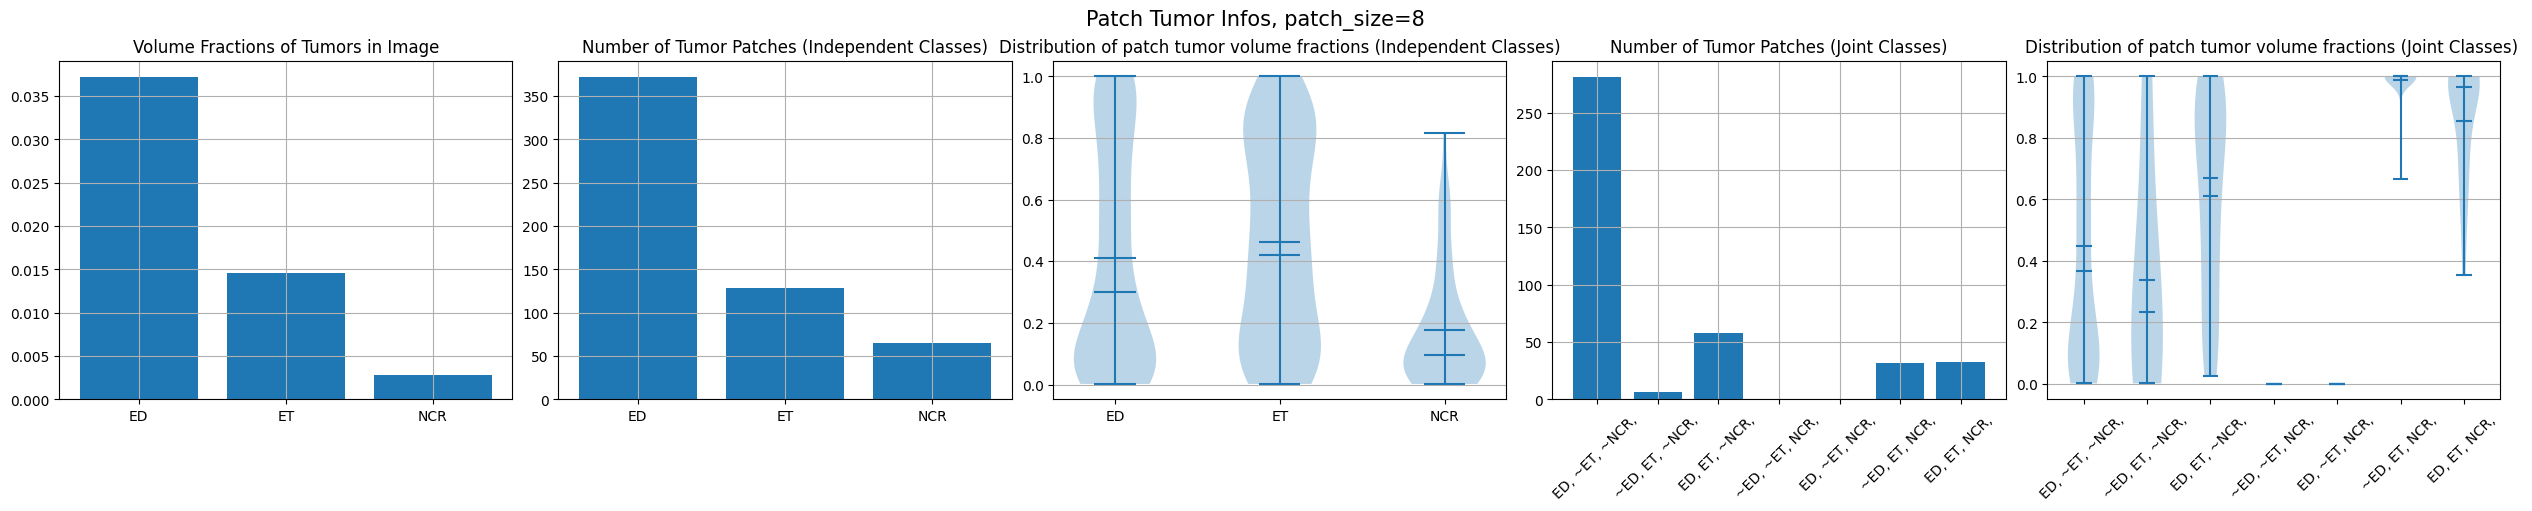

In [52]:
data_split = train_data
idx = np.random.randint(0, len(val_data), size=1)[0]
data = data_split.__getitem__(idx)
patch_data = label_patches(data['mask_labels'], num_classes=len(data_split.labels)+1, patch_sizes=data_split.patch_sizes, thresh=data_split.thresh)
get_labels=['ED', 'ET', 'NCR']

plot_patch_tumor_infos(patch_data, 8, get_labels=get_labels, labels=data_split.labels)

### Explore single image in detail
##### View an image, seg mask label pair, patch tumor distributions etc. together in one figure

metatensor([334,  53, 306, 143])
wts [2, 0, 1]
patch_counts_all_scalar_labels {'ED, ~ET, ~NCR, ': 191, '~ED, ET, ~NCR, ': 2, 'ED, ET, ~NCR, ': 88, '~ED, ~ET, NCR, ': 0, 'ED, ~ET, NCR, ': 0, '~ED, ET, NCR, ': 26, 'ED, ET, NCR, ': 27}
scalar_labels [0, 1, 2, 3, 6, 7]
metatensor([60, 16, 60, 32])
wts [2, 0, 1]
patch_counts_all_scalar_labels {'ED, ~ET, ~NCR, ': 28, '~ED, ET, ~NCR, ': 0, 'ED, ET, ~NCR, ': 16, '~ED, ~ET, NCR, ': 0, 'ED, ~ET, NCR, ': 0, '~ED, ET, NCR, ': 0, 'ED, ET, NCR, ': 16}
scalar_labels [0, 1, 3, 7]


metatensor([12,  6, 12, 11])
wts [2, 0, 1]
patch_counts_all_scalar_labels {'ED, ~ET, ~NCR, ': 1, '~ED, ET, ~NCR, ': 0, 'ED, ET, ~NCR, ': 5, '~ED, ~ET, NCR, ': 0, 'ED, ~ET, NCR, ': 0, '~ED, ET, NCR, ': 0, 'ED, ET, NCR, ': 6}
scalar_labels [0, 1, 3, 7]


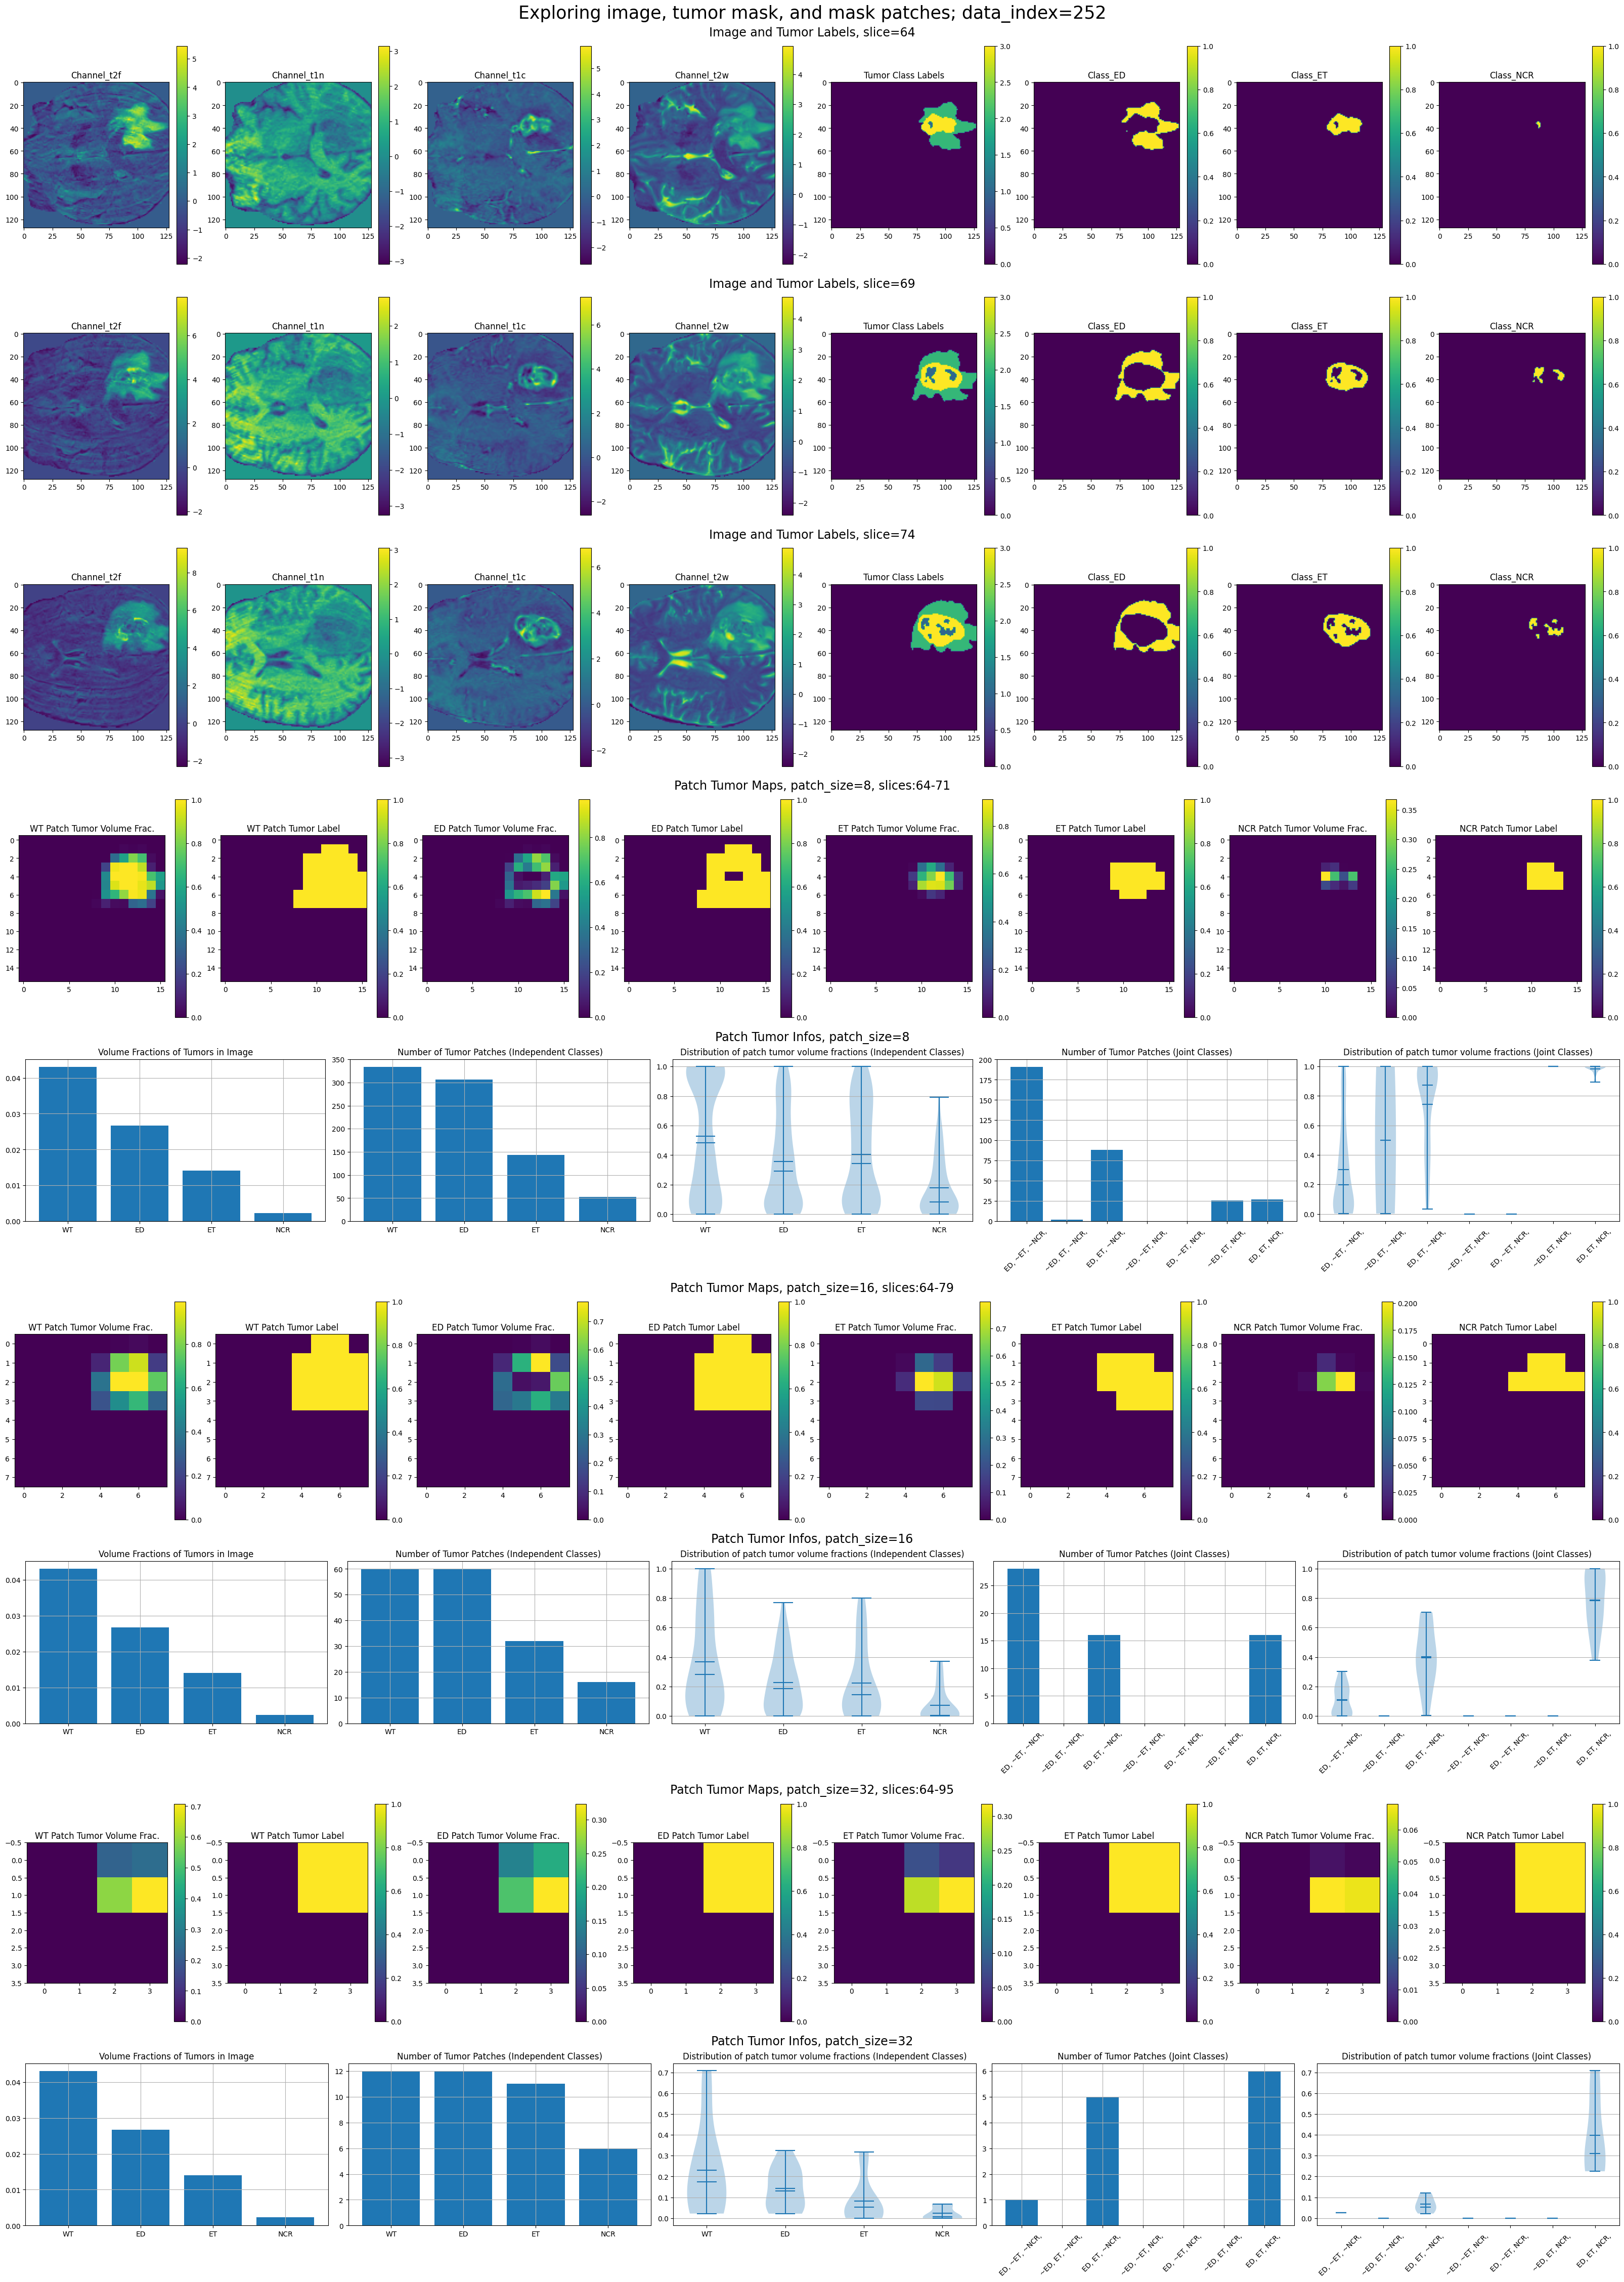

In [56]:
data_split = train_data
idx = np.random.randint(0, len(val_data), size=1)[0]
#idx = 0
data = data_split.__getitem__(idx)

#viz_img_depths = [49, 54, 59, 64, 69, 74, 79]
viz_img_depths = [64, 69, 74]
viz_patch_depths = [0]
#viz_patch_depths = [-1, 0, 1]
patch_sizes=[8, 16, 32]

# create nrows x ncols fig
ncols = 8
nrows = len(viz_img_depths) + (len(patch_sizes) * (len(viz_patch_depths) + 1))
fig = plt.figure(constrained_layout=True, figsize=(ncols * 4, nrows * 5))
fig.suptitle(f'Exploring image, tumor mask, and mask patches; data_index={idx}', fontsize=25)
# create nrows x 1 subfigs
kwargs = {'im_channels': data_split.im_channels, 'labels': data_split.labels.copy(), 'get_labels': ['ED', 'ET', 'NCR'], 'fig_title_fontsize': 17}
subfigs = fig.subfigures(nrows=nrows, ncols=1)
#Populate each axis of every subfig with plots
subfig_idx = 0
#plot img and masks at certain depths

for im_depth in viz_img_depths:
    plot_image_and_mask_labels(data['image'], data['mask_labels'], fig=subfigs[subfig_idx], depth=im_depth, **kwargs)
    subfig_idx += 1

#plot patch tumor maps and patch distribution
patch_data = label_patches(data['mask_labels'], num_classes=len(kwargs['labels'])+1, patch_sizes=patch_sizes, thresh=data_split.thresh)
#add WT to labels as we also want to plot WT patch maps and distribution
kwargs['get_labels'] = ['WT', 'ED', 'ET', 'NCR']
kwargs['labels']['WT'] = 0
for i, patch_size in enumerate(patch_sizes):
    #idx = (len(viz_patch_depths) + 1)*i + len(viz_img_depths)
    patch_mid_depth = patch_data['patch_tumor_vol_fracs'][str(patch_size)].shape[-1] // 2
    for patch_depth in viz_patch_depths:
        plot_patch_tumor_maps(patch_data, patch_size=patch_size, fig=subfigs[subfig_idx], depth=(patch_mid_depth+patch_depth), **kwargs)
        subfig_idx += 1
    plot_patch_tumor_infos(patch_data, patch_size=patch_size, fig=subfigs[subfig_idx], **kwargs)
    subfig_idx += 1


Compute patch tumor vol distributions of all images in dataset \
And compute overall dataset patch distribution statistics


In [35]:
%%time
from tqdm import tqdm

patch_sizes = [8, 16, 32]
get_labels = ['WT', 'ED', 'ET', 'NCR']

data_split = train_data
num_classes=len(data_split.labels)+1
labels = data_split.labels.copy()
labels.update({'WT': 0})


#compute_whole_dataset_patch_tumor_stats
rows = []
n_iters = 3
for idx in tqdm(range(len(data_split))):
    for n_iter in tqdm(range(n_iters), leave=False):
        data = data_split.__getitem__(idx)
        patch_data = label_patches(data['mask_labels'], num_classes=num_classes, patch_sizes=patch_sizes, thresh=data_split.thresh)
        for patch_size in patch_sizes:
            patch_tumor_info_dict = compute_patch_tumor_infos(patch_data, patch_size, get_labels=get_labels, labels=labels, num_classes=num_classes)
            for tumor_class_type, tumor_classes_info in patch_tumor_info_dict.items(): #tumor_class_type: ['independent', 'joint]
                for tumor_class_info in tumor_classes_info: #for every tumor class (independent: WT/ED/ET/NCR or joint classes)
                    row = {'n_iter': n_iter, 'image_idx': 0, 'patch_size': patch_size, 'tumor_class_type': tumor_class_type}
                    row.update(tumor_class_info)
                    rows.append(row)

import pandas as pd
patch_info_df = pd.DataFrame.from_records(rows)
root = '/home/students/sanyal/Master-Thesis/Projects/BraTS3DDiff/results/EDA'
patch_info_df.to_csv(f'{root}/BraTS2023_train_patch_tumor_statistics.csv')


100%|██████████| 991/991 [29:12<00:00,  1.77s/it]


CPU times: user 59min 34s, sys: 19min 26s, total: 1h 19min 1s
Wall time: 29min 18s


In [124]:
patch_info_df['patch_tumor_vol_fracs_median'] = [np.nan_to_num(np.median(np.array(x)), nan=0) for x in patch_info_df['patch_tumor_vol_fracs']]
patch_info_df['patch_tumor_vol_fracs_mean'] = [np.nan_to_num(np.mean(np.array(x)), nan=0) for x in patch_info_df['patch_tumor_vol_fracs']]

/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [125]:
patch_info_df

,n_iter,image_idx,patch_size,tumor_class_type,tumor_class,tumor_size,num_tumor_patches,patch_tumor_vol_fracs,patch_tumor_vol_fracs_median,patch_tumor_vol_fracs_mean
0,0,0,8,independent_classes,WT,0.021039,162,"[0.060546875, 0.3203125, 0.466796875, 0.066406...",0.479492,0.531949
1,0,0,8,independent_classes,ED,0.002653,121,"[0.04296875, 0.31640625, 0.466796875, 0.066406...",0.050781,0.089795
2,0,0,8,independent_classes,ET,0.013426,147,"[0.017578125, 0.00390625, 0.015625, 0.02539062...",0.326172,0.374097
3,0,0,8,independent_classes,NCR,0.004961,78,"[0.0078125, 0.0390625, 0.130859375, 0.24804687...",0.126953,0.260492
4,0,0,8,joint_classes,"ED, ~ET, ~NCR,",NaN,15,"[0.466796875, 0.06640625, 0.033203125, 0.03906...",0.039062,0.071615
...,...,...,...,...,...,...,...,...,...,...
98104,2,0,32,joint_classes,"ED, ET, ~NCR,",NaN,0,[0.0],0.000000,0.000000
98105,2,0,32,joint_classes,"~ED, ~ET, NCR,",NaN,0,[0.0],0.000000,0.000000
98106,2,0,32,joint_classes,"ED, ~ET, NCR,",NaN,1,[0.26910400390625],0.269104,0.269104
98107,2,0,32,joint_classes,"~ED, ET, NCR,",NaN,0,[0.0],0.000000,0.000000


In [88]:
_labels = ['ED', 'ET', 'NCR']
scalar2str_labels_dict = create_scalar2str_labels_dict(_labels)
dict(sorted(scalar2str_labels_dict.items())).values()

dict_values(['~ED, ~ET, ~NCR, ', 'ED, ~ET, ~NCR, ', '~ED, ET, ~NCR, ', 'ED, ET, ~NCR, ', '~ED, ~ET, NCR, ', 'ED, ~ET, NCR, ', '~ED, ET, NCR, ', 'ED, ET, NCR, '])

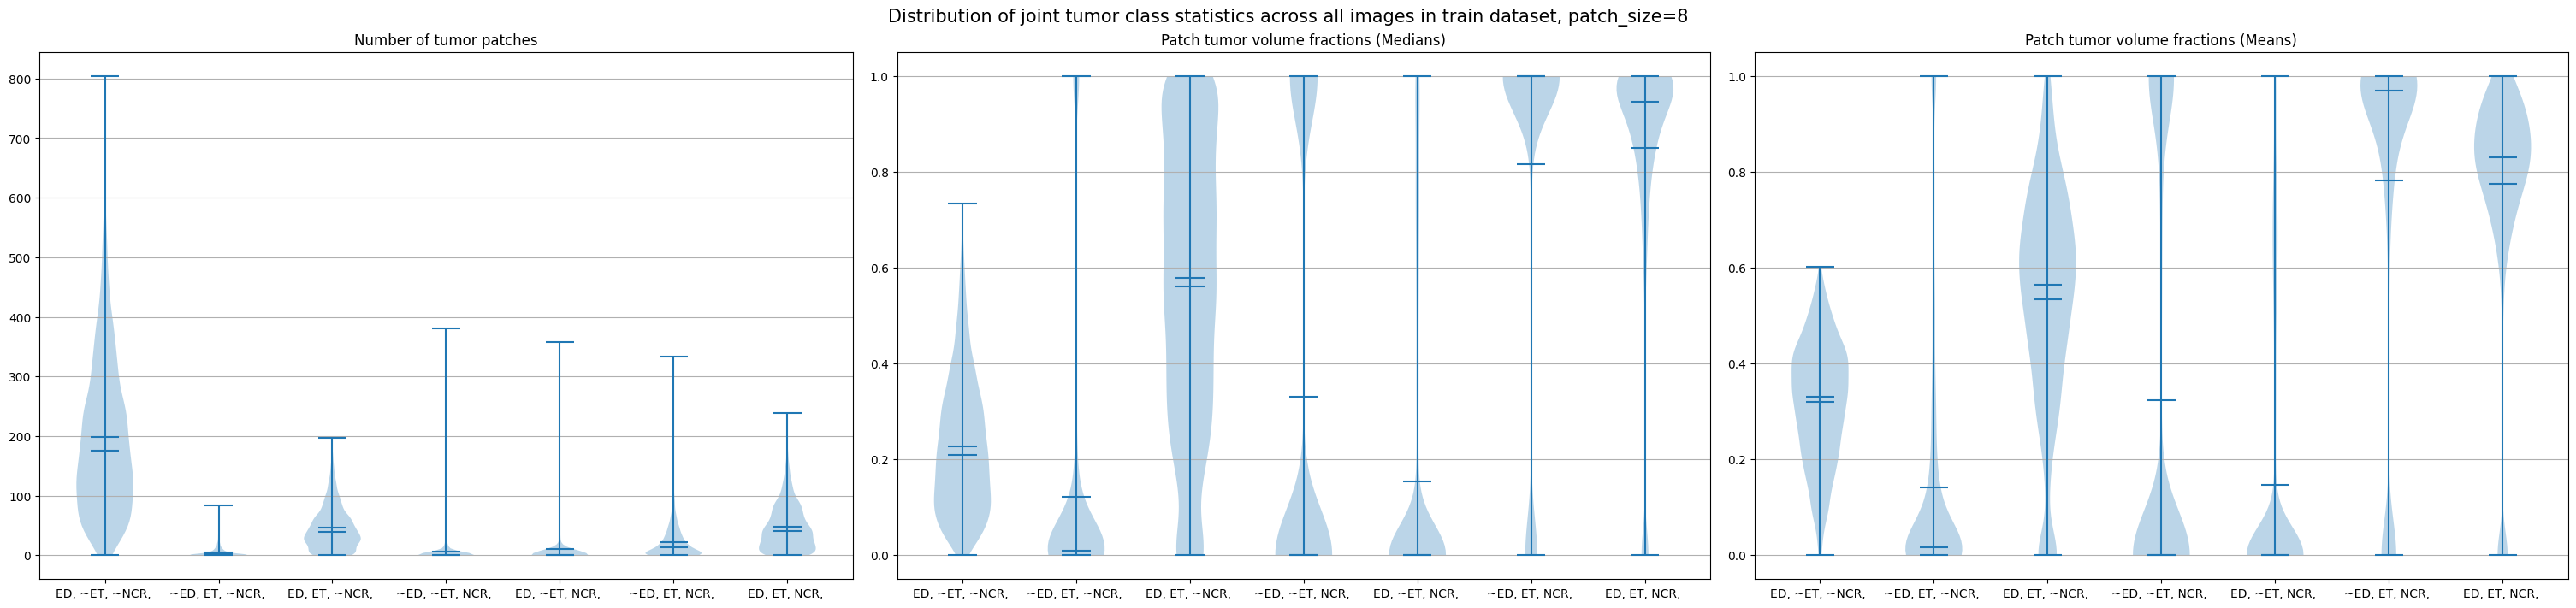

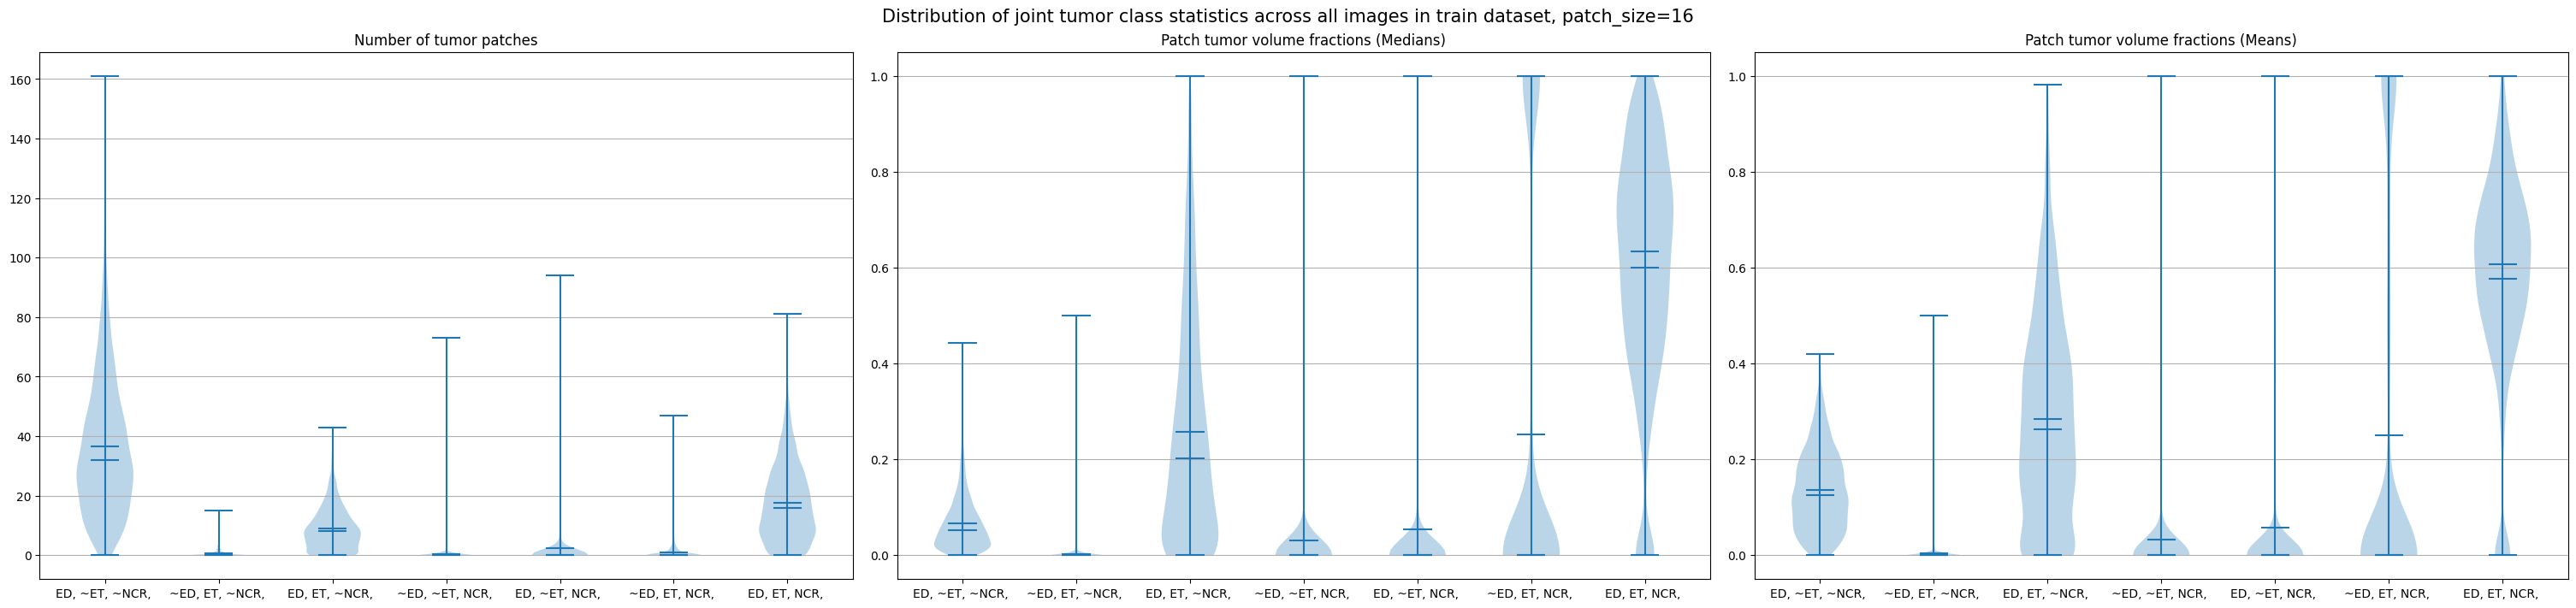

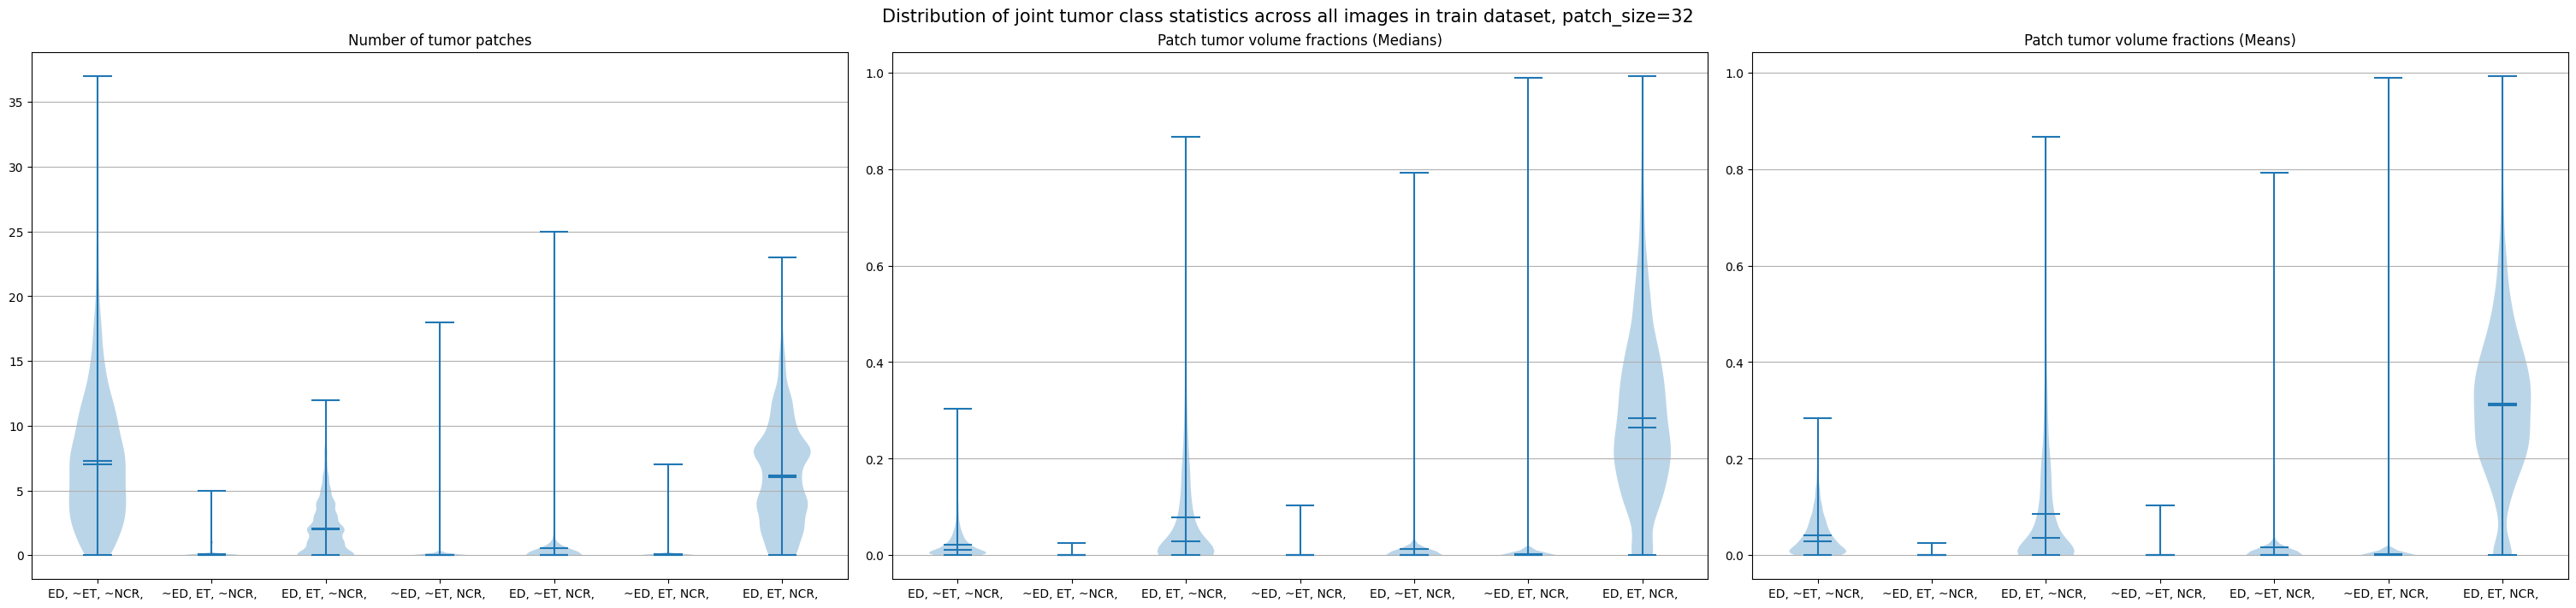

In [126]:
patch_info_df_agg = patch_info_df.query('tumor_class_type == "joint_classes"').groupby(['patch_size', 'tumor_class']).agg({'num_tumor_patches': lambda x: list(x), 'patch_tumor_vol_fracs_median': lambda x: list(x), 'patch_tumor_vol_fracs_mean': lambda x: list(x)}).reset_index()

patch_sizes = patch_info_df_agg['patch_size'].unique()
_labels = ['ED', 'ET', 'NCR']
tumor_labels = list(dict(sorted(create_scalar2str_labels_dict(_labels).items())).values())[1:]
for _patch_size in patch_sizes:
    fig = plt.figure(layout='constrained', figsize=(30, 7), facecolor="white")
    suptitle = fig.suptitle(f'Distribution of joint tumor class statistics across all images in train dataset, patch_size={_patch_size}')
    suptitle.set(fontsize = 15)
    axes = fig.subplots(1, 3)
    tumor_sizes = []
    num_tumor_patches = []
    patch_tumor_vol_fracs_medians = []
    patch_tumor_vol_fracs_means = []

    for _tumor_label in tumor_labels:
        _query_df = patch_info_df_agg.query("(patch_size == @_patch_size) & (tumor_class == @_tumor_label)")
        num_tumor_patches.append(_query_df['num_tumor_patches'].tolist()[0])
        patch_tumor_vol_fracs_medians.append(_query_df['patch_tumor_vol_fracs_median'].tolist()[0])
        patch_tumor_vol_fracs_means.append(_query_df['patch_tumor_vol_fracs_mean'].tolist()[0])
    
    plot_violin(axes[0], num_tumor_patches, tumor_labels, title='Number of tumor patches')
    plot_violin(axes[1], patch_tumor_vol_fracs_medians, tumor_labels, title='Patch tumor volume fractions (Medians)')
    plot_violin(axes[2], patch_tumor_vol_fracs_means, tumor_labels, title='Patch tumor volume fractions (Means)')



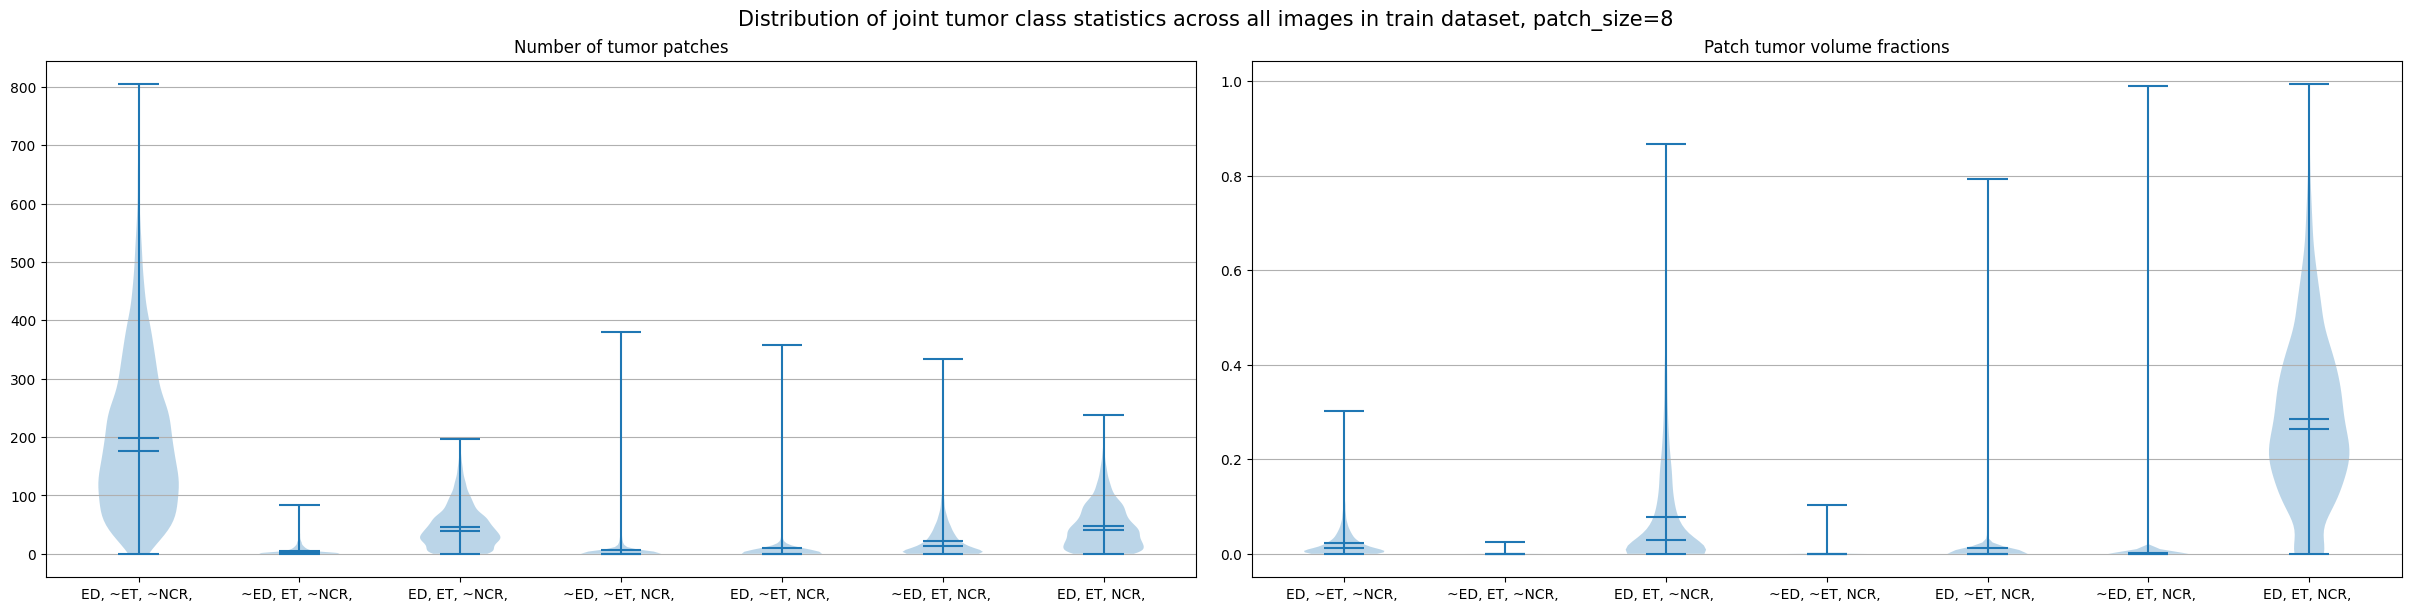

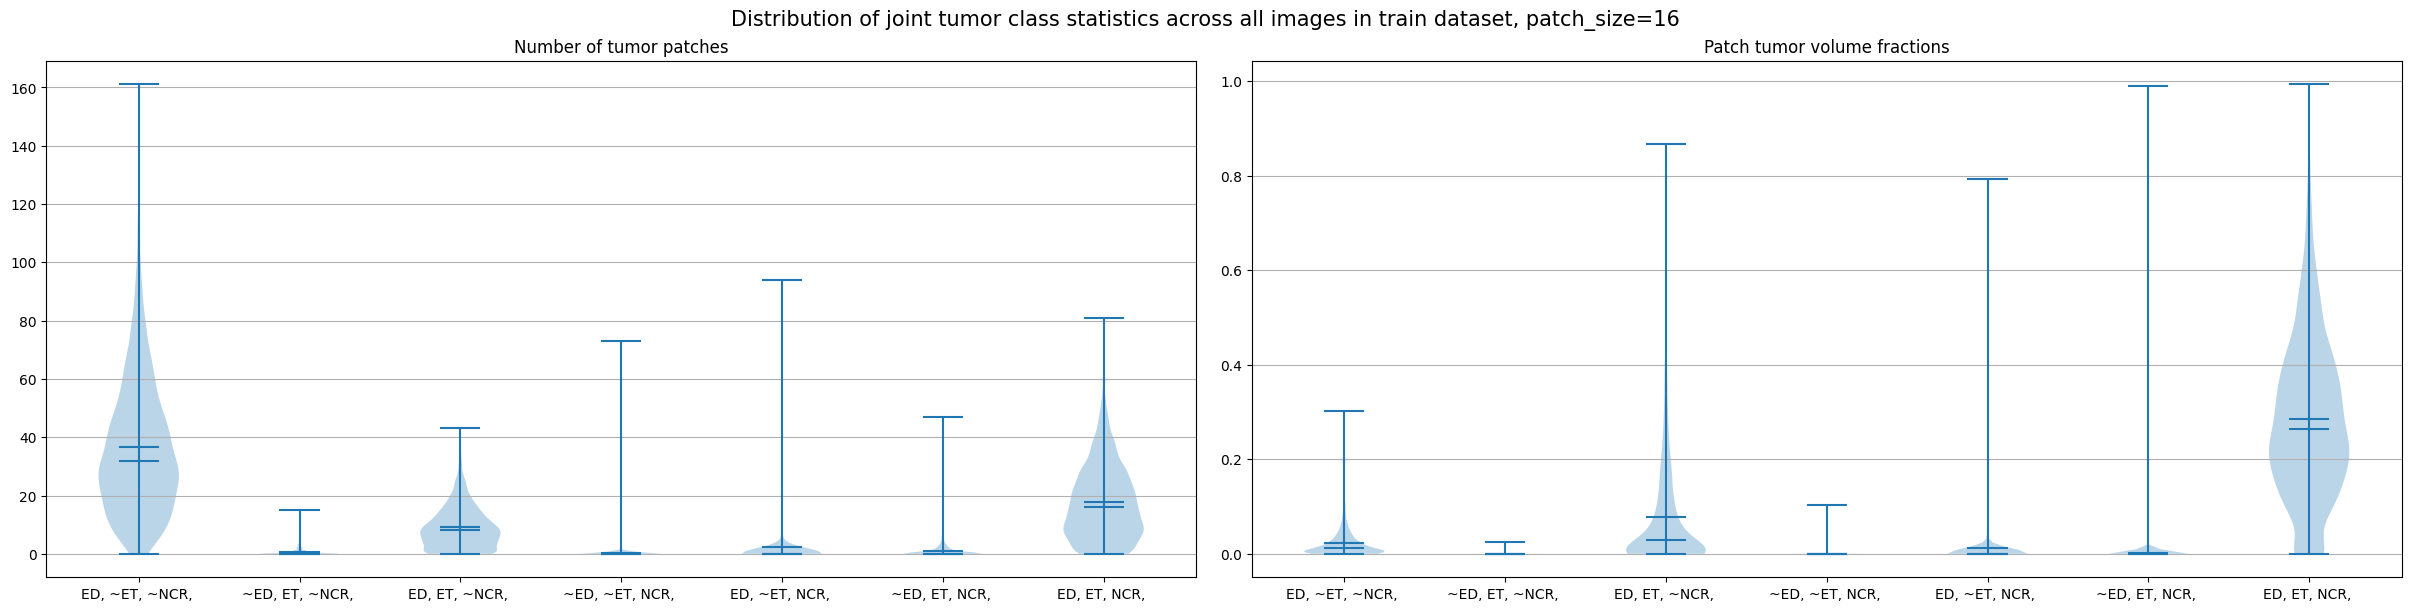

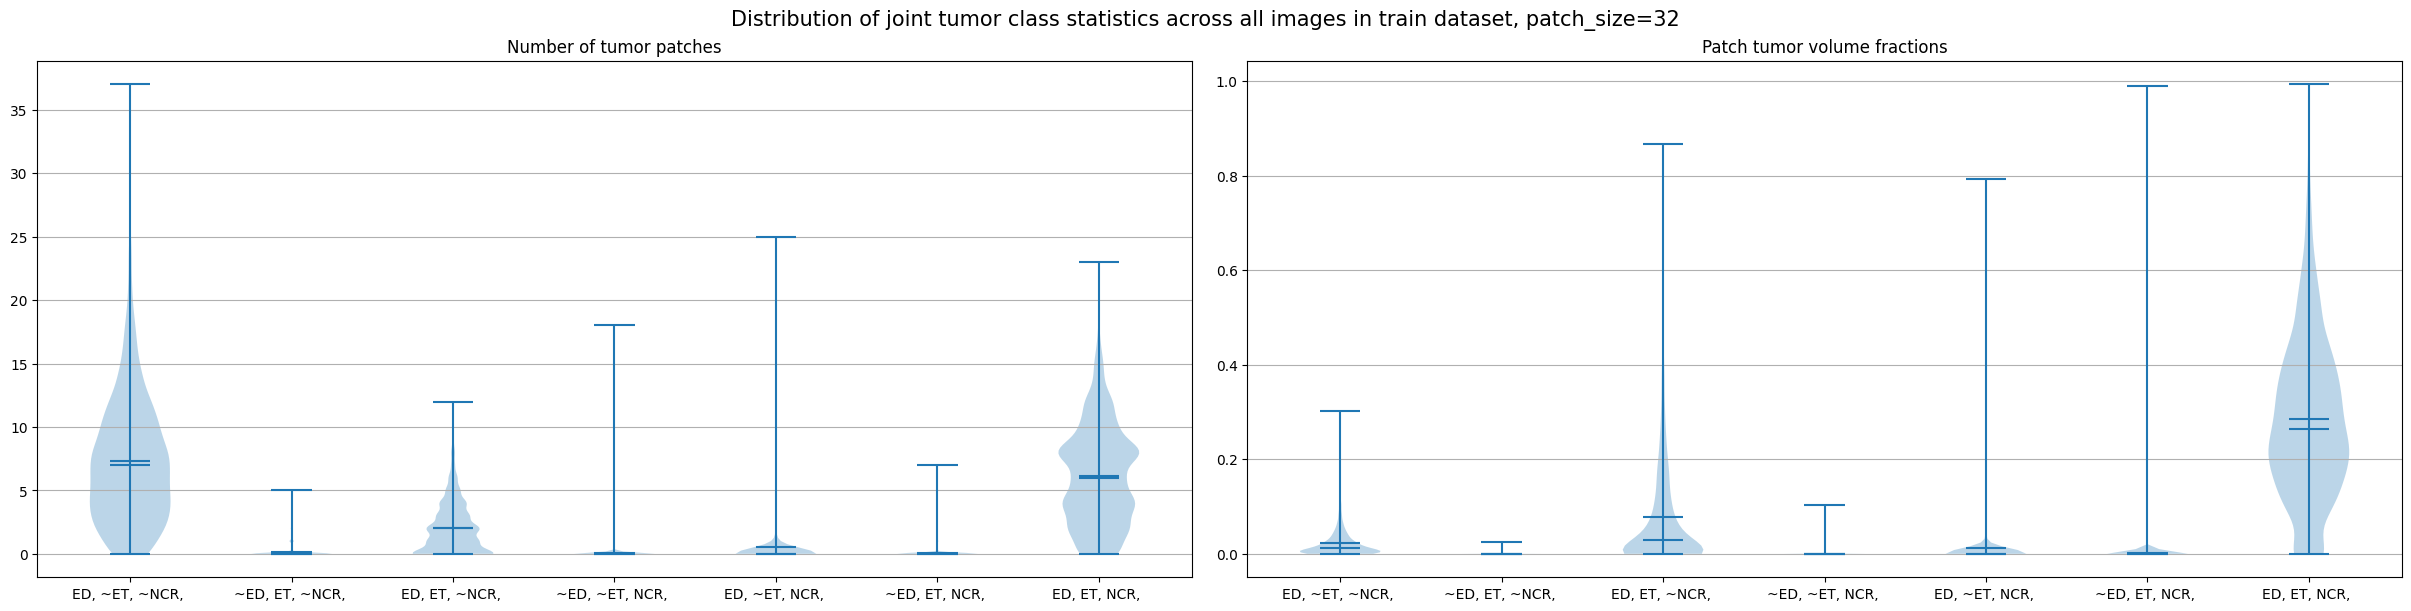

In [129]:
patch_info_df_agg = patch_info_df.query('tumor_class_type == "joint_classes"').groupby(['patch_size', 'tumor_class']).agg({'num_tumor_patches': lambda x: list(x), 'patch_tumor_vol_fracs': 'sum'}).reset_index()

patch_sizes = patch_info_df_agg['patch_size'].unique()
_labels = ['ED', 'ET', 'NCR']
tumor_labels = list(dict(sorted(create_scalar2str_labels_dict(_labels).items())).values())[1:]
for _patch_size in patch_sizes:
    fig = plt.figure(layout='constrained', figsize=(24, 6), facecolor="white")
    suptitle = fig.suptitle(f'Distribution of joint tumor class statistics across all images in train dataset, patch_size={_patch_size}')
    suptitle.set(fontsize = 15)
    axes = fig.subplots(1, 2)
    tumor_sizes = []
    num_tumor_patches = []
    patch_tumor_vol_fracs = []

    for _tumor_label in tumor_labels:
        _query_df = patch_info_df_agg.query("(patch_size == @_patch_size) & (tumor_class == @_tumor_label)")
        num_tumor_patches.append(_query_df['num_tumor_patches'].tolist()[0])
        patch_tumor_vol_fracs.append(_query_df['patch_tumor_vol_fracs'].tolist()[0])
    
    plot_violin(axes[0], num_tumor_patches, tumor_labels, title='Number of tumor patches')
    plot_violin(axes[1], patch_tumor_vol_fracs_medians, tumor_labels, title='Patch tumor volume fractions')


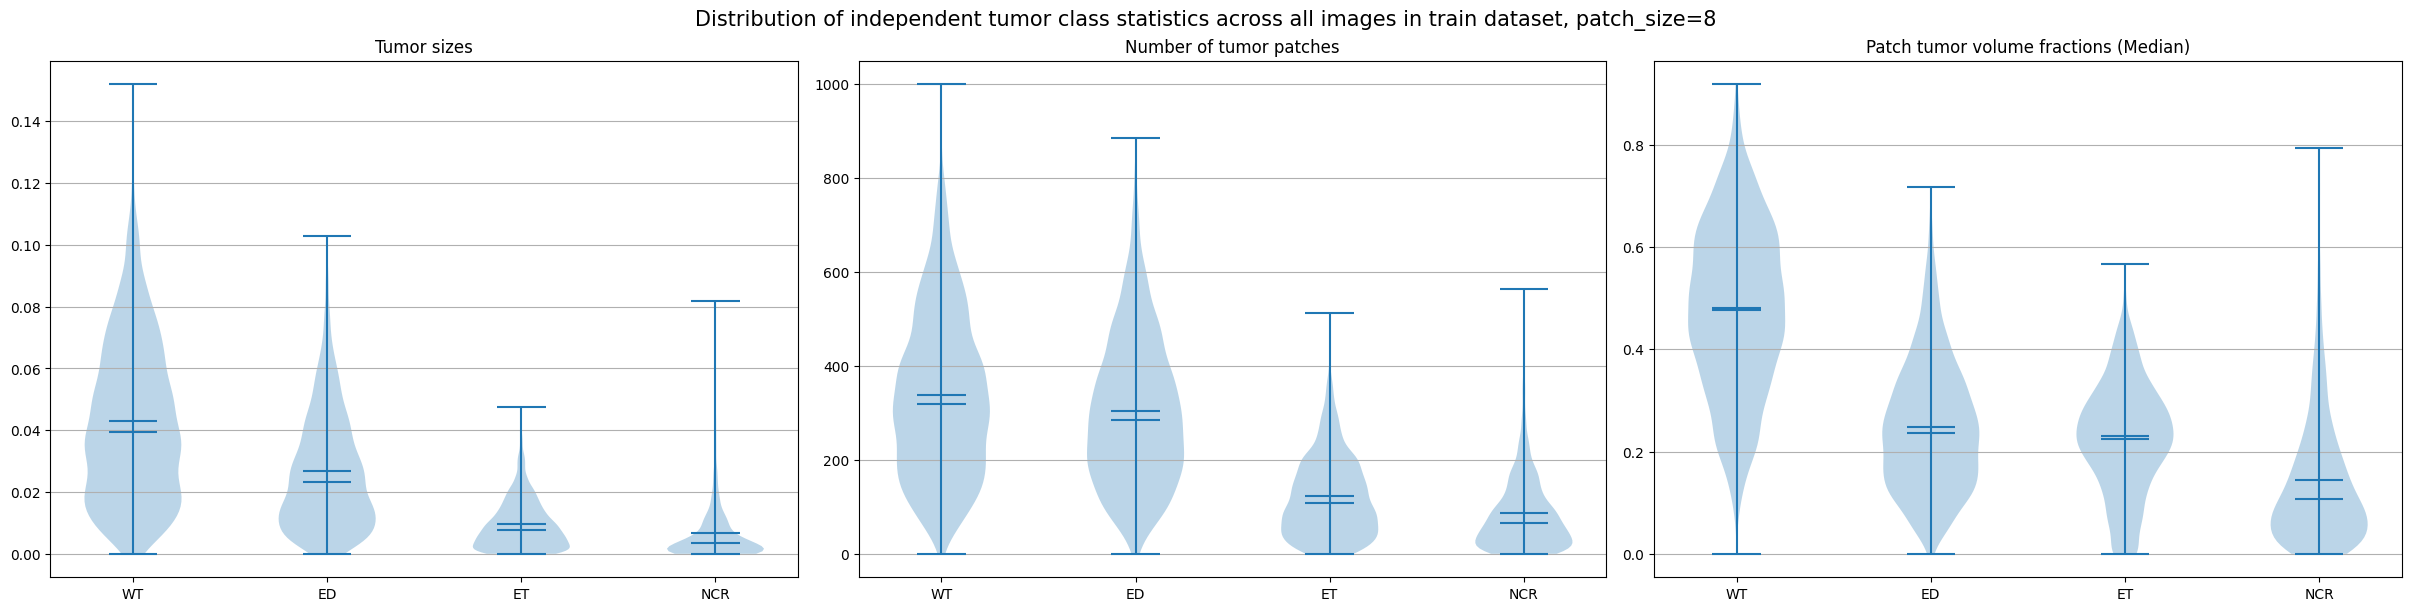

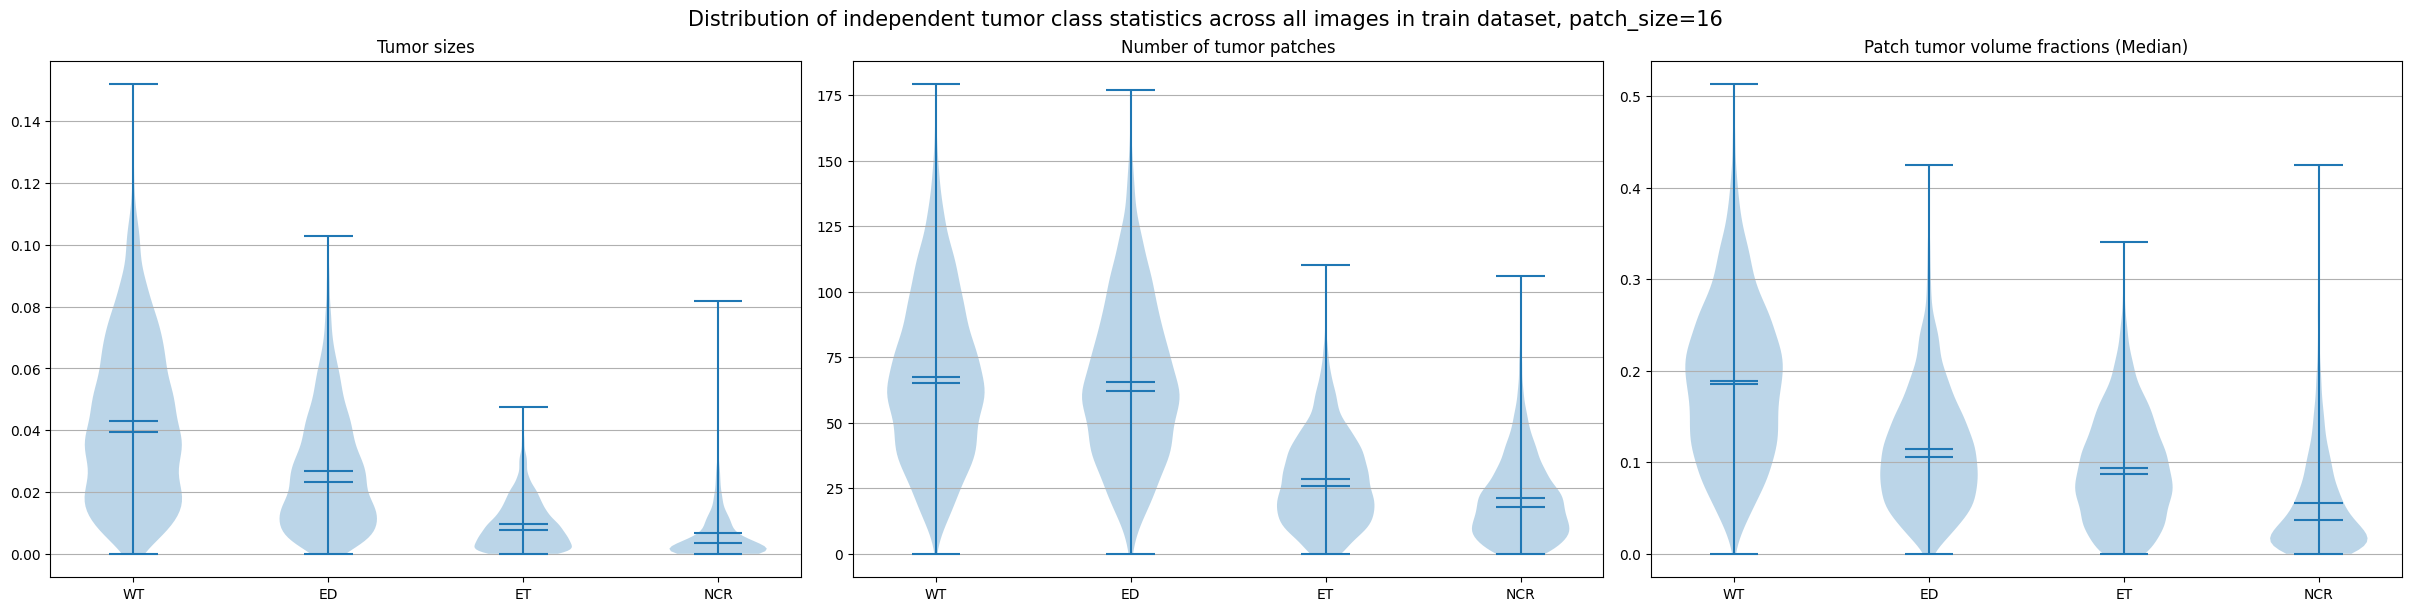

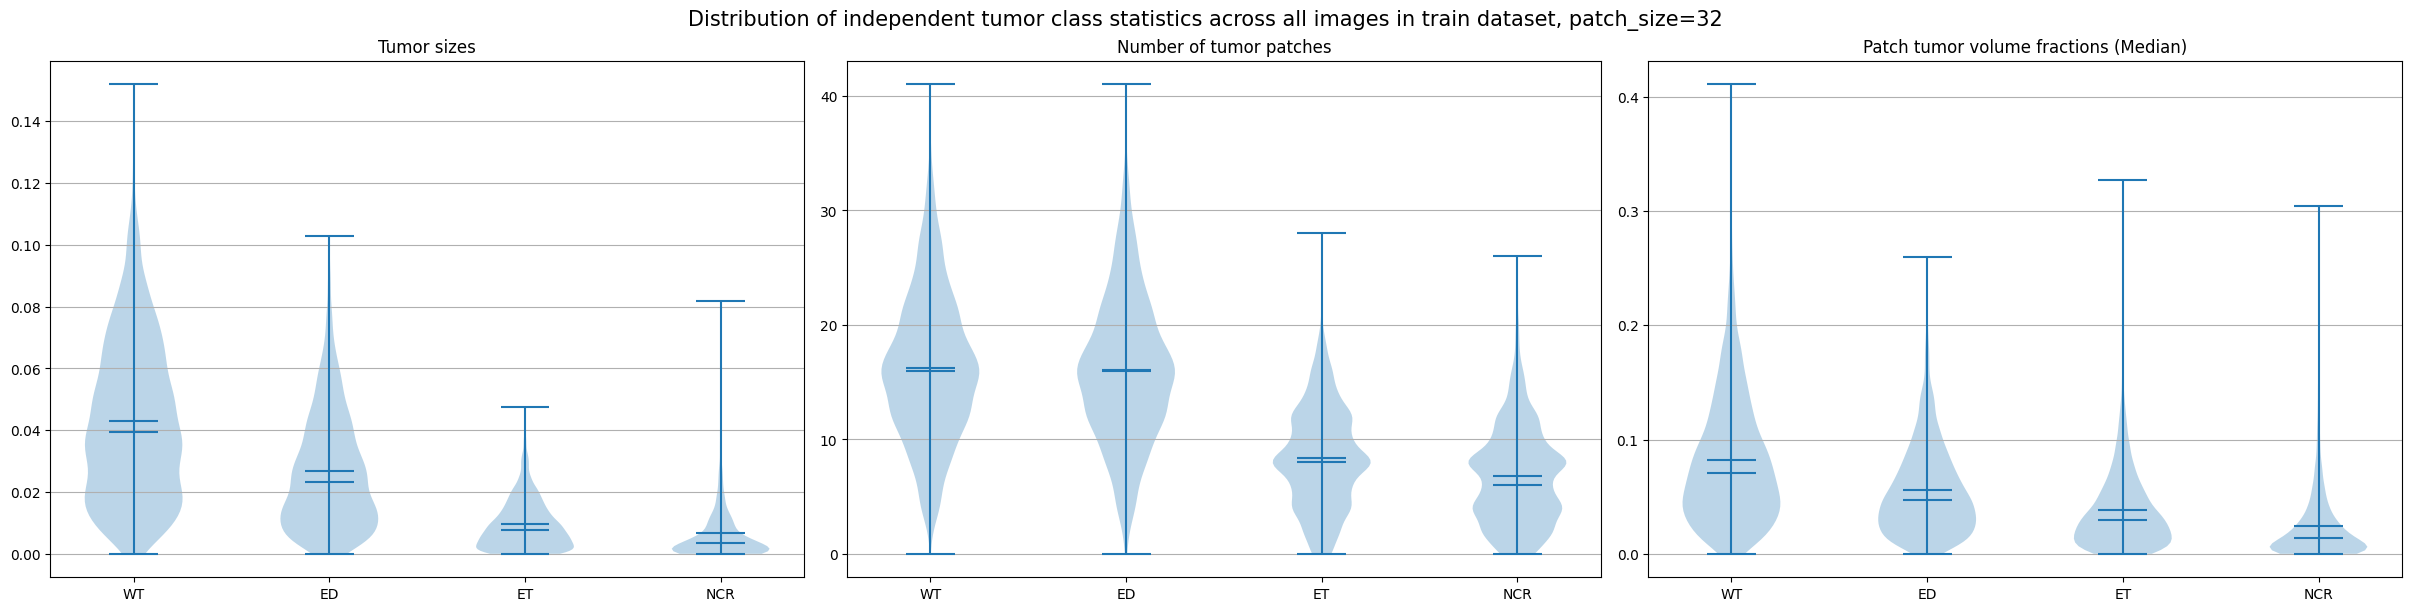

In [127]:
patch_info_df_agg = patch_info_df.query('tumor_class_type == "independent_classes"').groupby(['patch_size', 'tumor_class']).agg({'tumor_size': lambda x: list(x), 'num_tumor_patches': lambda x: list(x), 'patch_tumor_vol_fracs_median': lambda x: list(x)}).reset_index()

patch_sizes = patch_info_df_agg['patch_size'].unique()
tumor_labels = ['WT', 'ED', 'ET', 'NCR']
for _patch_size in patch_sizes:
    fig = plt.figure(layout='constrained', figsize=(24, 6), facecolor="white")
    suptitle = fig.suptitle(f'Distribution of independent tumor class statistics across all images in train dataset, patch_size={_patch_size}')
    suptitle.set(fontsize = 15)
    axes = fig.subplots(1, 3)
    tumor_sizes = []
    num_tumor_patches = []
    patch_tumor_vol_fracs = []
    for _tumor_label in tumor_labels:
        _query_df = patch_info_df_agg.query("(patch_size == @_patch_size) & (tumor_class == @_tumor_label)")
        tumor_sizes.append(_query_df['tumor_size'].tolist()[0])
        num_tumor_patches.append(_query_df['num_tumor_patches'].tolist()[0])
        patch_tumor_vol_fracs.append(_query_df['patch_tumor_vol_fracs_median'].tolist()[0])
    
    plot_violin(axes[0], tumor_sizes, tumor_labels, title='Tumor sizes')
    plot_violin(axes[1], num_tumor_patches, tumor_labels, title='Number of tumor patches')
    plot_violin(axes[2], patch_tumor_vol_fracs, tumor_labels, title='Patch tumor volume fractions (Median)')



In [37]:
patch_info_df.query('tumor_class_type == "independent_classes"').groupby(['patch_size', 'tumor_class']).agg({'tumor_size': ['min', 'median', 'mean', 'max'], 'num_tumor_patches': ['min', 'median', 'mean', 'max']})

tumor_size                                \
                              min    median      mean       max   
patch_size tumor_class                                            
8          ED                 0.0  0.023309  0.026814  0.102748   
           ET                 0.0  0.007708  0.009504  0.047485   
           NCR                0.0  0.003463  0.006725  0.081884   
           WT                 0.0  0.039540  0.043043  0.151855   
16         ED                 0.0  0.023309  0.026814  0.102748   
           ET                 0.0  0.007708  0.009504  0.047485   
           NCR                0.0  0.003463  0.006725  0.081884   
           WT                 0.0  0.039540  0.043043  0.151855   
32         ED                 0.0  0.023309  0.026814  0.102748   
           ET                 0.0  0.007708  0.009504  0.047485   
           NCR                0.0  0.003463  0.006725  0.081884   
           WT                 0.0  0.039540  0.043043  0.151855   

                       num_tumor_patches                          
                                     min median        mean  max  
patch_size tumor_class                                            
8          ED                          0  285.0  302.802893  884  
           ET                          0  108.0  121.897410  511  
           NCR                         0   65.0   86.619240  563  
           WT                          0  319.0  336.647830  998  
16         ED                          0   62.0   65.545577  177  
           ET                          0   26.0   28.364615  110  
           NCR                         0   18.0   21.270098  106  
           WT                          0   65.0   67.457787  179  
32         ED                          0   16.0   16.038009   41  
           ET                          0    8.0    8.357888   28  
           NCR                         0    6.0    6.784393   26  
           WT                          0   16.0   16.243861   41

In [40]:
import seaborn as sns


def _plot_boxplot_ax(df, ax, **kwargs):
    '''
    Plot a grouped boxplot of non-tumor vs tumor patch counts/ density statistics across multiple labels
    The statistics are computed for a certain patch-size over all images in dataset (train/val)
    Args:
        df: patch tumor statistics for a certain patch-size
        ax: axis to plot on
        kwargs: extra_kwargs
    '''
    _y = kwargs.get('y', 'counts')
    ax = sns.boxplot(data=df, x="label", y=_y, hue="tumor_type", ax=ax, palette='Set2')
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, -0.2), ncol=3, title=None, frameon=False)
    ax.set_yticks(np.linspace(0, kwargs['max_yticks'], kwargs.get('n_yticks', 10)))
    ax.grid(axis='y',)
    y_label = 'Number of patches' if _y == 'counts' else 'Density of patches'
    ax.set_ylabel(y_label)

    # Compute and annotate medians
    medians = df.groupby(['label','tumor_type'])[['counts', 'density']].median().reset_index()
    positions = {cat: i for i, cat in enumerate(df['label'].unique())}
    for i, row in medians.iterrows():
        x_pos = positions[row['label']] + (-0.2 if row['tumor_type'] == 'Tumor Patches' else 0.2)  # Adjust for hue
        y_pos = row[_y]
        color = 'brown' if (row['tumor_type'] == 'Tumor Patches') else 'green'
        ax.text(x_pos, y_pos, f'{y_pos:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)


def _plot_boxplot_vol_frac_ax(df, ax, **kwargs):
    '''
    Plot a grouped boxplot of non-tumor vs tumor patch counts/ density statistics across multiple labels
    The statistics are computed for a certain patch-size over all images in dataset (train/val)
    Args:
        df: patch tumor statistics for a certain patch-size
        ax: axis to plot on
        kwargs: extra_kwargs
    '''
    _y = kwargs.get('y', 'counts')
    ax = sns.boxplot(data=df, x="label", y=_y, hue="vol_frac_bin", ax=ax, palette='Set2')
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, -0.2), ncol=3, title=None, frameon=False)
    ax.set_yticks(np.linspace(0, kwargs['max_yticks'], kwargs.get('n_yticks', 10)))
    ax.grid(axis='y',)
    y_label = 'Number of patches' if _y == 'counts' else 'Density of patches'
    ax.set_ylabel(y_label)

    # Compute and annotate medians
    medians = df.groupby(['label','vol_frac_bin'])[['counts', 'density']].median().reset_index()
    positions = {cat: i for i, cat in enumerate(df['label'].unique())}
    subgroups =hist_stats_df['vol_frac_bin'].unique().tolist()
    offsets = np.linspace(-0.4, 0.4, len(subgroups))  # Spread out medians horizontally
    for i, row in medians.iterrows():
        cat, subgroup, median = row['label'], row['vol_frac_bin'], row[_y]
        x_pos = positions[cat] + offsets[subgroups.index(subgroup)]  # Adjust for hue
        y_pos = median
        ax.text(x_pos, y_pos, f'{median:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

In [35]:
hist_stats_df['vol_frac_bin'].unique()

array(['0 (zero)', '0.00 - 0.10', '0.10 - 0.20', '0.20 - 0.30',
       '0.30 - 0.40', '0.40 - 0.50', '0.50 - 0.60', '0.60 - 0.70',
       '0.70 - 0.80', '0.80 - 0.90', '0.90 - 1.00'], dtype=object)

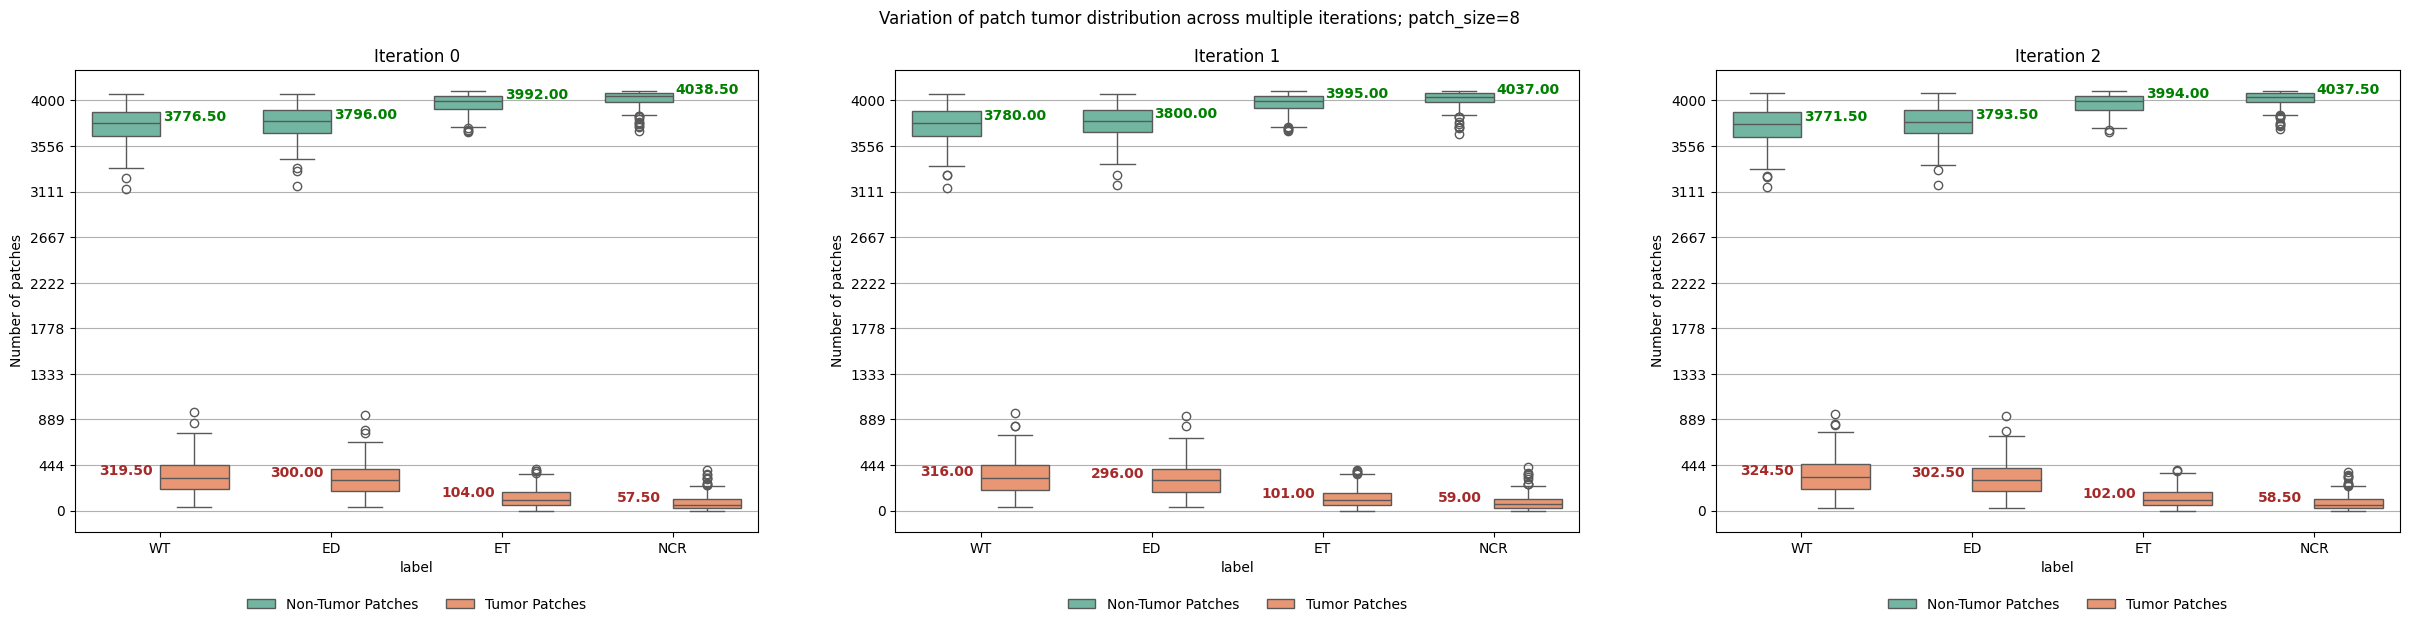

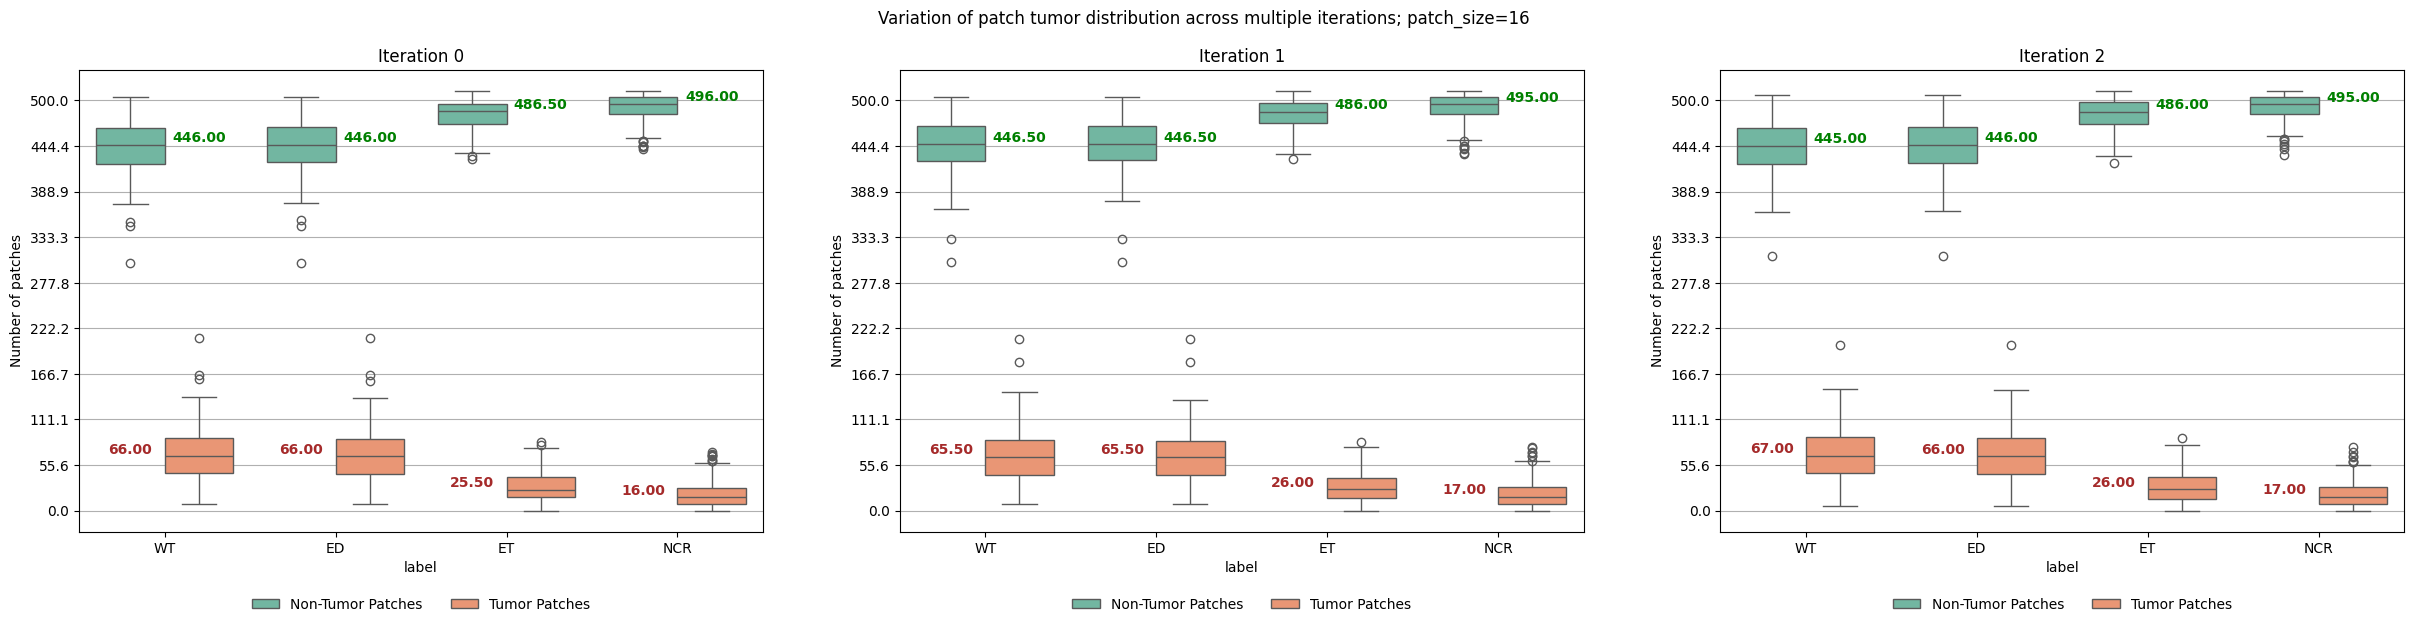

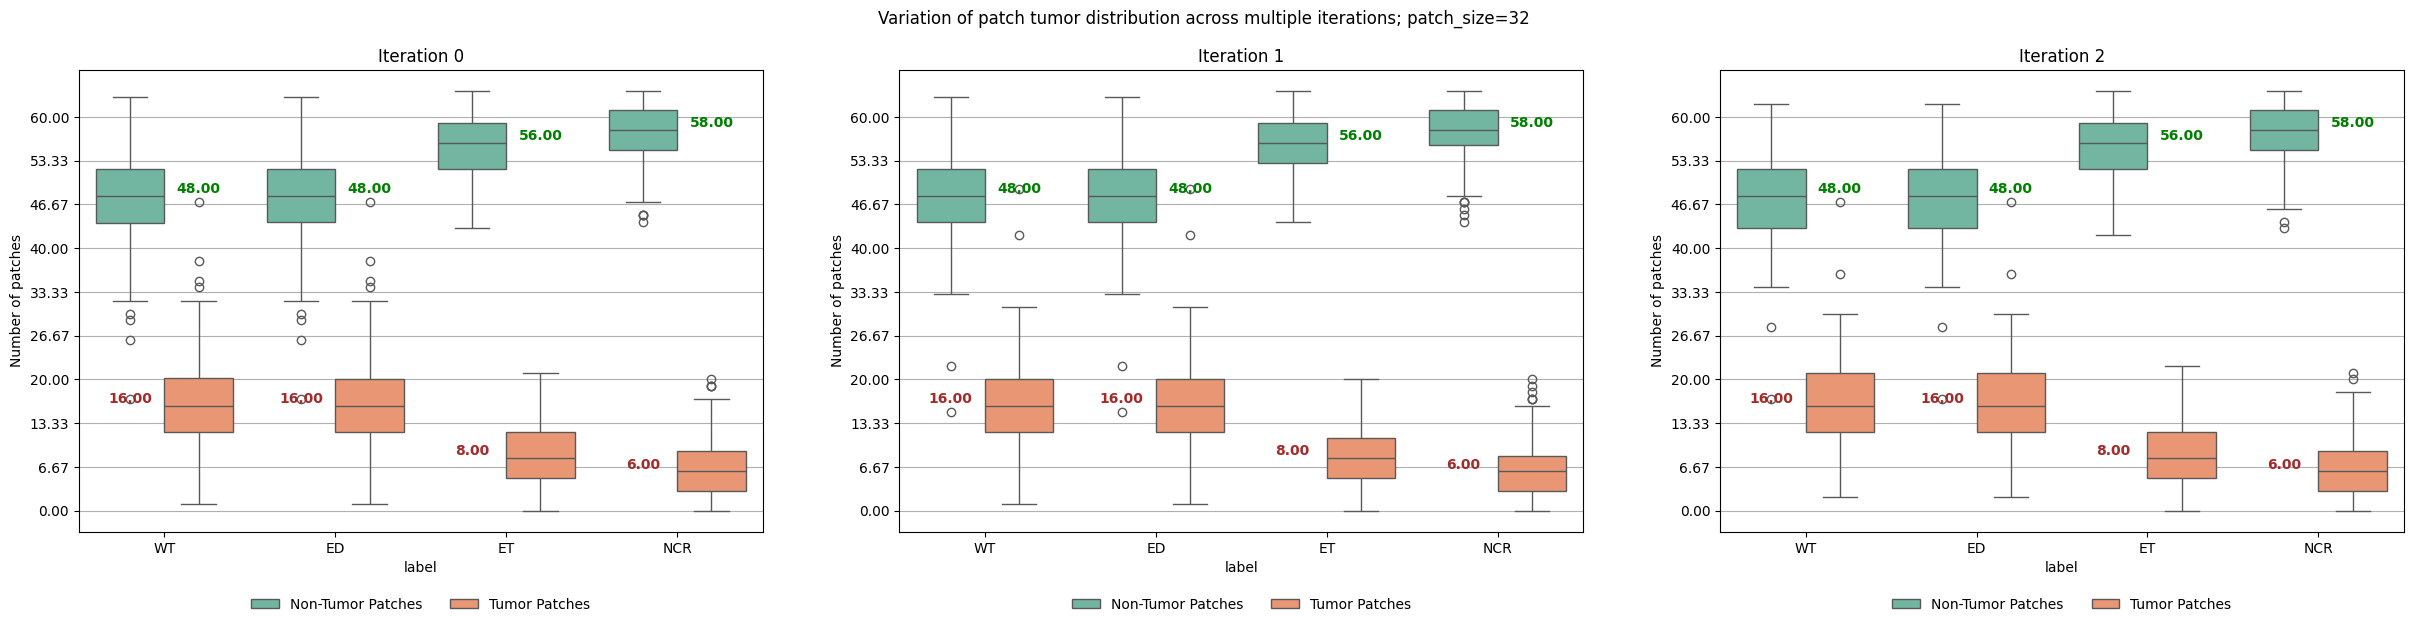

In [28]:
#Plot variation of patch tumor distribution across multiple iterations
_patch_sizes = [8, 16, 32]
_y = 'counts'
max_yticks_dict = {8:4000, 16:500, 32:60}
n_iters = 3
for _patch_size in _patch_sizes:
    df2 = hist2_stats_df[hist2_stats_df['patch_size']==_patch_size]
    fig, axes = plt.subplots(1,n_iters,figsize=(30,6))
    _max_yticks = 1.0 if _y == 'density' else max_yticks_dict[_patch_size]
    for i, ax in enumerate(axes):
        _plot_boxplot_ax(df=df2[df2['n_iter']==i], ax=ax, y=_y, max_yticks=_max_yticks)
        ax.set_title(f'Iteration {i}')
    fig.suptitle(f'Variation of patch tumor distribution across multiple iterations; patch_size={_patch_size}')

Text(0.5, 0.98, 'Variation of patch tumor distribution across patch sizes')

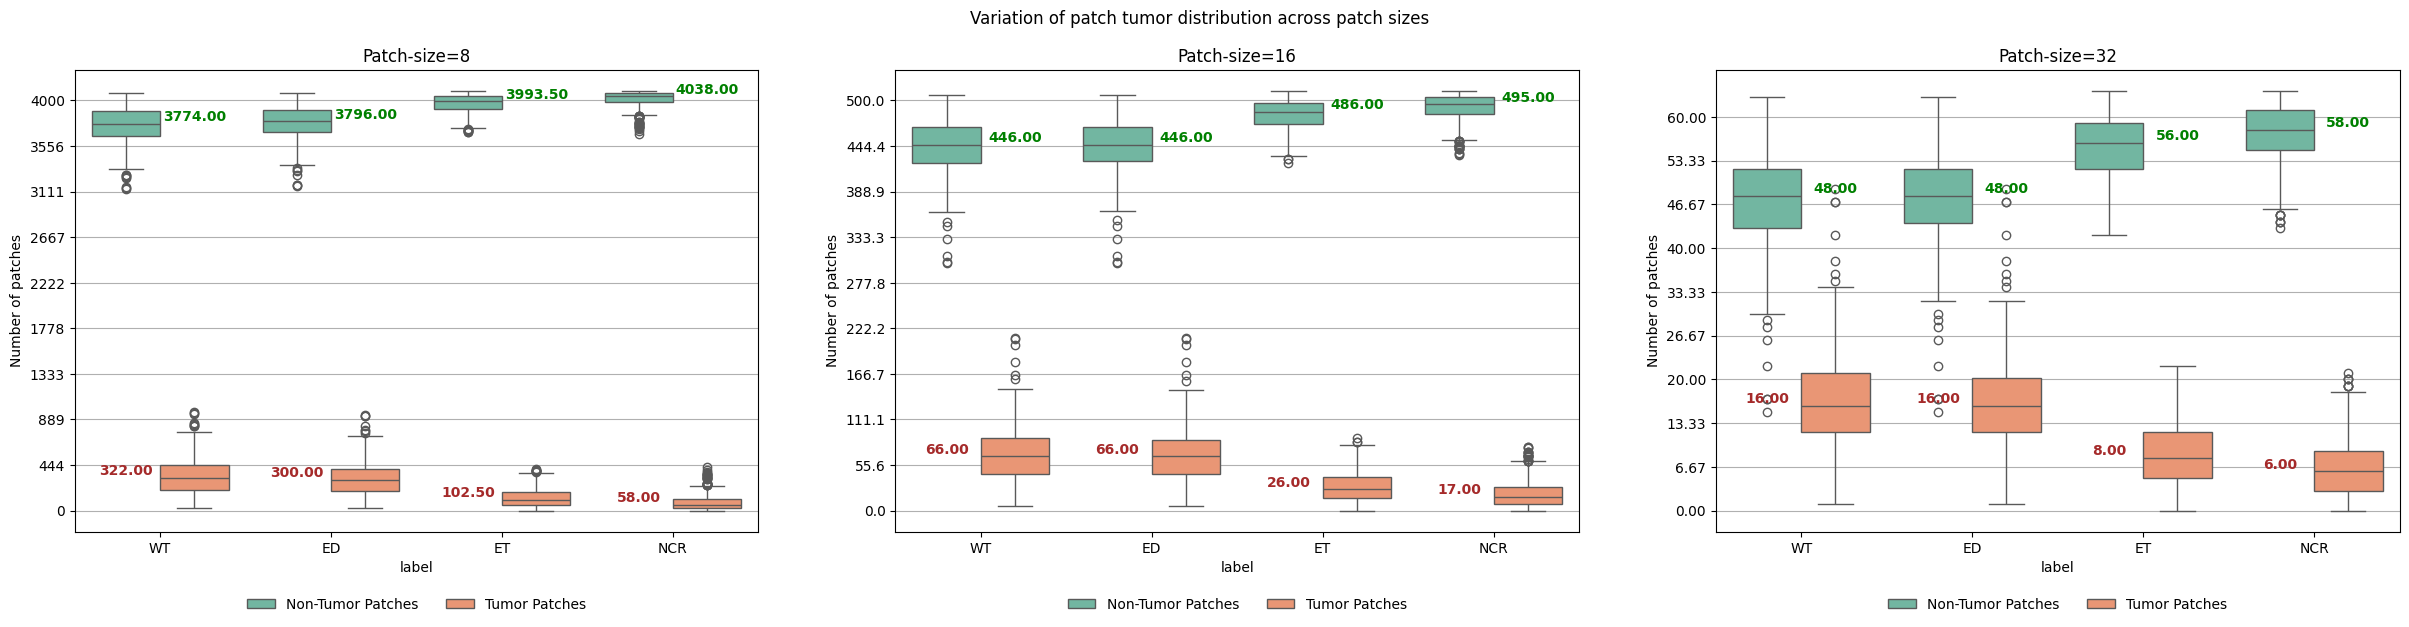

In [33]:
#Plot variation of patch tumor distribution across patch sizes
_patch_sizes = [8, 16, 32]
_y = 'counts'
max_yticks_dict = {8:4000, 16:500, 32:60}

fig, axes = plt.subplots(1,len(_patch_sizes),figsize=(30,6))
for i, ax in enumerate(axes):
    _patch_size = _patch_sizes[i]
    _df = hist2_stats_df[hist2_stats_df['patch_size']==_patch_size]
    _max_yticks = 1.0 if _y == 'density' else max_yticks_dict[_patch_size]
    _plot_boxplot_ax(df=_df, ax=ax, y=_y, max_yticks=_max_yticks)
    ax.set_title(f'Patch-size={_patch_size}')

fig.suptitle(f'Variation of patch tumor distribution across patch sizes')


### Observation:
<ins>16x16x16 patches (n=512):</ins> \
On **average**, there are 445 non-tumor patches and 67 tumor patches \
The **maximum** of tumor patches found in an image is 213

<ins>32x32x32 patches (n=64):</ins> \
On **average**, there are 48 non-tumor patches and 16 tumor patches \
The **maximum** of tumor patches found in an image is 48

### Patch Selection during Training

##### Diverse strategy: Biased towards tumor patches+All samples have a non-zero prob of getting selected
Sample C patches from N patches based on their weights. Add a small weight to Non-tumor patches so that have a non-zero probability of getting selected. Mix of weighted+uniform sampling to inrease diversity?


In [41]:
#Check number of images for which there are more than N tumor patches
key = 'hist2_16'
N=150
num_imgs = (hist_data[key][:,1] > N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data[key][:,1] >= N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data[key][i])


num number of images for which there are more than 150 tumor patches = 1
Image indices = [212]
Non-Tumor vs Tumor Patch counts of these images:
 [[317 195]]


In [ ]:
#Filter images wrt numof tumor patches
N=30
num_imgs = (hist_data['hist2_32'][:,1] == N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_32'][:,1] == N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_32'][i])

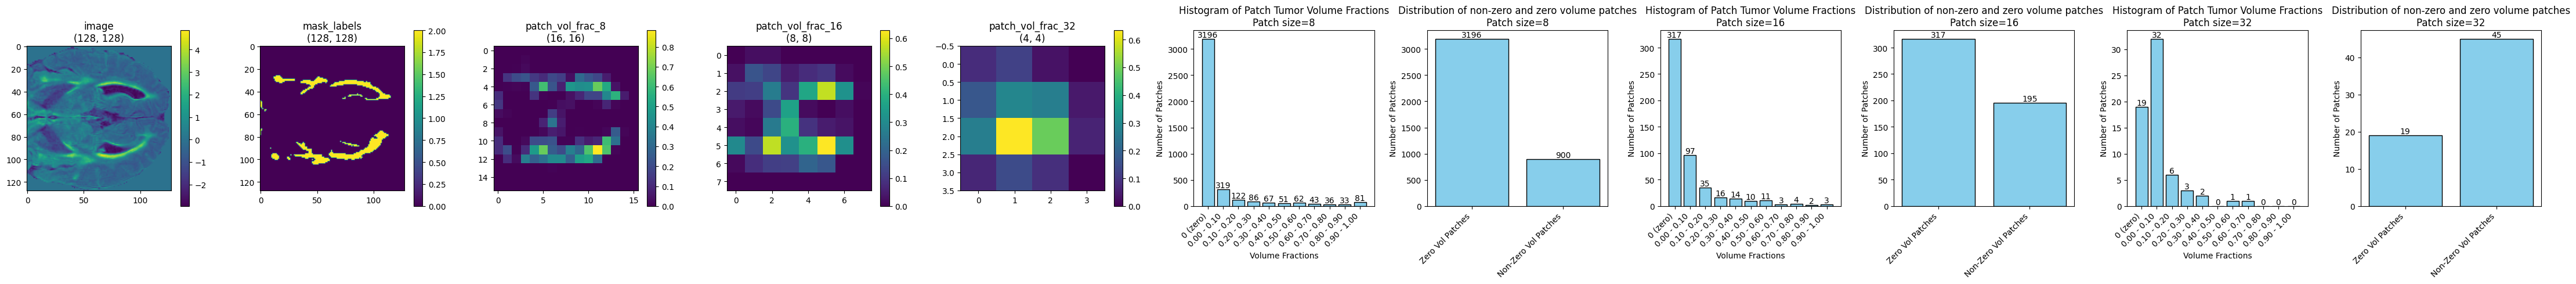

In [42]:
#Visualize these images
idx = 212
to_imshow = []
data_ = val_data.__getitem__(idx)
data_.pop('patch_tumor_labels')
hist_8 = compute_histogram(patch_tumor_vol_fracs['8'][idx], res=8)
hist_16 = compute_histogram(patch_tumor_vol_fracs['16'][idx], res=16)
hist_32 = compute_histogram(patch_tumor_vol_fracs['32'][idx], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['8', '16', '32'])
data_1.update(hist_8)
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

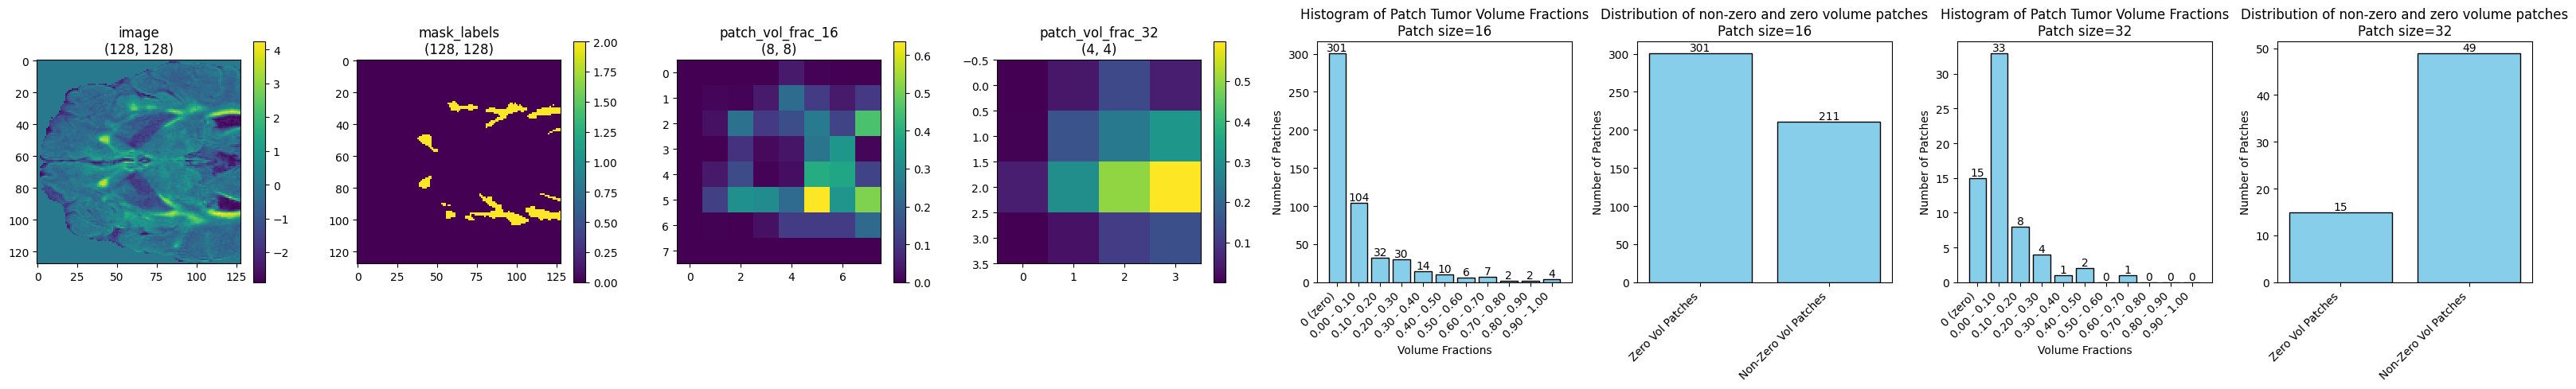

In [22]:
#Visualize these images
idx = 212
to_imshow = []
data_ = val_data.__getitem__(idx)
data_.pop('patch_tumor_labels')
hist_16 = compute_histogram(patch_tumor_vol_fracs['16'][idx], res=16)
hist_32 = compute_histogram(patch_tumor_vol_fracs['32'][idx], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

In [ ]:
idx = 212
all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
all_patch_vols=torch.sort(all_patch_vols).values
print('All patches vol fracs sorted' ,all_patch_vols)
print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
all_patch_vols=all_patch_vols.squeeze(dim=0)

#### Patch Sampling
- Sampling should be biased towards tumor patches, and patches with higher tumor vols
- Sampling strategy should also cover the entire space of patches, ie mix of tumor and non tumor patches \
        No patch should go unseen. Model should see all the patches at least once during training

Idea: Add a small weight *eps* to all the patches so that the non-tumor patches also have > 0 probability of getting sampled \
*Higher the added weight, closer the sampling gets to uniform sampling*

wt of a patch = patch_tumor_vol_frac + eps

*eps scheduling*: Instead of adding a fixed weight, add **higher** weights in the **beginning** of training, so that model sees both tumor and non-tumor patches; \
As training progresses, **decreases** the added weights, so that the sampling becomes more biased towards the tumor patches

#### Comparison between different different values of eps, and fixed / dynamic eps
Goal: 
- Good patch coverage, ie after sampling for N rounds, all patches should be seen, and, 
- Biased sampling, ie Patches with higher tumor vols should be selected more often

Validation scheme:
Sample 32 out of 64 patches of an image N times, and after N rounds, count how many times each patch was sampled 

The patch distribution should be biased towards higher tumor vol patches, moreover,  non-tumor patches should also have non-zero counts. 

To see which sampling strategy captures both of these characteristics, compute similarity between the evaluated patch counts distribution and a baseline uniform and weighted patch distribution



In [22]:
hist_data['hist2_16'][:,1]

array([ 91,  47,  60,  64,  76,  36,  37,  17,  83,  43,  50,  57,  28,
       109,  57,  51,  89,  66,  35,  69,  71,  38,  24,  68,  48,  52,
        69,  46,  99,  35, 111, 103,  77,  25,  56, 103,  34,  83,  44,
        44,  55,  65,  62,  38,  23,  54,  26,  17,  81,  81,  38,  79,
        45,  80,  43,  68,  32,  33,  44,  76, 115,  37,  50,  40, 118,
        21,  94,  84,  70,  39,  64, 108,  39,  89, 111,  80,  99,  80,
        96, 116,  64,  72, 120,  68,  80,  98,  82,  62,  57,  55,  49,
        52,  85,  93,  43,  57,  46,  38,  43, 100,  79,  61,  51, 140,
       123,  39,  28,  89,  96,  92,  83,  41,  64,  85,  72, 124,  49,
        62,  73,  70,  86,  75,  27,  37,  41,  53,  88,  65, 173,  91,
        92,  96,  48,  72, 109,  50,  92, 112,  63,  85,  77, 146,  54,
        61,  69, 120,  69,  16,  54,  61,  62,  76,  28,  94,  60,  56,
        43,  78,  53, 110,  33,  53,  15,  53,  72,  57,  94,  53,  98,
        20,  58,  91,  37,  87, 100,  83, 108,  58,  67,  18,  8

In [28]:
#Filter images wrt numof tumor patches
N = 15
num_imgs = (hist_data['hist2_16'][:,1] < N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_16'][:,1] < N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_16'][i])

num number of images for which there are more than 15 tumor patches = 4
Image indices = [183 220 222 246]
Non-Tumor vs Tumor Patch counts of these images:
 [[500  12]
 [498  14]
 [508   4]
 [499  13]]


Processing image 222
Non-Tumor and Tumor Patch Counts [508   4]
All patches vol fracs sorted metatensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0

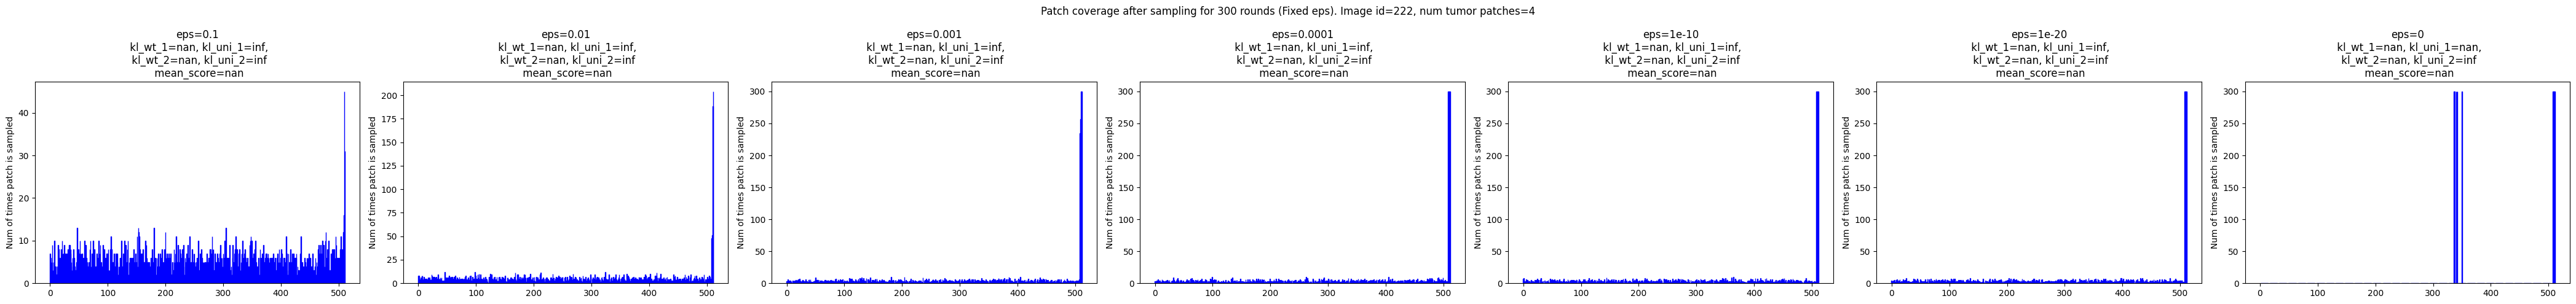

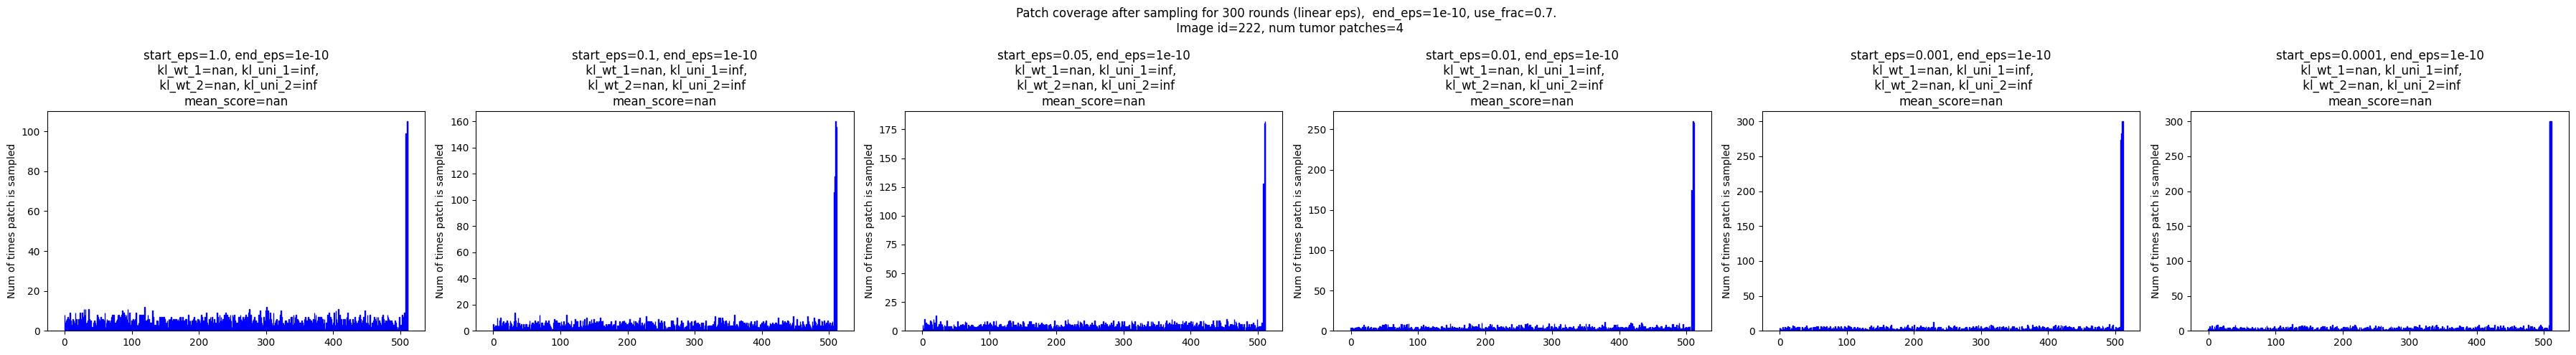

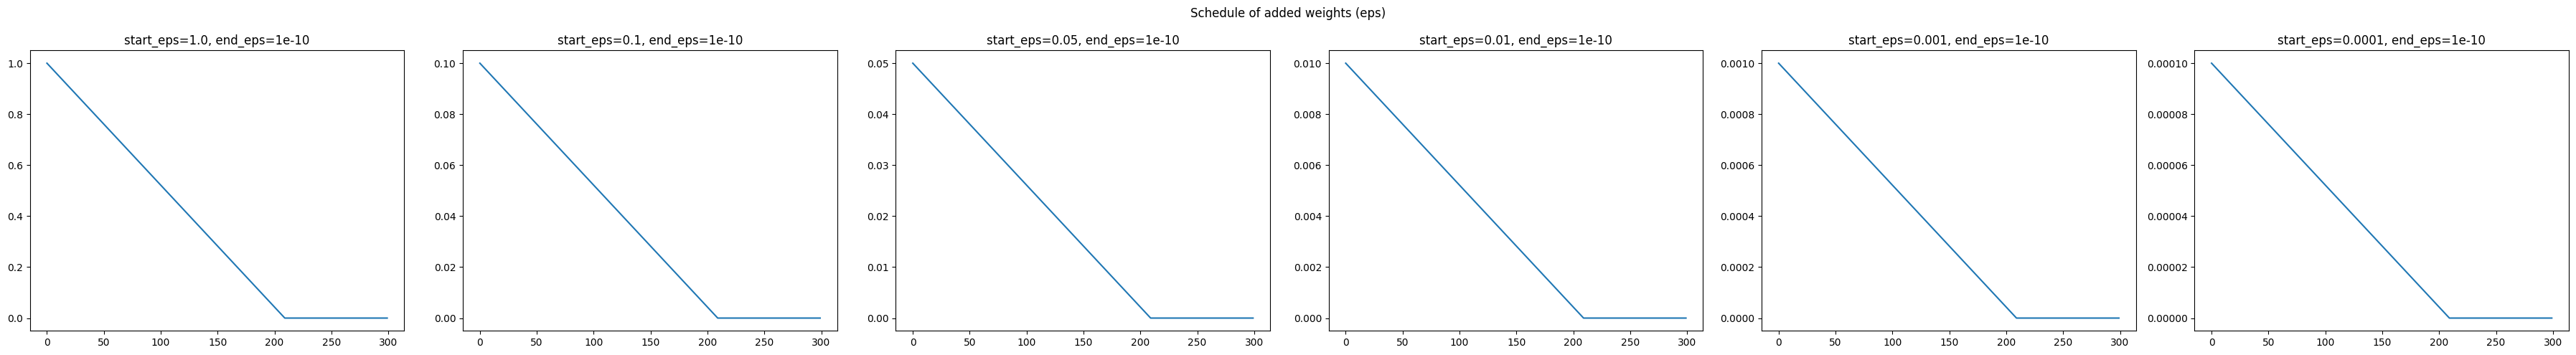

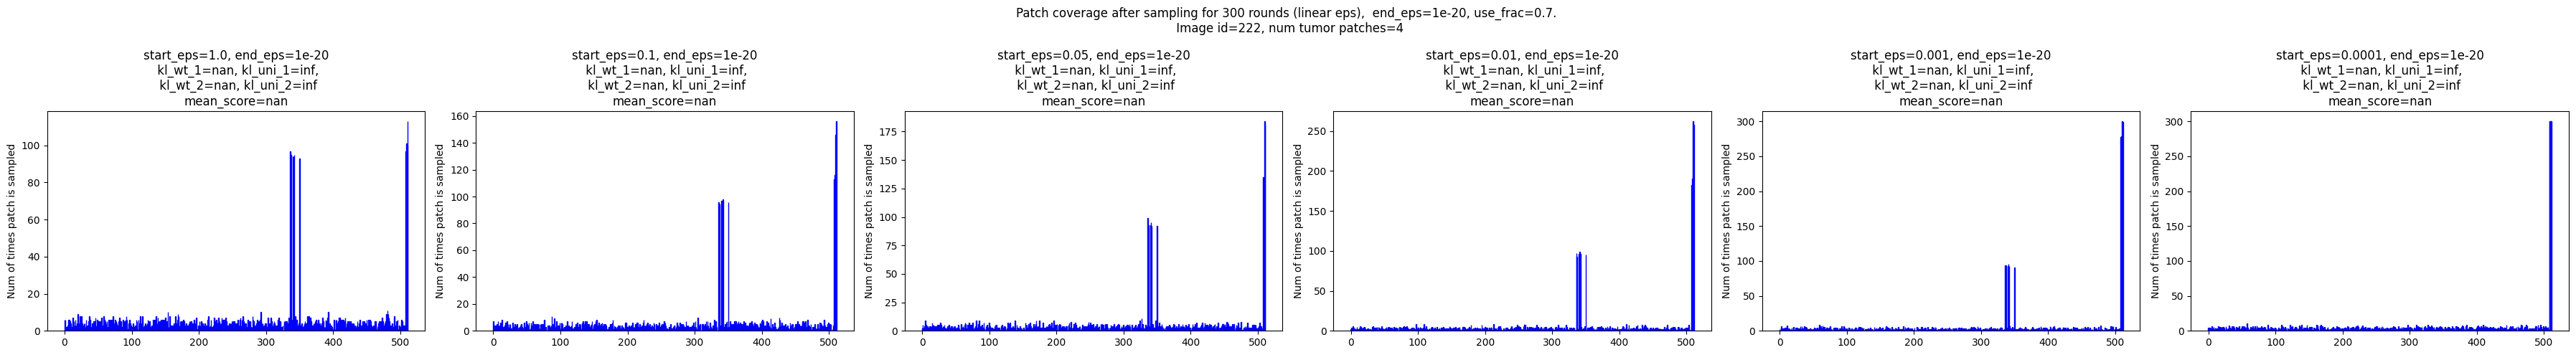

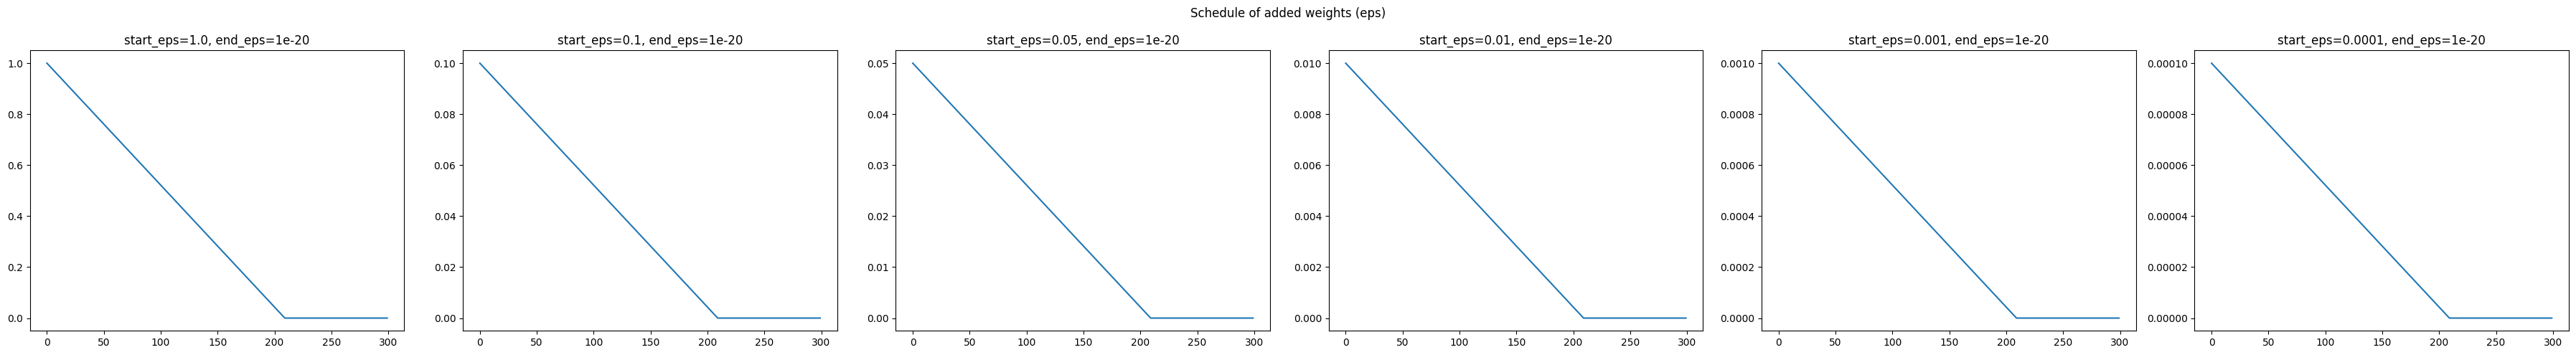

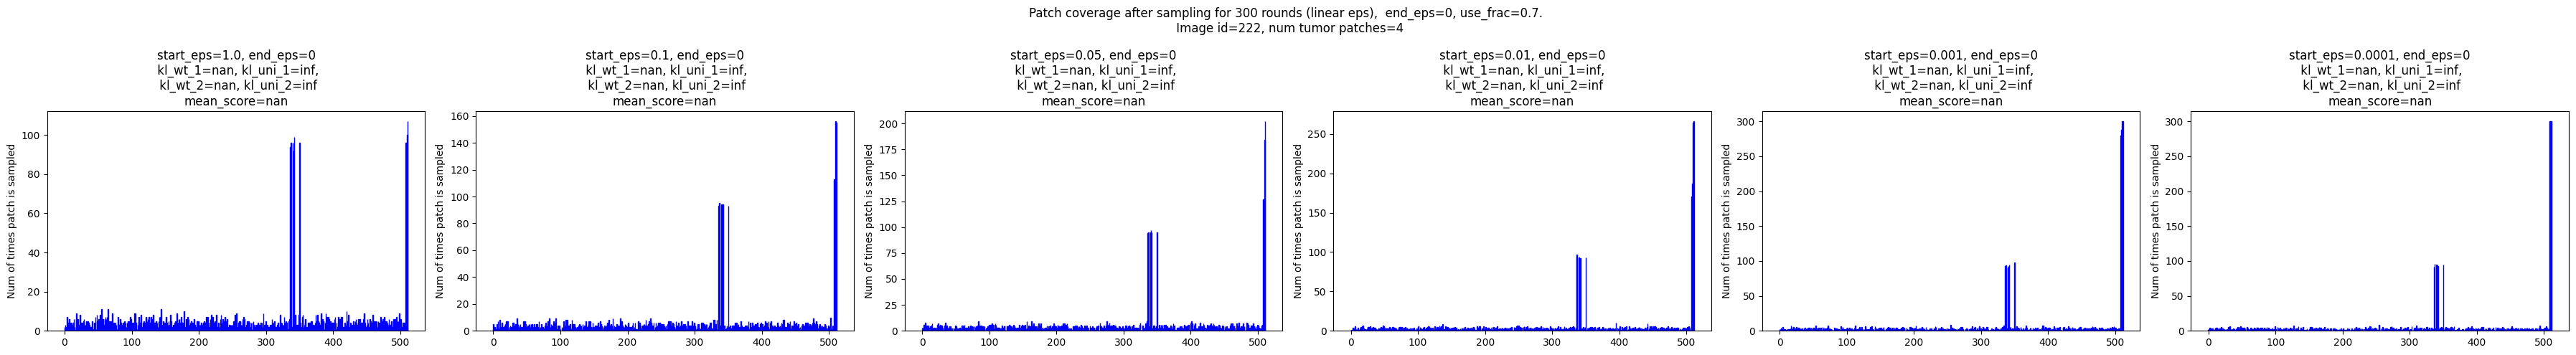

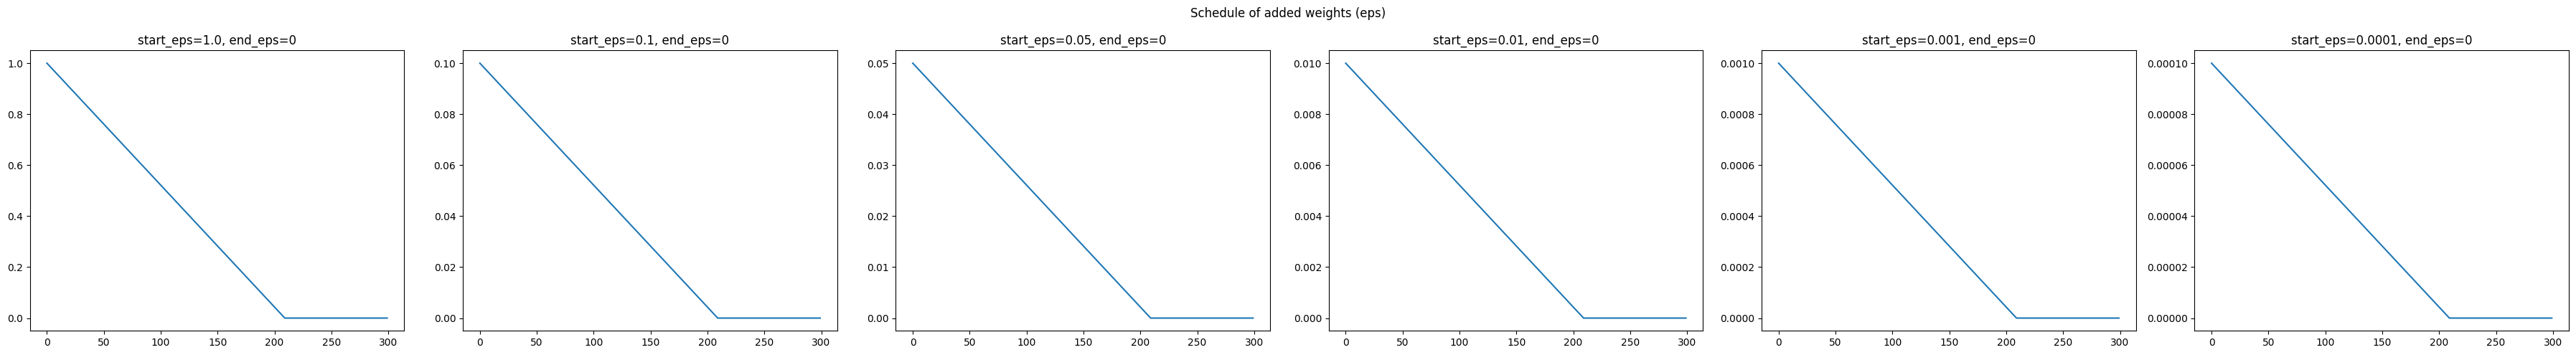

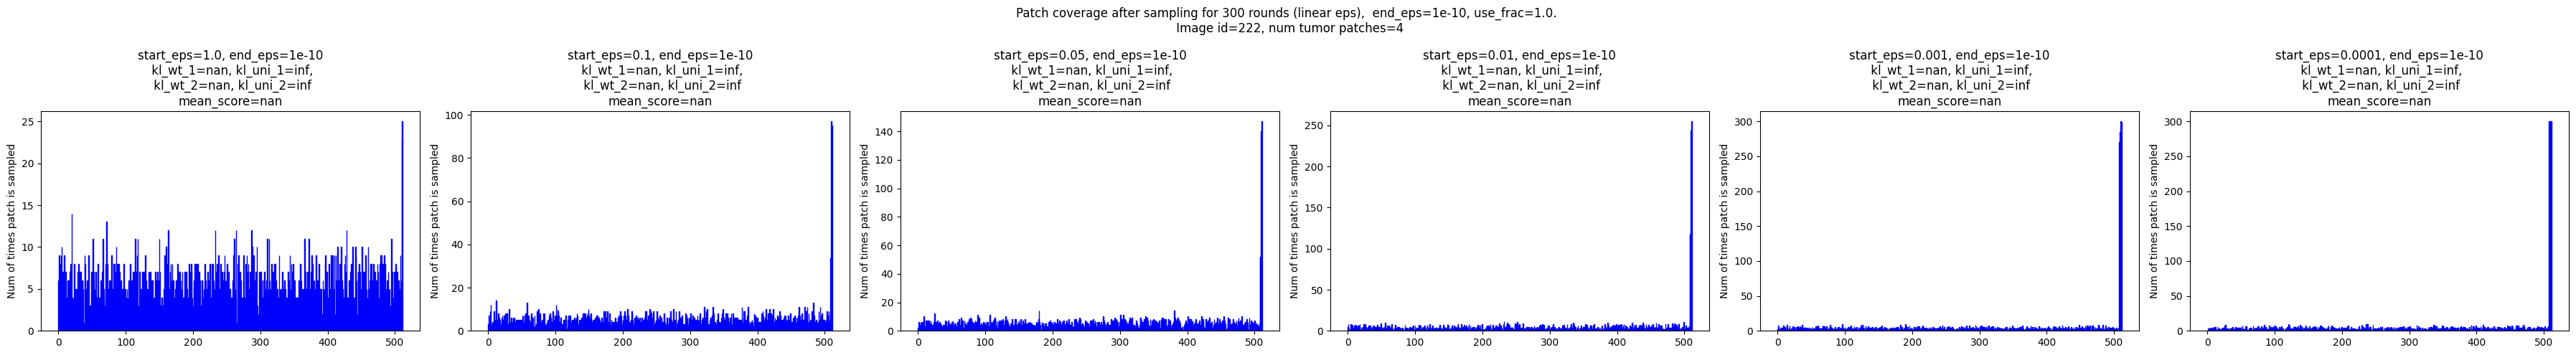

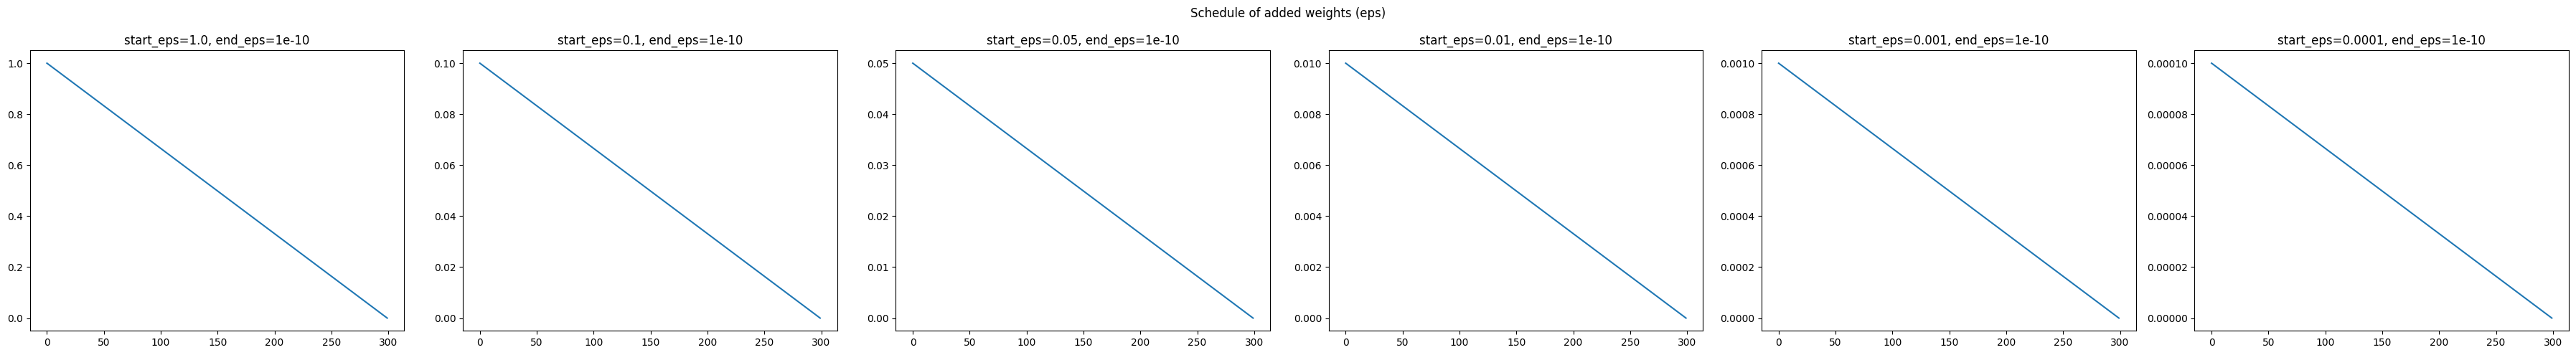

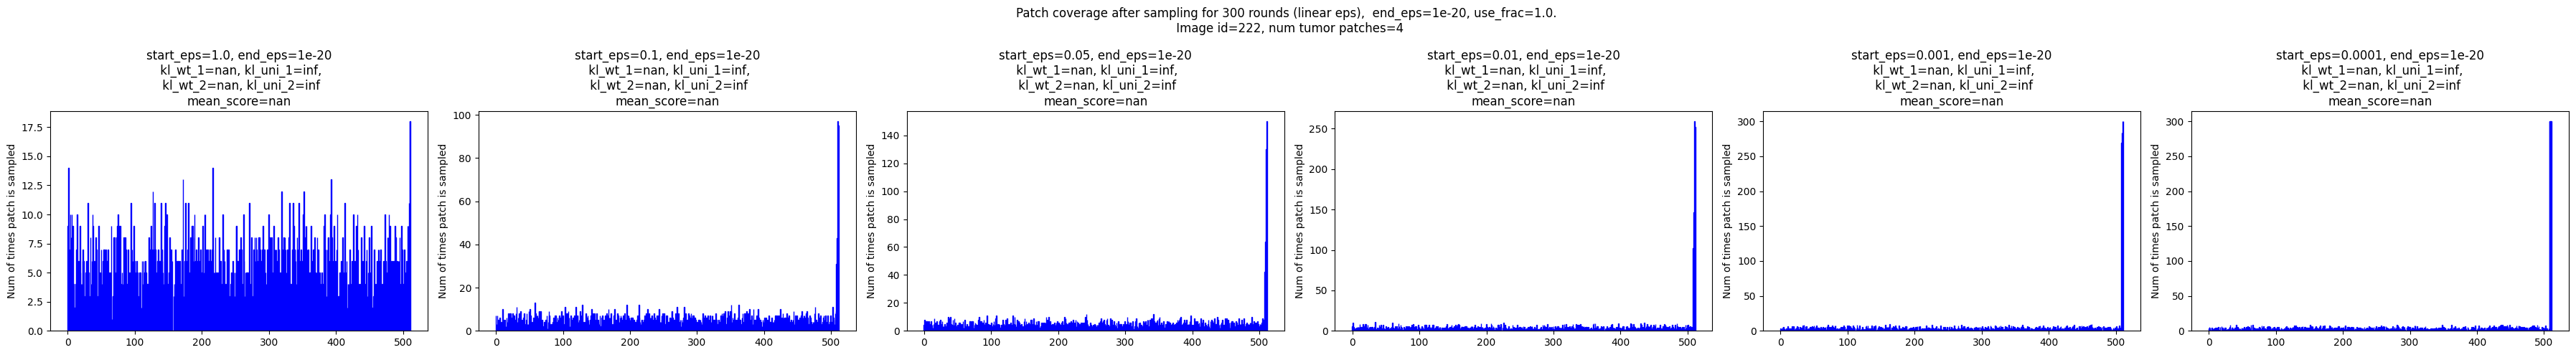

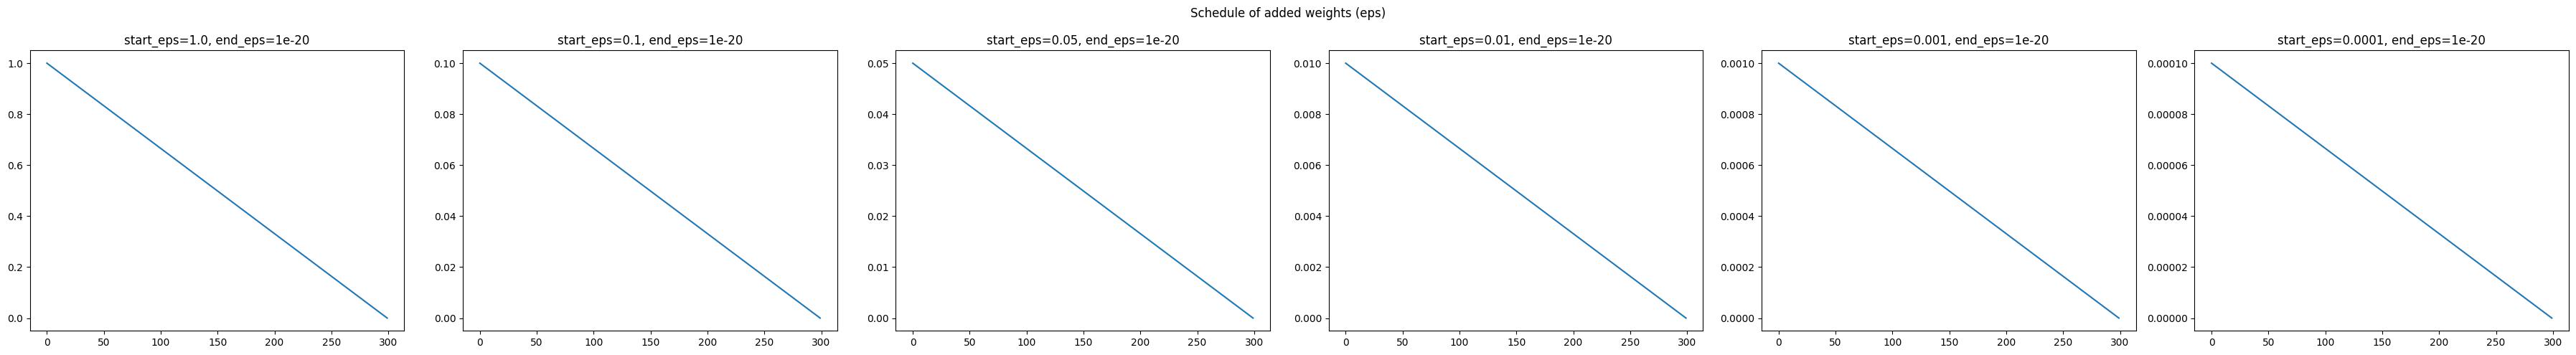

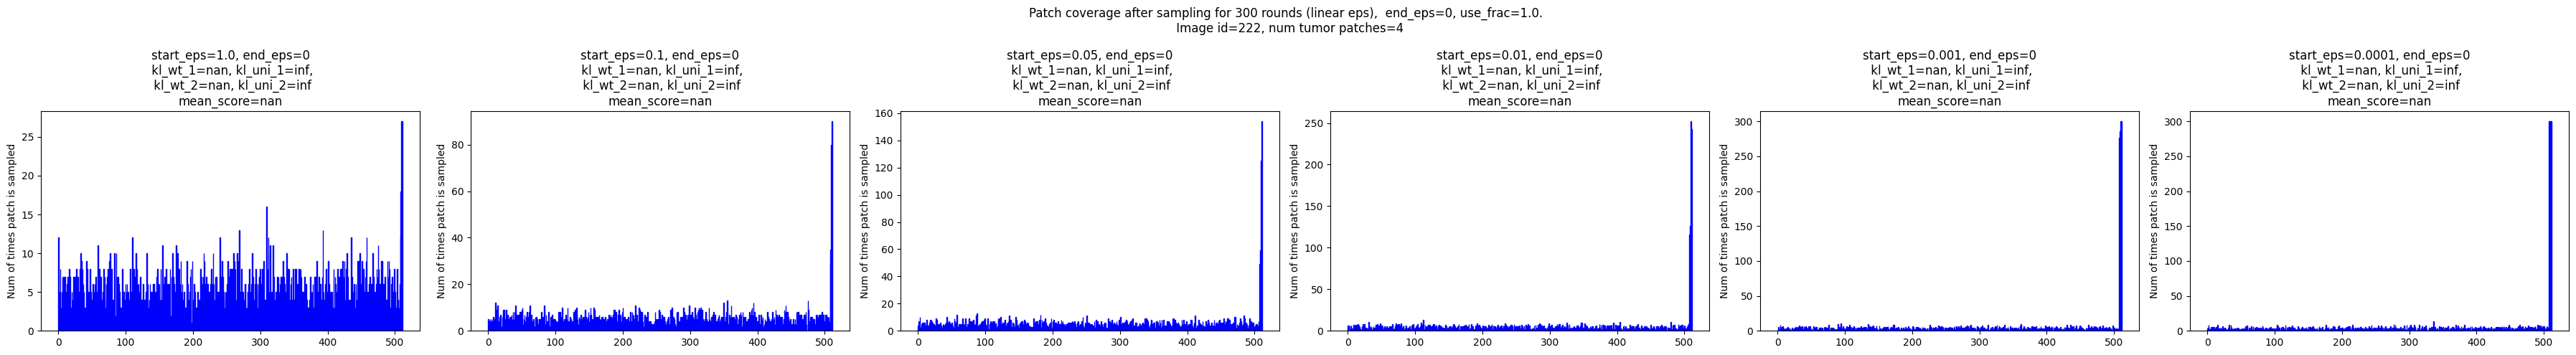

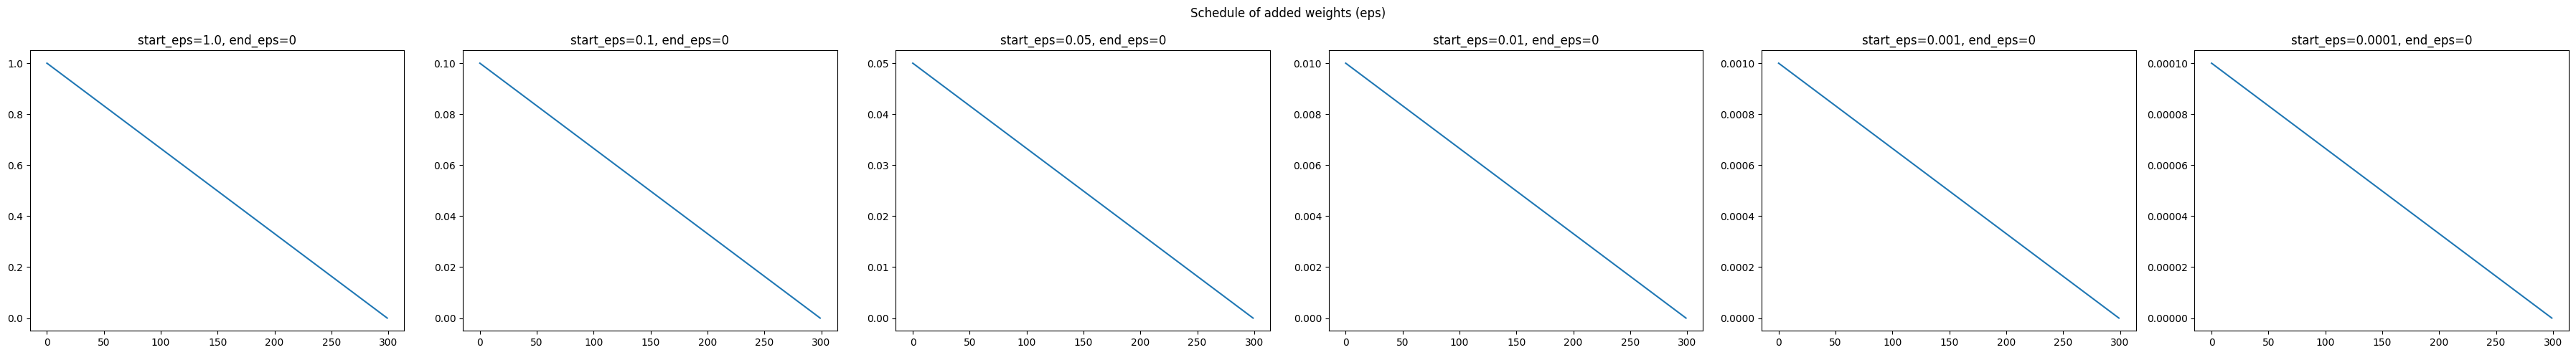

In [32]:
def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,end_eps=0.0,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps - ((start_eps-end_eps)*(i/(N_use-1)))
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='blue')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=10  #num of patches to sample out of 64 patches

base_epss = [0.1,0.01,0.001,1e-4, 1e-10, 1e-20, 0]

use_fracs = [0.7, 1.0]
schedules = ['linear']
start_epss = [1.0, 0.1,0.05,0.01,0.001,1e-4]
end_epss = [1e-10, 1e-20, 0]

#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]
#for idx in range(len(val_data)):
image_idxs = [222]
patch_size = 16
key = f'hist2_{patch_size}'
for idx in image_idxs:
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data[key][idx])
    num_tumor = hist_data[key][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs[str(patch_size)][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print(all_patch_vols.nonzero())
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    nrow, ncol = 1, len(base_epss)
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_wt_1+kl_uni_1)
        kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        score_2 = kl_wt_2+kl_uni_2
        mean_score = 0.5*(score_1+score_2)
        ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\n kl_wt_1={kl_wt_1:.5f}, kl_uni_1={kl_uni_1:.5f},\n kl_wt_2={kl_wt_2:.5f}, kl_uni_2={kl_uni_2:.5f}\n mean_score={mean_score:.5f}")

    fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            for end_eps in end_epss:
                nrow, ncol = 1, len(start_epss)
                fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white") 
                fig1, ax1 = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")

                for i,start_eps in enumerate(start_epss):
                    counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,end_eps=end_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                    counts_p = counts/counts.sum()

                    kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                    kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                    score_1 = 10*(kl_wt_1+kl_uni_1)
                    kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                    kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                    score_2 = kl_wt_2+kl_uni_2
                    mean_score = 0.5*(score_1+score_2)

                    ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}, end_eps={end_eps}\n kl_wt_1={kl_wt_1:.5f}, kl_uni_1={kl_uni_1:.5f},\n kl_wt_2={kl_wt_2:.5f}, kl_uni_2={kl_uni_2:.5f}\nmean_score={mean_score:.5f}")

                    ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}, end_eps={end_eps}")

                fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps),  end_eps={end_eps}, use_frac={use_frac}. \n Image id={idx}, num tumor patches={num_tumor}")
                fig.tight_layout()
                fig1.suptitle('Schedule of added weights (eps)')
                fig1.tight_layout()

In [ ]:
def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,end_eps=0.0,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps - ((start_eps-end_eps)*(i/(N_use-1)))
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='blue')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=10  #num of patches to sample out of 64 patches

base_epss = [0.1,0.01,0.001,1e-4, 1e-10, 1e-20, 0]

use_fracs = [0.7, 1.0]
schedules = ['linear']
start_epss = [1.0, 0.1,0.05,0.01,0.001,1e-4]
end_epss = [1e-10, 1e-20, 0]

#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]
#for idx in range(len(val_data)):
image_idxs = [222]
patch_size = 16
key = f'hist2_{patch_size}'
for idx in image_idxs:
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data[key][idx])
    num_tumor = hist_data[key][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs[str(patch_size)][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print(all_patch_vols.nonzero())
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    nrow, ncol = 1, len(base_epss)
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_wt_1+kl_uni_1)
        kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        score_2 = kl_wt_2+kl_uni_2
        mean_score = 0.5*(score_1+score_2)
        ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\n kl_wt_1={kl_wt_1:.5f}, kl_uni_1={kl_uni_1:.5f},\n kl_wt_2={kl_wt_2:.5f}, kl_uni_2={kl_uni_2:.5f}\n mean_score={mean_score:.5f}")

    fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            for end_eps in end_epss:
                nrow, ncol = 1, len(start_epss)
                fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white") 
                fig1, ax1 = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")

                for i,start_eps in enumerate(start_epss):
                    counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,end_eps=end_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                    counts_p = counts/counts.sum()

                    kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                    kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                    score_1 = 10*(kl_wt_1+kl_uni_1)
                    kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                    kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                    score_2 = kl_wt_2+kl_uni_2
                    mean_score = 0.5*(score_1+score_2)

                    ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}, end_eps={end_eps}\n kl_wt_1={kl_wt_1:.5f}, kl_uni_1={kl_uni_1:.5f},\n kl_wt_2={kl_wt_2:.5f}, kl_uni_2={kl_uni_2:.5f}\nmean_score={mean_score:.5f}")

                    ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}, end_eps={end_eps}")

                fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps),  end_eps={end_eps}, use_frac={use_frac}. \n Image id={idx}, num tumor patches={num_tumor}")
                fig.tight_layout()
                fig1.suptitle('Schedule of added weights (eps)')
                fig1.tight_layout()

In [44]:
#Filter images wrt numof tumor patches
N = 60
num_imgs = (hist_data['hist2_16'][:,1] > N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_16'][:,1] > N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_16'][i])

num number of images for which there are more than 60 tumor patches = 141
Image indices = [  0   3   4   8  13  16  17  19  20  23  26  28  30  31  32  35  37  41
  42  48  49  51  53  55  59  60  64  66  67  68  70  71  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  92  93  99 100 101 103 104
 107 108 109 110 112 113 114 115 117 118 119 120 121 126 127 128 129 130
 131 133 134 136 137 138 139 140 141 143 144 145 146 149 150 151 153 157
 159 164 166 168 171 173 174 175 176 178 180 181 182 186 187 189 191 192
 193 194 195 198 199 200 202 204 206 208 209 210 212 214 215 217 218 221
 226 227 234 235 236 241 243 244 248 249 251 252 255 258 259]
Non-Tumor vs Tumor Patch counts of these images:
 [[421  91]
 [448  64]
 [436  76]
 [429  83]
 [403 109]
 [423  89]
 [446  66]
 [443  69]
 [441  71]
 [444  68]
 [443  69]
 [413  99]
 [401 111]
 [409 103]
 [435  77]
 [409 103]
 [429  83]
 [447  65]
 [450  62]
 [431  81]
 [431  81]
 [433  79]
 [432  80]
 [444  68]
 [436  76]
 [397 115]
 

In [90]:
def sample_patch_indices(patch_tumor_vol_fracs, eps=1e-20, num_samples=None):
    #patch_tumor_vol_fracs = (B,1,W_,H_,D_)
    wts = patch_tumor_vol_fracs.view(1,-1).squeeze(dim=0)
    wts = wts + eps
    if not num_samples:
        num_samples = wts.shape[0] // 2
    sampled_indices_flat = torch.multinomial(wts, num_samples=num_samples)
    sampled_indices_nd = torch.unravel_index(sampled_indices_flat, patch_tumor_vol_fracs.shape)
    return sampled_indices_flat, sampled_indices_nd

def ravel_index(index:torch.Tensor, shape:tuple[int]):
    """Ravel multi-dimensional indices to 1D index
    similar to np.ravel_multi_index
    Args:
        index (torch.tensor): indices in reversed order dn, ..., d1, with shape (..., n)
        shape (tuple): dn, ..., d1
    """
    #index = torch.tensor(index, dtype=torch.int64)
    shape = torch.tensor((1,) + shape[::-1], dtype=torch.int64).to(index) # =(1, d1, d1*d2, ..., d1*...*dn)
    shape = torch.cumprod(shape, dim=0)[:-1].flip(0) # =(d1*...*dn-1, ..., d1*d2, d1, 1)
    index = (index * shape).sum(dim=-1) # (...,)
    return index

def ravel_tuple_index(index:tuple[torch.Tensor], shape:tuple[int]):
    """Ravel multi-dimensional indices to 1D index
    similar to np.ravel_multi_index
    Args:
        index tuple(torch.tensor): each tuple item indices a certain dimension with shape (1, num_idxs)
        shape (tuple): dn, ..., d1
    """
    index = torch.stack(index,dim=0).T
    return ravel_index(index, shape)

idx = torch.randint(high=len(val_data), size=(1,))
import time
start_time = time.time()
wts = torch.rand(512)
idxs_1_flat, idxs_1 = sample_patch_indices(patch_tumor_vol_fracs['16'][idx], eps=1e-20, num_samples=(patch_tumor_vol_fracs['16'][idx] > 0).sum())
dur1 = time.time() - start_time
print(dur1)
start_time = time.time()
idxs_2 = (patch_tumor_vol_fracs['16'][idx] > 0).nonzero(as_tuple=True)
idxs_2_flat = ravel_tuple_index(idxs_2, patch_tumor_vol_fracs['16'][idx].shape)
dur2 = time.time() - start_time
print(dur2)
assert set(idxs_2_flat.tolist()) == set(idxs_1_flat.tolist())


0.0046885013580322266
0.0014853477478027344


In [58]:
set(idxs_2_flat.tolist()) == set(idxs_1_flat.tolist())

True

In [55]:
idxs_1_flat

metatensor([422, 294, 365, 293, 413, 355, 300, 357, 341, 350, 284, 430, 364, 405,
        348, 342, 286, 493, 366, 412, 358, 277, 285, 429, 373, 349, 356, 303,
        310, 309, 372, 302, 486, 301, 317, 421, 295, 316, 374, 308, 428, 381,
        423, 359, 438, 477, 367, 292, 220, 437, 485, 363, 414, 478, 420, 436,
        278, 245, 283, 318, 221, 492, 228, 406, 404, 340, 237, 494, 469, 431,
        380, 375, 476, 351, 229, 276, 501, 311, 291, 382, 445, 347, 246, 287,
        415, 371, 470, 230, 253, 227, 238])

In [48]:
hist_data['hist2_16'][0]
(patch_tumor_vol_fracs['16'][0] > 0).sum()

metatensor(91)

In [ ]:
import time
start_time = time.time()
wts = torch.rand(512)
idxs = torch.multinomial(wts, 128)
dur = time.time() - start_time
print(dur)
wts[idxs] = 0
start_time = time.time()
torch.nonzero(wts,as_tuple=True)
dur = time.time() - start_time
print(dur)


0.003187894821166992
0.00027823448181152344


In [41]:
torch.multinomial(torch.rand(512), 128)


tensor([370,  78, 487, 252, 164, 351,  49,  72,  68,  74, 378, 254, 335, 482,
        423, 144, 387,  93, 356,  56, 233, 448,  48, 127, 488, 248, 479,  39,
         12,  75,  53, 413, 325, 449, 402, 303, 182, 319, 466, 260, 360, 498,
        465, 185, 239, 261,   3, 167, 336,  70, 161, 455, 188,   7, 201,  41,
        113,  23, 250,  88,  97, 428, 439, 363, 401, 468, 314, 298, 429, 142,
        477, 179, 483, 441,  76, 115, 140, 506, 330, 275, 267, 211, 162,  11,
        435, 371,  29, 331, 461, 277, 308, 383, 103, 458, 232, 192, 228, 499,
        419, 287, 293,  10, 346, 380, 143, 358, 153, 300, 434, 155, 391, 317,
        123,  18, 279, 492, 348,  31, 446, 445, 295, 114, 353, 306, 339,  80,
        112, 301])

In [50]:
plt.close('all')


In [29]:
1/(16**3)

0.000244140625

In [ ]:
np.around(np.linspace(1.0, 0.2, 9), decimals=2).tolist()

Compute scores for every image and compute mean to see which *use_frac* and *start_eps* combination performs best 

Also compare between *fixed eps* and *dynamic eps* (schedule based)

In [ ]:

def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps*(1-(i/N_use))
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=256  #num of patches to sample out of 64 patches

base_epss = [20,0.1,0.01,0.001,1e-4,1e-20]
use_fracs = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
schedules = ['linear','cosine']
start_epss_1 = np.around(np.linspace(0.1, 0.01, 10), decimals=2).tolist()
start_epss_2 = np.around(np.linspace(1.0, 0.2, 9), decimals=2).tolist()
start_epss = start_epss_1 + start_epss_2 +[0.001, 1e-4]

print(start_epss)
#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]

fixed_eps_df_rows = []
dyn_eps_df_rows = []
key = 'hist2_16'
for idx in range(len(val_data)):
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data[key][idx])
    num_tumor = hist_data[key][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs['16'][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    #fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        fixed_eps_df_row = {'image_id':idx, 'num_tumor_patches':num_tumor}
        fixed_eps_df_row['eps'] = eps
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_wt_1+kl_uni_1)
    
        kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        score_2 = kl_wt_2+kl_uni_2
        mean_score = 0.5*(score_1+score_2)

        fixed_eps_df_row.update({'kl_wt_1':kl_wt_1,'kl_uni_1':kl_uni_1,'score_1':score_1, \
                        'kl_wt_2':kl_wt_2,'kl_uni_2':kl_uni_2,'score_2':score_2, 'mean_score':mean_score})
        fixed_eps_df_rows.append(fixed_eps_df_row)

        #ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")

    #fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    #fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            for i,start_eps in enumerate(start_epss):
                dyn_eps_df_row = {'image_id':idx, 'num_tumor_patches':num_tumor}
                dyn_eps_df_row.update({'schedule':schedule, 'use_frac':use_frac, 'start_eps':start_eps})
                
                counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                counts_p = counts/counts.sum()

                kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                score_1 = 10*(kl_wt_1+kl_uni_1)
            
                kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                score_2 = kl_wt_2+kl_uni_2
                mean_score = 0.5*(score_1+score_2)

                dyn_eps_df_row.update({'kl_wt_1':kl_wt_1,'kl_uni_1':kl_uni_1,'score_1':score_1, \
                                'kl_wt_2':kl_wt_2,'kl_uni_2':kl_uni_2,'score_2':score_2, 'mean_score':mean_score})
                dyn_eps_df_rows.append(dyn_eps_df_row)

                #ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")
                #ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}")

            #fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps), use_frac={use_frac}. Image id={idx}, num tumor patches={num_tumor}")
            #fig.tight_layout()
            #fig1.suptitle('Schedule of added weights (eps)')
            #fig1.tight_layout()

import pandas as pd

fixed_eps_df = pd.DataFrame.from_dict(fixed_eps_df_rows)
dyn_eps_df = pd.DataFrame.from_dict(dyn_eps_df_rows)
dyn_eps_df.to_csv('dyn_eps_df_1.csv')
fixed_eps_df.to_csv('fixed_eps_df_1.csv')

In [ ]:
dyn_eps_df

In [214]:

import pandas as pd

fixed_eps_df = pd.DataFrame.from_dict(fixed_eps_df_rows)
dyn_eps_df = pd.DataFrame.from_dict(dyn_eps_df_rows)
dyn_eps_df.to_csv('dyn_eps_df_1.csv')
fixed_eps_df.to_csv('fixed_eps_df_1.csv')


In [4]:
rootdir

'/home/ca550013/Master-Thesis/Projects/BraTS3DDiff'

In [11]:
import pandas as pd
import os
dataroot = os.path.join(rootdir, 'results', 'results', 'patch_sampling_eps_schedule')
fixed_eps_df = pd.read_csv(os.path.join(dataroot, 'fixed_eps_df_16.csv'), index_col=0)
dyn_eps_df = pd.read_csv(os.path.join(dataroot, 'dyn_eps_df_16.csv'), index_col=0)

In [12]:
fixed_eps_df.head()

,image_id,num_tumor_patches,eps,kl_wt_1,kl_uni_1,score_1,kl_wt_2,kl_uni_2,score_2,mean_score
0,0,82,20.0000,0.000154,0.000007,0.001609,0.004552,0.000003,0.004555,0.003082
1,0,82,0.1000,0.000059,0.000064,0.001232,0.003328,0.000063,0.003391,0.002312
2,0,82,0.0100,0.000022,0.000105,0.001272,0.003249,0.000104,0.003353,0.002312
3,0,82,0.0010,0.000011,0.000126,0.001372,0.003243,0.000126,0.003369,0.002371
4,0,82,0.0001,0.000006,0.000133,0.001397,0.003243,0.000133,0.003376,0.002386


            eps   kl_wt_1  kl_uni_1   kl_wt_2  kl_uni_2   score_2  mean_score
0  1.000000e-20  0.000007  0.000115  0.003942  0.000114  0.004056    0.002638
1  1.000000e-04  0.000007  0.000114  0.003942  0.000113  0.004055    0.002632
2  1.000000e-03  0.000010  0.000105  0.003942  0.000104  0.004047    0.002603
3  1.000000e-02  0.000024  0.000086  0.003949  0.000085  0.004033    0.002565
4  1.000000e-01  0.000051  0.000051  0.004059  0.000050  0.004109    0.002567
5  2.000000e+01  0.000131  0.000007  0.005258  0.000003  0.005261    0.003319


<Axes: title={'center': 'Mean score vs eps'}, xlabel='eps'>

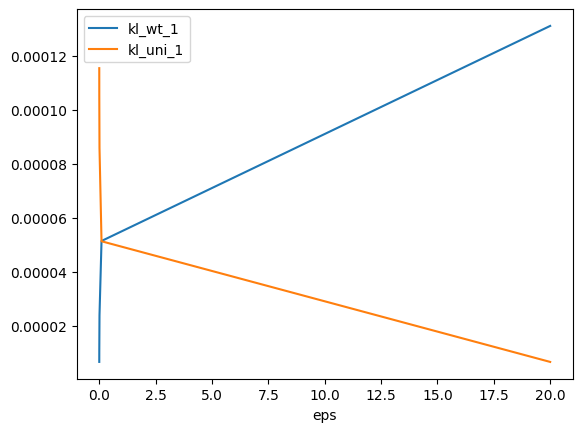

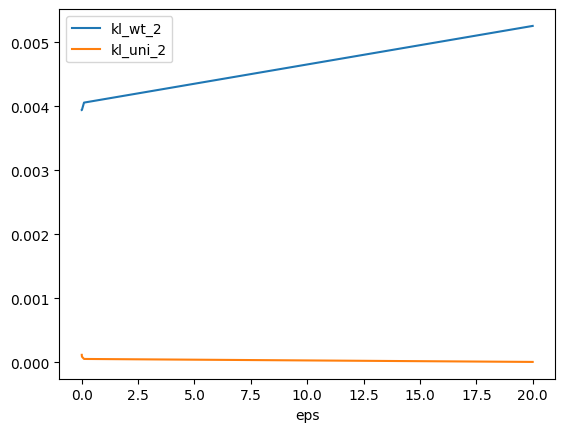

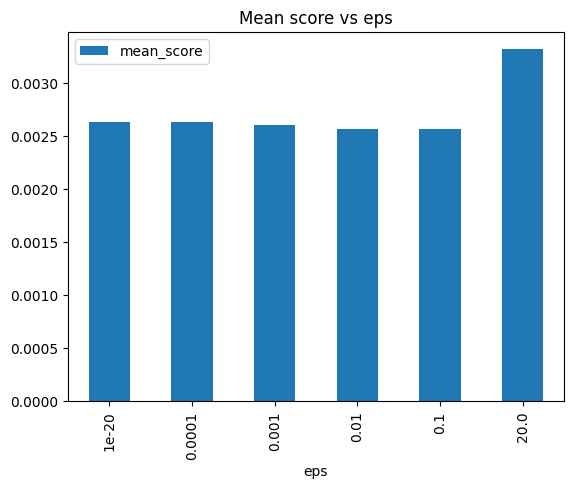

In [13]:
#find mean score for each eps 'kl_wt_2','kl_uni_2','score_2','mean_score'
fixed_eps_agg = fixed_eps_df.groupby(['eps'], as_index=False)[['kl_wt_1', 'kl_uni_1', 'kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
print(fixed_eps_agg)
fixed_eps_agg[['eps', 'kl_wt_1', 'kl_uni_1']].set_index('eps').plot()
fixed_eps_agg[['eps', 'kl_wt_2', 'kl_uni_2']].set_index('eps').plot()
fixed_eps_agg[['eps', 'mean_score']].set_index('eps').plot(kind='bar', title='Mean score vs eps')


#Obs: As eps increases, patch distrbitution becomes close to uniform, so kl_uni decreases
## and if eps is small, patch distribution is more close to weighted distribution

In [ ]:
dyn_eps_df

In [14]:
import seaborn as sns


min score config:       use_frac  start_eps schedule   kl_wt_1  kl_uni_1   score_1   kl_wt_2  \
193       0.7        0.2   linear  0.000027  0.000064  0.000914  0.004021   

     kl_uni_2   score_2  mean_score  
193  0.000063  0.004084    0.002499  


<Axes: xlabel='num_tumor_patches'>

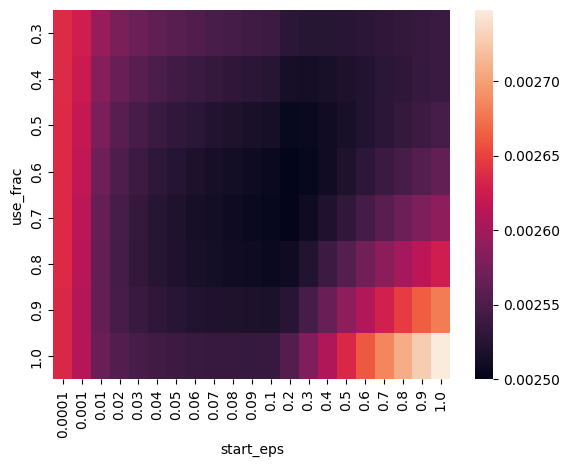

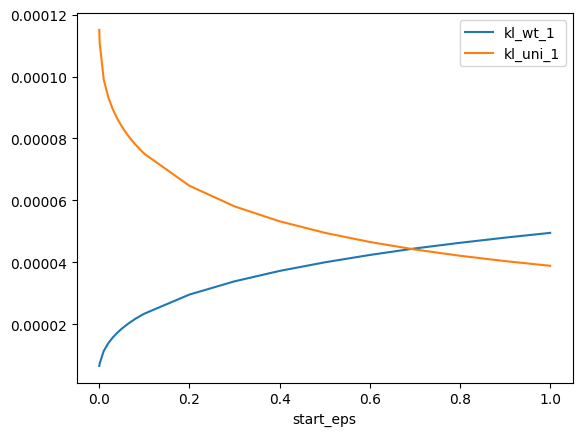

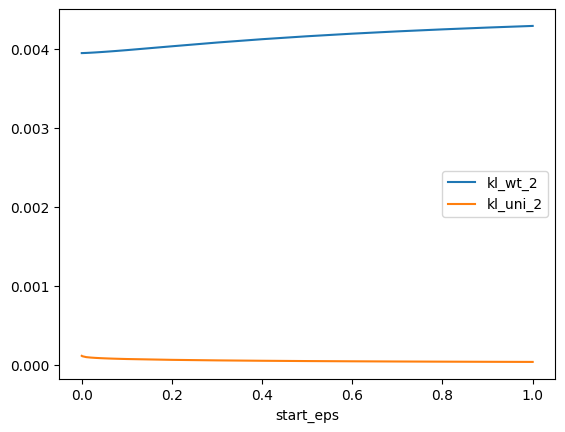

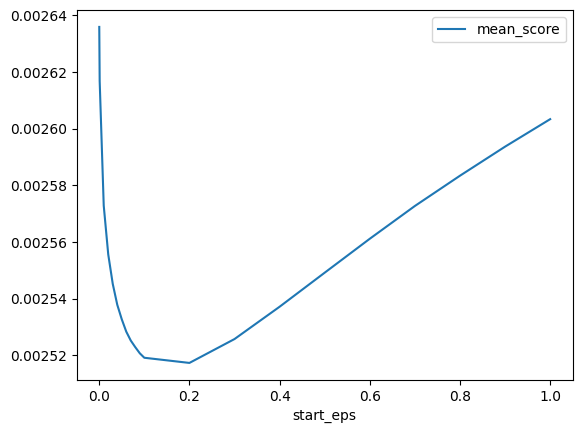

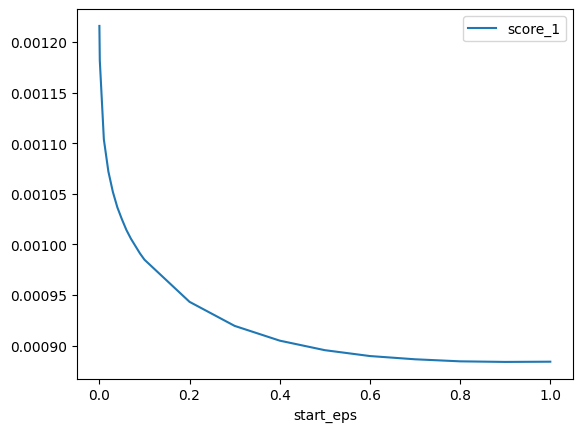

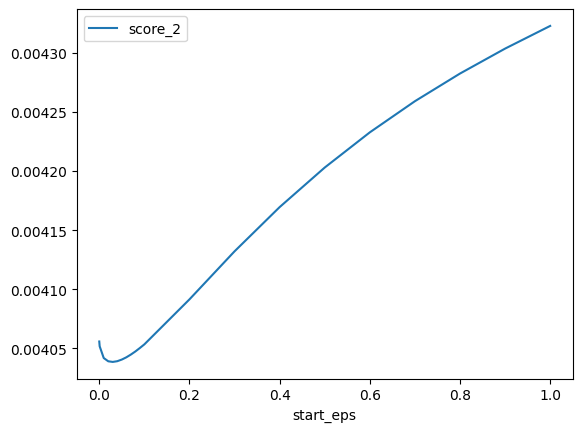

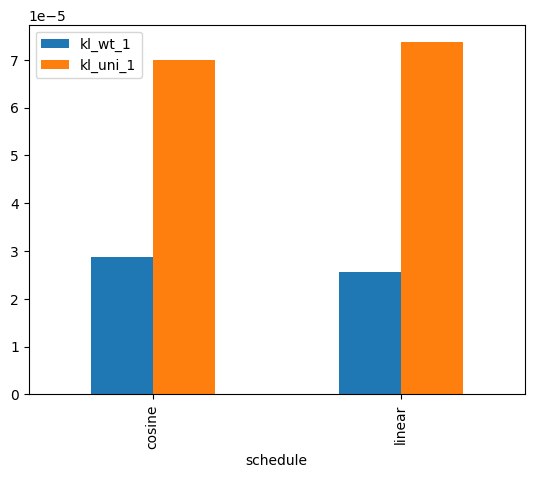

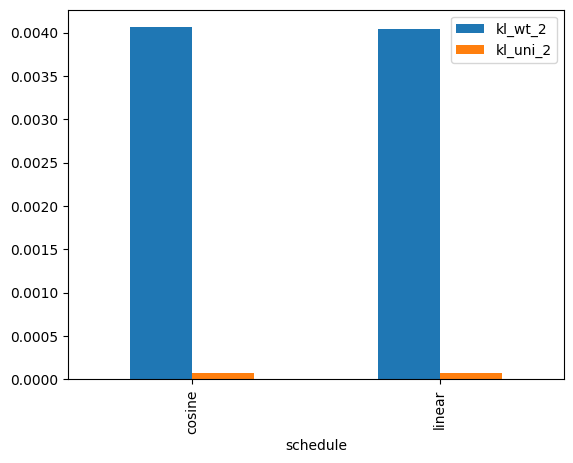

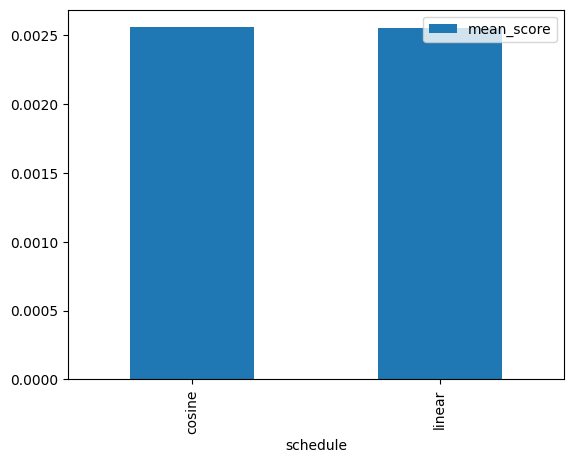

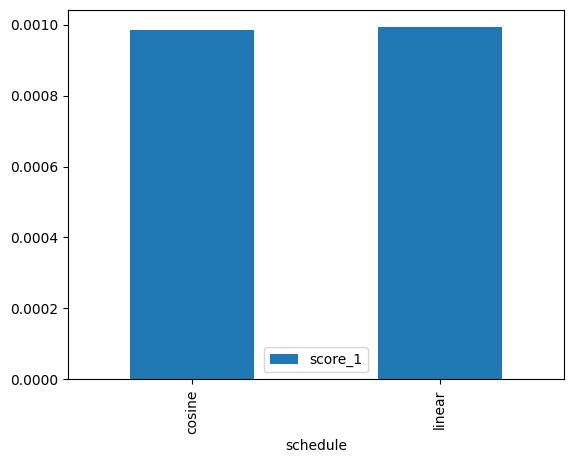

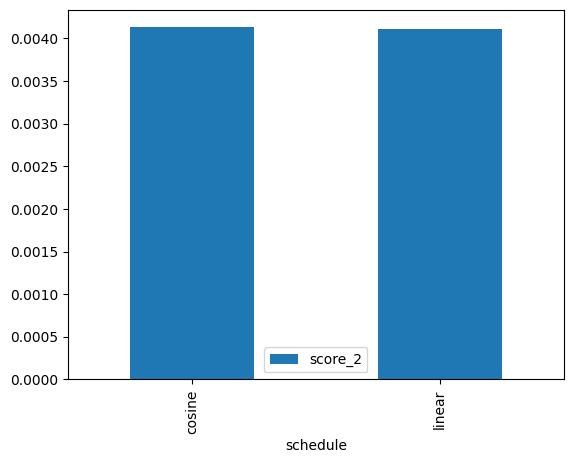

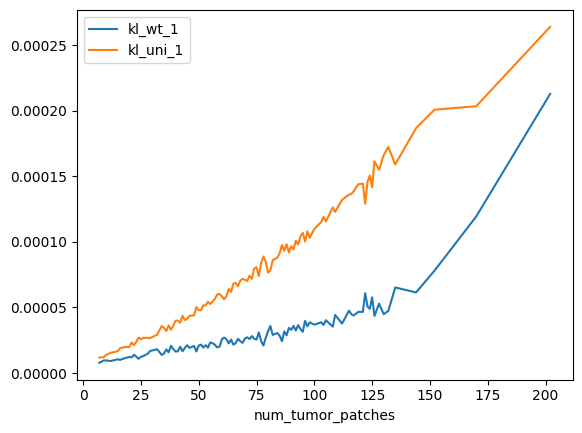

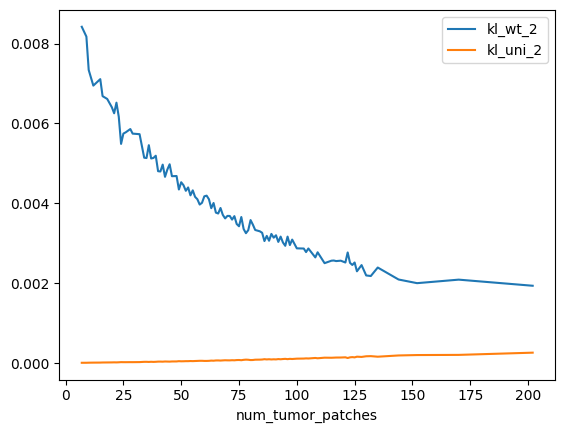

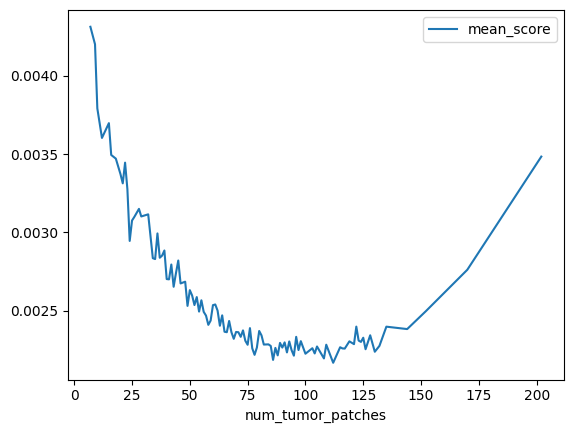

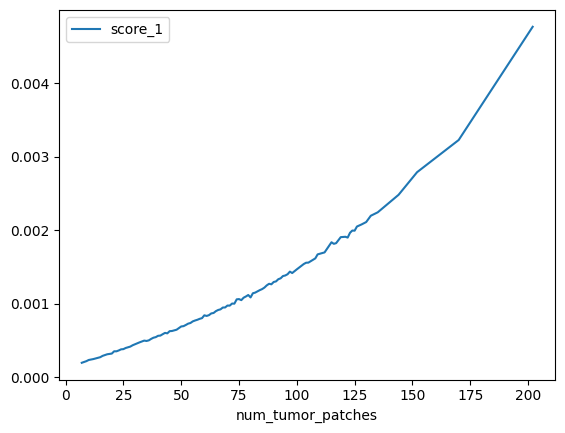

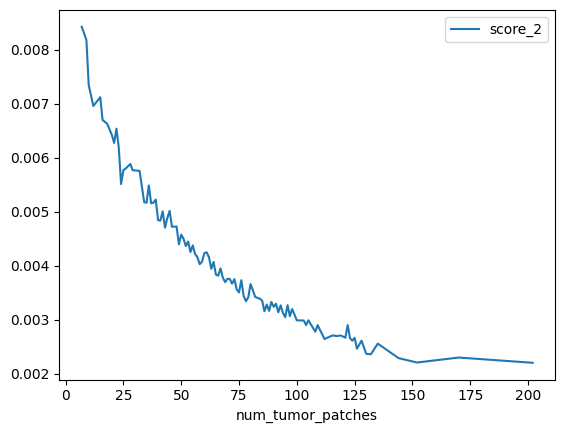

In [15]:
dyn_eps_all_agg_ = dyn_eps_df.groupby(['use_frac','start_eps','schedule'],  as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
print('min score config: ', dyn_eps_all_agg_[dyn_eps_all_agg_['mean_score'] == dyn_eps_all_agg_['mean_score'].min()])

dyn_eps_all_agg= dyn_eps_df.groupby(['use_frac','start_eps'],  as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
sns.heatmap(dyn_eps_all_agg.pivot(index='use_frac',columns='start_eps',values='mean_score'))

dyn_eps_agg = dyn_eps_all_agg.groupby(['start_eps'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_eps_agg[['start_eps', 'kl_wt_1', 'kl_uni_1']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'kl_wt_2', 'kl_uni_2']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'mean_score']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'score_1']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'score_2']].set_index('start_eps').plot()

dyn_schedule_agg = dyn_eps_df.groupby(['schedule'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_schedule_agg[['schedule', 'kl_wt_1', 'kl_uni_1']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'kl_wt_2', 'kl_uni_2']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'mean_score']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'score_1']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'score_2']].set_index('schedule').plot(kind='bar')

'''
dyn_use_agg = dyn_eps_all_agg.groupby(['use_frac'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_use_agg[['use_frac', 'kl_wt_1', 'kl_uni_1']].set_index('use_frac').plot()
dyn_use_agg[['use_frac', 'kl_wt_2', 'kl_uni_2']].set_index('use_frac').plot()
'''
dyn_num_tumor_agg = dyn_eps_df.groupby(['num_tumor_patches'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_num_tumor_agg[['num_tumor_patches', 'kl_wt_1', 'kl_uni_1']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'kl_wt_2', 'kl_uni_2']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'mean_score']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'score_1']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'score_2']].set_index('num_tumor_patches').plot()


In [ ]:
#Subset df on best config and plot num_tumor_patches vs scores
dyn_eps_df_sub = dyn_eps_df[(dyn_eps_df['use_frac'] == 0.7) & (dyn_eps_df['start_eps'] == 0.1)].reset_index(drop=True)
dyn_eps_df_sub_ =  dyn_eps_df_sub.groupby(['num_tumor_patches'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()

num_tumor_patches_counts=dyn_eps_df_sub['num_tumor_patches'].value_counts().to_frame()
dyn_eps_df_sub_ = dyn_eps_df_sub_.merge(num_tumor_patches_counts,on='num_tumor_patches')

dyn_eps_df_sub_[['num_tumor_patches', 'count']].set_index('num_tumor_patches').plot(title='Num of images with n tumor patches')
dyn_eps_df_sub_[['num_tumor_patches', 'kl_wt_1', 'kl_uni_1']].set_index('num_tumor_patches').plot(kind='bar')
dyn_eps_df_sub_[['num_tumor_patches', 'kl_wt_2', 'kl_uni_2']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'score_1']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'score_2']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'mean_score']].set_index('num_tumor_patches').plot()


Obs: Mean score is the least in for images with the most common number of patches (=15/16)

Score_1 and score_2 are very complementary in nature

kl_wt_1 is high for n_tumor_patches = 28-32 as the patch counts are compared with the *eps=1e-20* basline counts. in this case, all the 30-32 tumor patches will be sampled most of the time as we are sampling 32 items

In [33]:
dyn_eps_df.to_csv('dyn_eps_df.csv')
fixed_eps_df.to_csv('fixed_eps_df.csv')

In [ ]:
all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
torch.sort(all_patch_vols)

In [ ]:
import itertools

def ravel_index_(index, shape):
    """Ravel multi-dimensional indices to 1D index
    similar to np.ravel_multi_index
    Args:
        index (torch.tensor): indices in reversed order dn, ..., d1, with shape (..., n)
        shape (tuple): dn, ..., d1
    """
    index = torch.tensor(index, dtype=torch.int64)
    shape = torch.tensor((1,) + shape[::-1], dtype=torch.int64) # =(1, d1, d1*d2, ..., d1*...*dn)
    shape = torch.cumprod(shape, dim=0)[:-1].flip(0) # =(d1*...*dn-1, ..., d1*d2, d1, 1)
    index = (index * shape).sum(dim=-1) # (...,)
    return index


def get_16_idx_from_32_flat_idx(flat_idxs_32,x_16_shape,x_32_shape):
  assert len(x_16_shape) == len(x_32_shape)
  print('flat_idxs_32 ', flat_idxs_32)

  unravled_idxs_32 = torch.unravel_index(flat_idxs_32, x_32_shape)
  unravled_idxs_32_T = torch.stack(unravled_idxs_32, dim=0).T
  unravled_idxs_start_16 = unravled_idxs_32_T*torch.tensor([1,2,2,2])

  list(itertools.product([0, 1], repeat=3))
  offsets = list(itertools.product([0, 1], repeat=3))
  offsets = [[0]+list(offset) for offset in offsets]
  offsets = torch.tensor(offsets)
  print('offsets ', offsets)

  unraveled_idxs_all_16 = unravled_idxs_start_16.unsqueeze(1) + offsets
  unraveled_idxs_all_16 = unraveled_idxs_all_16.contiguous().view(-1,len(x_16_shape))

  flat_idxs_16 = ravel_index_(unraveled_idxs_all_16, x_16_shape)
  print('flat_idxs_16 ', flat_idxs_16)

  unraveled_idxs_all_16 = torch.unbind(unraveled_idxs_all_16, dim=1)
  return flat_idxs_16, unraveled_idxs_all_16


x_16 = torch.linspace(0, 1023, steps=1024).view(2,8,8,8)
x_32 = torch.linspace(0, 127, steps=128).view(2,4,4,4)
sampled_idxs_32 = torch.multinomial(torch.ones_like(x_32.flatten()),num_samples=32)

flat_idxs_16, unraveled_idxs_all_16 = get_16_idx_from_32_flat_idx(sampled_idxs_32,x_16.shape,x_32.shape)
test_raveled_idxs_16 = x_16[unraveled_idxs_all_16]
assert torch.all(flat_idxs_16 == test_raveled_idxs_16)


In [ ]:
patch_tumor_vol_fracs['16'][idx].shape

In [ ]:

idx = 34
N=300
k_32 = 32
k_16 = 256
eps= 0.001
all_patch_vols_16 = patch_tumor_vol_fracs['16'][idx].view(1,-1).squeeze(dim=0)
all_patch_vols_16_sorted_out=torch.sort(all_patch_vols_16)
all_patch_vols_16_sorted = all_patch_vols_16_sorted_out.values
sorted_indices_16 = all_patch_vols_16_sorted_out.indices
idx_mapping = torch.argsort(sorted_indices_16)
print('Tumor Patch indices' ,all_patch_vols_16_sorted.nonzero()[:,0])

cmp_counts_weighted = count_samples(all_patch_vols_16_sorted,eps=1e-20,k=k,N=N)
cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
cmp_counts_uniform = count_samples(all_patch_vols_16_sorted,eps=20,k=k,N=N)
cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()
uniform_wts = torch.ones_like(all_patch_vols_16_sorted)/len(all_patch_vols_16_sorted)
tumor_wts = all_patch_vols_16_sorted/all_patch_vols_16_sorted.sum()


fig, axs = plt.subplots(1,3,figsize=(18,6))

counts_16_base = count_samples(all_patch_vols_16_sorted,eps=eps,k=k_16,N=N)
counts_16_base_p = counts_16_base/counts_16_base.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_base_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_base_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_base_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_base_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_base = 0.5*(score_1+score_2)

axs[0].bar(range(len(counts_16_base)),counts_16_base)
axs[0].set_title(f"Baseline 16 size patch sampling\n eps={eps}, score={mean_score_base:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

use_frac=0.7
start_eps=0.1
schedule='linear'

counts_16_base_dyn, _ = count_samples_dyn_eps(all_patch_vols_16_sorted,start_eps=start_eps,\
                schedule=schedule,k=k_16,N=N,use_frac=use_frac)
counts_16_base_dyn_p = counts_16_base_dyn/counts_16_base_dyn.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_base_dyn = 0.5*(score_1+score_2)
axs[1].bar(range(len(counts_16_base_dyn)),counts_16_base_dyn)
axs[1].set_title(f"Baseline dynamic 16 size patch sampling\n start_eps={start_eps}, score={mean_score_base_dyn:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

#sample constitiuent 16 size patches from randonly chosen 32 size patches
all_patch_vols_32 = patch_tumor_vol_fracs['32'][idx].view(1,-1).squeeze(dim=0)
counts_16_from_32 = torch.zeros_like(all_patch_vols_16)
for i in range(N):
  N_use = N*use_frac
  if i <= N_use - 1:
      if schedule == 'linear':
          eps = start_eps*(1-(i/N_use))
      elif schedule == 'cosine':
          eps = start_eps*np.cos((np.pi*i)/(2*N_use))

  #directly sample 16 patches
  if 1==0:
    sampled_idxs_16_base_dyn = torch.multinomial(all_patch_vols_16_sorted+eps, num_samples=k_16)
    counts_16_from_32[sampled_idxs_16_base_dyn] +=1

  #16 from 32
  else:
    sampled_idxs_32 = torch.multinomial(all_patch_vols_32+eps, num_samples=k_32)
    sampled_idxs_16_from_32, _ = get_16_idx_from_32_flat_idx(sampled_idxs_32,patch_tumor_vol_fracs['16'][idx].shape,patch_tumor_vol_fracs['32'][idx].shape)
    counts_16_from_32[idx_mapping[sampled_idxs_16_from_32]] +=1

counts_16_from_32_p = counts_16_from_32/counts_16_from_32.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_16_from_32 = 0.5*(score_1+score_2)


axs[2].bar(range(len(counts_16_from_32)),counts_16_from_32)
axs[2].set_title(f"Sample 16 size patches by sampling 32 size patches\n start_eps={start_eps}, score={mean_score_16_from_32:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

fig.tight_layout()

In [ ]:
counts_16_base_dyn

In [ ]:
counts_16_from_32